<a href="https://colab.research.google.com/github/juhungaro/Pipoca/blob/main/Entrega2_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Etapa 1 – Pré-processamento dos Dados

*   Organizar os datasets de imagens e dados temporais coletados na Sprint 1.
*   Realizar tratamento dos dados, garantindo que estejam estruturados e prontos para serem usados no modelo.
*   Identificar padrões e sazonalidades na série temporal NDVI, explorando diferentes abordagens estatísticas para entender variações de produtividade.

# Produção agrícola 🌽
Fonte de dados CONAB, série histórica grãos https://portaldeinformacoes.conab.gov.br/downloads/arquivos/SerieHistoricaGraos.txt



In [2]:
# Pré-processamento Dados de Produção Agrícola (Milho CONAB

# Configuração Inicial e Upload

print("--- Configuração inicial e upload (milho CONAB) ---")

# Importar bibliotecas essenciais
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import shutil

# Tentar importar do Colab para upload/download
try:
    from google.colab import files
    IN_COLAB = True
    print("Executando no Google Colab.")
except ImportError:
    IN_COLAB = False
    print("Executando localmente.")
    class DummyFiles:
        def upload(self):
            print("AVISO: files.upload() chamado, mas não disponível localmente.")
            print("       Coloque o arquivo 'serie_historica_graos.csv' na pasta 'dados_originais'.")

            dummy_path = os.path.join('dados_originais', 'serie_historica_graos.csv')
            if not os.path.exists(dummy_path):
                 # Cria um arquivo vazio ou com cabeçalho mínimo
                 os.makedirs('dados_originais', exist_ok=True)
                 with open(dummy_path, 'w', encoding='utf-8') as f:
                      f.write("uf;produto;ano_agricola;dsc_safra_previsao;area_plantada_mil_ha;producao_mil_t;produtividade_mil_ha_mil_t\n")
                 print(f"       Arquivo dummy '{dummy_path}' criado para execução local.")
            return {os.path.basename(dummy_path): None}

        def download(self, path):
             print(f"AVISO: files.download({path}) chamado, mas não disponível localmente.")
             print(f"       O arquivo processado está salvo em: {path}")
    files = DummyFiles()

# Configurações gerais de plotagem
try:
    plt.style.use('seaborn-v0_8-whitegrid')
    print("Estilo de plotagem 'seaborn-v0_8-whitegrid' aplicado.")
except OSError:
    print("Estilo 'seaborn-v0_8-whitegrid' não encontrado, tentando 'seaborn-whitegrid'...")
    try:
        plt.style.use('seaborn-whitegrid')
        print("Estilo de plotagem 'seaborn-whitegrid' aplicado.")
    except OSError:
        print("Nenhum estilo seaborn encontrado. Usando estilo padrão do Matplotlib.")
sns.set(style="whitegrid")

# Definir pastas
pasta_dados_originais = 'dados_originais'
pasta_dados_processados = 'dados_processados'
os.makedirs(pasta_dados_originais, exist_ok=True)
os.makedirs(pasta_dados_processados, exist_ok=True)
print(f"Diretórios '{pasta_dados_originais}' e '{pasta_dados_processados}' verificados/criados.")


nome_arquivo_conab = "serie_historica_graos.csv"
caminho_arquivo_conab_orig = os.path.join(pasta_dados_originais, nome_arquivo_conab)


# Limpeza de arquivo anterior (caso haja)
print(f"\n--- Limpando arquivo '{nome_arquivo_conab}' antigo de '{pasta_dados_originais}' (se existir) ---")
if os.path.exists(caminho_arquivo_conab_orig):
    try:
        os.remove(caminho_arquivo_conab_orig)
        print(f"  Removido: {nome_arquivo_conab}")
        print("--- Limpeza concluída ---")
    except OSError as e:
        print(f"  Erro ao remover {nome_arquivo_conab}: {e}")
else:
    print(f"--- Arquivo '{nome_arquivo_conab}' não encontrado para limpar ---")


# Upload do arquivo CONAB (se estiver no Colab)
if IN_COLAB:
    print("\n--- Upload Arquivo CONAB ---")
    print(f"Faça o upload do arquivo: {nome_arquivo_conab}")
    uploaded_conab = files.upload()
    print(f"\nMovendo arquivo carregado para '{pasta_dados_originais}'...")

    if uploaded_conab:
        uploaded_filename = list(uploaded_conab.keys())[0]
        print(f"  Arquivo carregado detectado: '{uploaded_filename}'")
        try:
            source_path = uploaded_filename

            destination_path = os.path.join(pasta_dados_originais, nome_arquivo_conab)
            shutil.move(source_path, destination_path)
            print(f"  Movido e Renomeado: '{uploaded_filename}' -> '{destination_path}'")
        except Exception as e:
            print(f"Erro ao mover/renomear {uploaded_filename}: {e}.")
    else:
        print("  Nenhum arquivo foi carregado.")


# Verifica se o arquivo existe no local esperado
if os.path.exists(caminho_arquivo_conab_orig):
    print(f"\n[OK] Arquivo '{nome_arquivo_conab}' encontrado em '{pasta_dados_originais}'.")
else:
    print(f"\n[ERRO] Arquivo '{nome_arquivo_conab}' NÃO encontrado em '{pasta_dados_originais}'.")
    print("       Certifique-se de que o upload foi feito ou o arquivo está no local correto.")

print("\n--- Fim do Bloco 1: Configuração e Upload (Milho CONAB) ---")

--- Configuração inicial e upload (milho CONAB) ---
Executando no Google Colab.
Estilo de plotagem 'seaborn-v0_8-whitegrid' aplicado.
Diretórios 'dados_originais' e 'dados_processados' verificados/criados.

--- Limpando arquivo 'serie_historica_graos.csv' antigo de 'dados_originais' (se existir) ---
--- Arquivo 'serie_historica_graos.csv' não encontrado para limpar ---

--- Upload Arquivo CONAB ---
Faça o upload do arquivo: serie_historica_graos.csv


Saving serie_historica_graos.csv to serie_historica_graos.csv

Movendo arquivo carregado para 'dados_originais'...
  Arquivo carregado detectado: 'serie_historica_graos.csv'
  Movido e Renomeado: 'serie_historica_graos.csv' -> 'dados_originais/serie_historica_graos.csv'

[OK] Arquivo 'serie_historica_graos.csv' encontrado em 'dados_originais'.

--- Fim do Bloco 1: Configuração e Upload (Milho CONAB) ---


In [3]:
# Carregamento e Verificação Inicial

print("\n--- Carregamento e Verificação Inicial (Milho CONAB) ---")

df_conab_raw = None

# Verifica se o caminho do arquivo foi definido no bloco anterior
# E se o arquivo realmente existe com o nome padrão esperado
if 'caminho_arquivo_conab_orig' in locals() and os.path.exists(caminho_arquivo_conab_orig):
    try:

        try:
            df_conab_raw = pd.read_csv(caminho_arquivo_conab_orig, sep=";", encoding='latin1')
        except UnicodeDecodeError:
            print("  Falha com latin1, tentando utf-8...")
            df_conab_raw = pd.read_csv(caminho_arquivo_conab_orig, sep=";", encoding='utf-8')
        print(f"[OK] Arquivo CONAB carregado: {caminho_arquivo_conab_orig}")
        print(f"     Dimensões: {df_conab_raw.shape}")
        print("     Primeiras 5 linhas:")

        from IPython.display import display
        display(df_conab_raw.head())
        print("\n     Informações do DataFrame:")
        df_conab_raw.info()

    except FileNotFoundError:
        print(f"[ERRO] Arquivo CONAB não encontrado em: {caminho_arquivo_conab_orig}")
    except Exception as e:
        print(f"[ERRO] Falha ao carregar o arquivo CONAB: {e}")
else:
    print("[ERRO] Caminho do arquivo CONAB não definido ou arquivo não existe. Execute o a etapa anterior.")

print("\n--- Fim do carregamento e verificação inicial ---")


--- Carregamento e Verificação Inicial (Milho CONAB) ---
[OK] Arquivo CONAB carregado: dados_originais/serie_historica_graos.csv
     Dimensões: (12453, 8)
     Primeiras 5 linhas:


,ano_agricola,dsc_safra_previsao,uf,produto,id_produto,area_plantada_mil_ha,producao_mil_t,produtividade_mil_ha_mil_t
0,1976/77,UNICA,AL,ALGODAO EM PLUMA,4586,99.3,6.0,0.1
1,1976/77,UNICA,BA,ALGODAO EM PLUMA,4586,123.4,7.0,0.1
2,1976/77,UNICA,CE,ALGODAO EM PLUMA,4586,1296.0,70.0,0.1
3,1976/77,UNICA,GO,ALGODAO EM PLUMA,4586,73.1,28.2,0.4
4,1976/77,UNICA,MA,ALGODAO EM PLUMA,4586,44.4,2.0,0.0



     Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12453 entries, 0 to 12452
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ano_agricola                12453 non-null  object 
 1   dsc_safra_previsao          12453 non-null  object 
 2   uf                          12453 non-null  object 
 3   produto                     12453 non-null  object 
 4   id_produto                  12453 non-null  int64  
 5   area_plantada_mil_ha        12453 non-null  float64
 6   producao_mil_t              12453 non-null  float64
 7   produtividade_mil_ha_mil_t  12453 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 778.4+ KB

--- Fim do carregamento e verificação inicial ---


In [4]:
# Tratamento e Filtragem

print("\n--- Tratamento e Filtragem (Milho CONAB) ---")

df_milho_proc = None

# Só executa se na etapa anterior foi criado o df_conab_raw com sucesso
if 'df_conab_raw' in locals() and isinstance(df_conab_raw, pd.DataFrame):
    df_working = df_conab_raw.copy() # cópia
    ano_inicio_filtro = 2002 # Define o ano inicial desejado (igual ao clima)

    print(f"  Iniciando tratamento. Linhas iniciais: {len(df_working)}")

    # Filtro por UF = 'MT'
    if 'uf' in df_working.columns:
        df_working = df_working[df_working['uf'].str.upper() == 'MT'].copy()
        print(f"    - Após filtro UF='MT': {len(df_working)} linhas")
    else: print("    - [AVISO] Coluna 'uf' não encontrada para filtro.")

    # Filtro por produto = 'MILHO'
    if 'produto' in df_working.columns:
        df_working = df_working[df_working['produto'].str.strip().str.upper() == 'MILHO'].copy()
        print(f"    - Após filtro produto='MILHO': {len(df_working)} linhas")
    else: print("    - [AVISO] Coluna 'produto' não encontrada para filtro.")

    # Separar ano agrícola
    if 'ano_agricola' in df_working.columns:
        def separa_anos(ano_agricola):
            if isinstance(ano_agricola, str) and '/' in ano_agricola:
                a1, a2 = ano_agricola.split('/')
                try: a1_int = int(a1.strip())
                except: a1_int = None
                try: a2_int = int(a2.strip())
                except: a2_int = None
                return a1_int, a2_int
            elif isinstance(ano_agricola, str):
                try: return int(ano_agricola.strip()), None
                except: return None, None
            return None, None

        anos_split = df_working['ano_agricola'].apply(separa_anos)
        df_working['primeiro_ano'] = anos_split.str[0].astype('Int64')
        df_working['segundo_ano'] = anos_split.str[1].astype('Int64')
        print("    - Colunas 'primeiro_ano' e 'segundo_ano' criadas/atualizadas.")
    else: print("    - [AVISO] Coluna 'ano_agricola' não encontrada.")

    # Renomear colunas principais
    rename_map_milho = {
        'dsc_safra_previsao': 'safra',
        'area_plantada_mil_ha': 'area_plantada_mil_ha',
        'producao_mil_t': 'producao_mil_t',
        'produtividade_mil_ha_mil_t': 'produtividade_t_ha' # t/ha
    }
    cols_a_renomear_milho = {k: v for k, v in rename_map_milho.items() if k in df_working.columns}
    df_working.rename(columns=cols_a_renomear_milho, inplace=True)
    print(f"    - Colunas renomeadas: {list(cols_a_renomear_milho.values())}")

    # Padronizar coluna 'safra'
    if 'safra' in df_working.columns:
        def padroniza_safra(s):
            if not isinstance(s, str): return s
            s = s.upper().strip()
            s = re.sub(r'1[ÂAªAa]*\s*SAFRA', '1ª SAFRA', s)
            s = re.sub(r'2[ÂAªAa]*\s*SAFRA', '2ª SAFRA', s)
            s = re.sub(r'3[ÂAªAa]*\s*SAFRA', '3ª SAFRA', s)
            s = re.sub(r'UNICA', 'ÚNICA', s)
            return s.title()
        df_working['safra'] = df_working['safra'].apply(padroniza_safra)
        print("    - Coluna 'safra' padronizada.")
    else: print("    - [AVISO] Coluna 'safra' não encontrada para padronização.")

    # Filtrar por ano >= ano_inicio_filtro (usando 'primeiro_ano')
    if 'primeiro_ano' in df_working.columns:
        linhas_antes_filtro_ano = len(df_working)
        # Garante que 'primeiro_ano' é numérico antes de filtrar
        df_working['primeiro_ano'] = pd.to_numeric(df_working['primeiro_ano'], errors='coerce')
        df_working = df_working[df_working['primeiro_ano'] >= ano_inicio_filtro].copy()
        removidos_filtro_ano = linhas_antes_filtro_ano - len(df_working)
        if removidos_filtro_ano > 0:
             print(f"    - Removidas {removidos_filtro_ano} linhas com ano < {ano_inicio_filtro}.")
        print(f"    - Após filtro ano >= {ano_inicio_filtro}: {len(df_working)} linhas")
    else: print(f"    - [AVISO] Coluna 'primeiro_ano' não disponível para filtro de ano.")

    # Converter colunas numéricas finais e tratar NaNs
    colunas_numericas_milho = ['area_plantada_mil_ha', 'producao_mil_t', 'produtividade_t_ha']
    print("    - Convertendo colunas numéricas finais e tratando NaNs:")
    for col in colunas_numericas_milho:
         if col in df_working.columns:
              df_working[col] = pd.to_numeric(df_working[col], errors='coerce')
              print(f"      Coluna '{col}' convertida para numérico.")
         else:
              print(f"      Atenção: Coluna '{col}' não encontrada.")

    # Remover linhas com NaNs nas colunas essenciais
    colunas_essenciais_milho = ['primeiro_ano', 'safra'] + colunas_numericas_milho
    colunas_presentes_milho = [col for col in colunas_essenciais_milho if col in df_working.columns]
    linhas_antes_nan = len(df_working)
    df_working.dropna(subset=colunas_presentes_milho, inplace=True)
    removidos_nan = linhas_antes_nan - len(df_working)
    if removidos_nan > 0: print(f"    - {removidos_nan} linhas removidas devido a NaNs em colunas essenciais.")

    # Renomear colunas de ano e produtividade para padrão final
    df_working = df_working.rename(columns={'primeiro_ano': 'ANO', 'produtividade_t_ha': 'Produtividade_Anual'})
    print("    - Colunas 'primeiro_ano' -> 'ANO' e 'produtividade_t_ha' -> 'Produtividade_Anual' renomeadas.")

    # Selecionar e reordenar colunas finais
    colunas_finais_milho = ['ANO', 'safra', 'area_plantada_mil_ha', 'producao_mil_t', 'Produtividade_Anual']
    colunas_presentes_milho_final = [col for col in colunas_finais_milho if col in df_working.columns]
    df_milho_proc = df_working[colunas_presentes_milho_final].reset_index(drop=True)


    print("\n    Verificando se há múltiplas safras por ano...")
    contagem_anos = df_milho_proc['ANO'].value_counts()
    anos_multiplos = contagem_anos[contagem_anos > 1].index.tolist()
    if anos_multiplos:
        print(f"    [AVISO] Anos com múltiplas safras encontradas: {sorted(anos_multiplos)}")
        print("            A base 'milho.csv' conterá múltiplas linhas para esses anos.")
        print("            A Etapa 2 precisará ser ajustada para lidar com isso (ex: agrupar por ANO e SAFRA ou calcular média anual).")
    else:
        print("    [INFO] Apenas uma entrada por ano encontrada (ou múltiplas safras já foram agregadas).")


    print(f"\n[OK] Processamento concluído. Base final: {df_milho_proc.shape[0]} linhas x {df_milho_proc.shape[1]} colunas.")
    print("     Primeiras 5 linhas:")
    print(df_milho_proc.head())
    print("\n     Tipos de dados finais:")
    print(df_milho_proc.dtypes)
    print("\n     Verificação final de nulos:")
    print(df_milho_proc.isnull().sum())

else:
    print("[ERRO] DataFrame bruto 'df_conab_raw' não foi criado na etapa anterior.")

print("\n--- Fim do tratamento e filtragem ---")


--- Tratamento e Filtragem (Milho CONAB) ---
  Iniciando tratamento. Linhas iniciais: 12453
    - Após filtro UF='MT': 597 linhas
    - Após filtro produto='MILHO': 89 linhas
    - Colunas 'primeiro_ano' e 'segundo_ano' criadas/atualizadas.
    - Colunas renomeadas: ['safra', 'area_plantada_mil_ha', 'producao_mil_t', 'produtividade_t_ha']
    - Coluna 'safra' padronizada.
    - Removidas 37 linhas com ano < 2002.
    - Após filtro ano >= 2002: 52 linhas
    - Convertendo colunas numéricas finais e tratando NaNs:
      Coluna 'area_plantada_mil_ha' convertida para numérico.
      Coluna 'producao_mil_t' convertida para numérico.
      Coluna 'produtividade_t_ha' convertida para numérico.
    - Colunas 'primeiro_ano' -> 'ANO' e 'produtividade_t_ha' -> 'Produtividade_Anual' renomeadas.

    Verificando se há múltiplas safras por ano...
    [AVISO] Anos com múltiplas safras encontradas: [2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 


--- Análise Exploratória (Milho CONAB) ---

  Histogramas - Distribuição das variáveis:


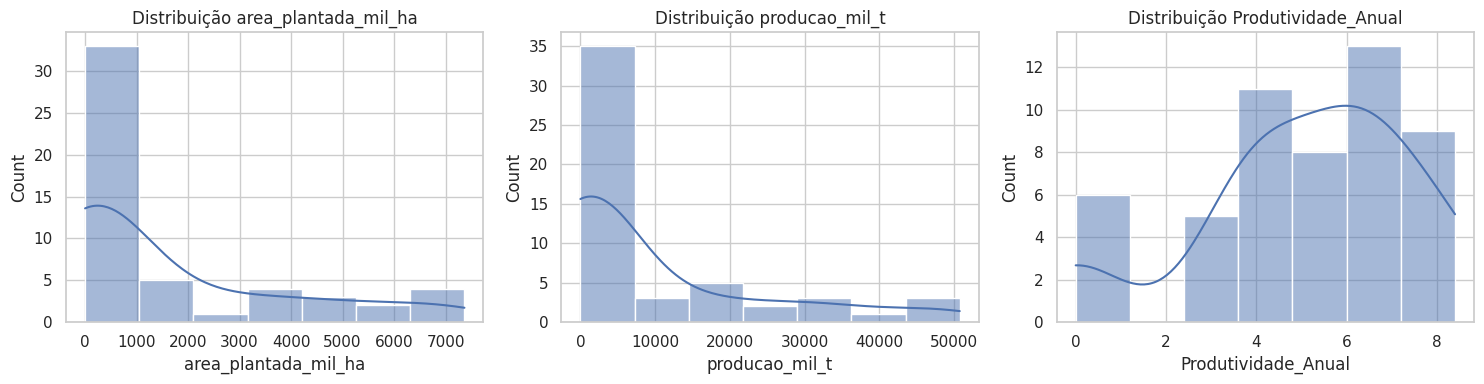


  Evolução temporal das métricas (por safra):


<Figure size 1400x600 with 0 Axes>

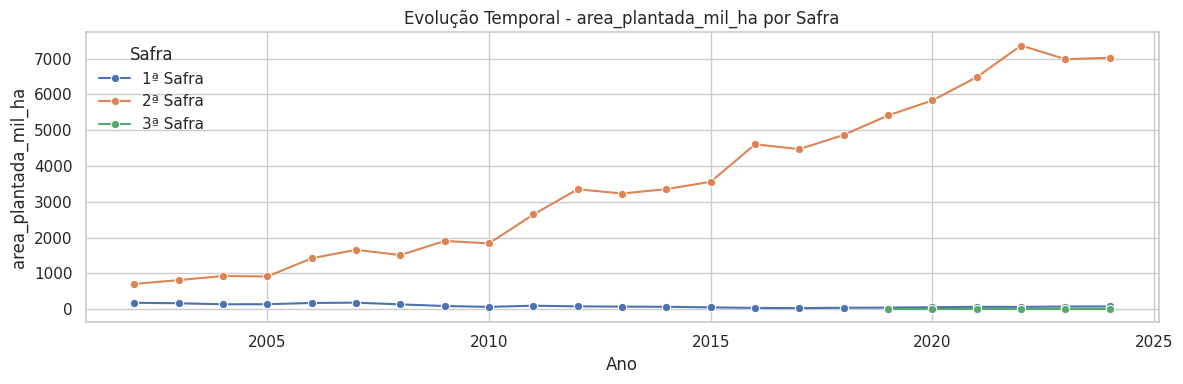

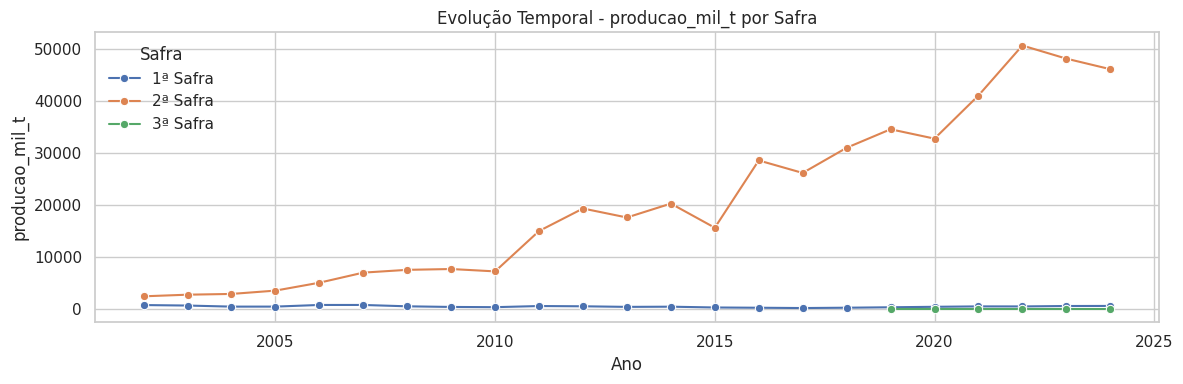

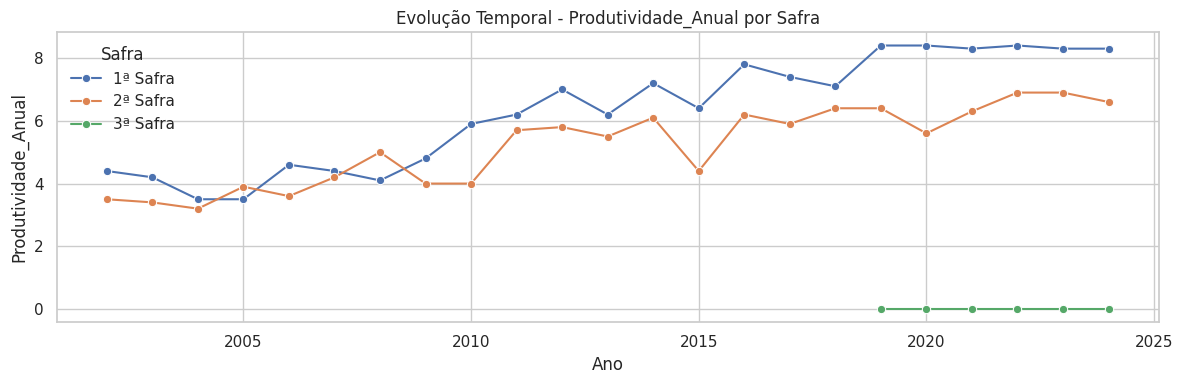


  Boxplot + Stripplot - Produtividade Anual por Ano e Safra:


<ipython-input-5-895fdbcce2f0>:66: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(x='ANO', y='Produtividade_Anual', hue='safra', data=df_milho_proc_plot,


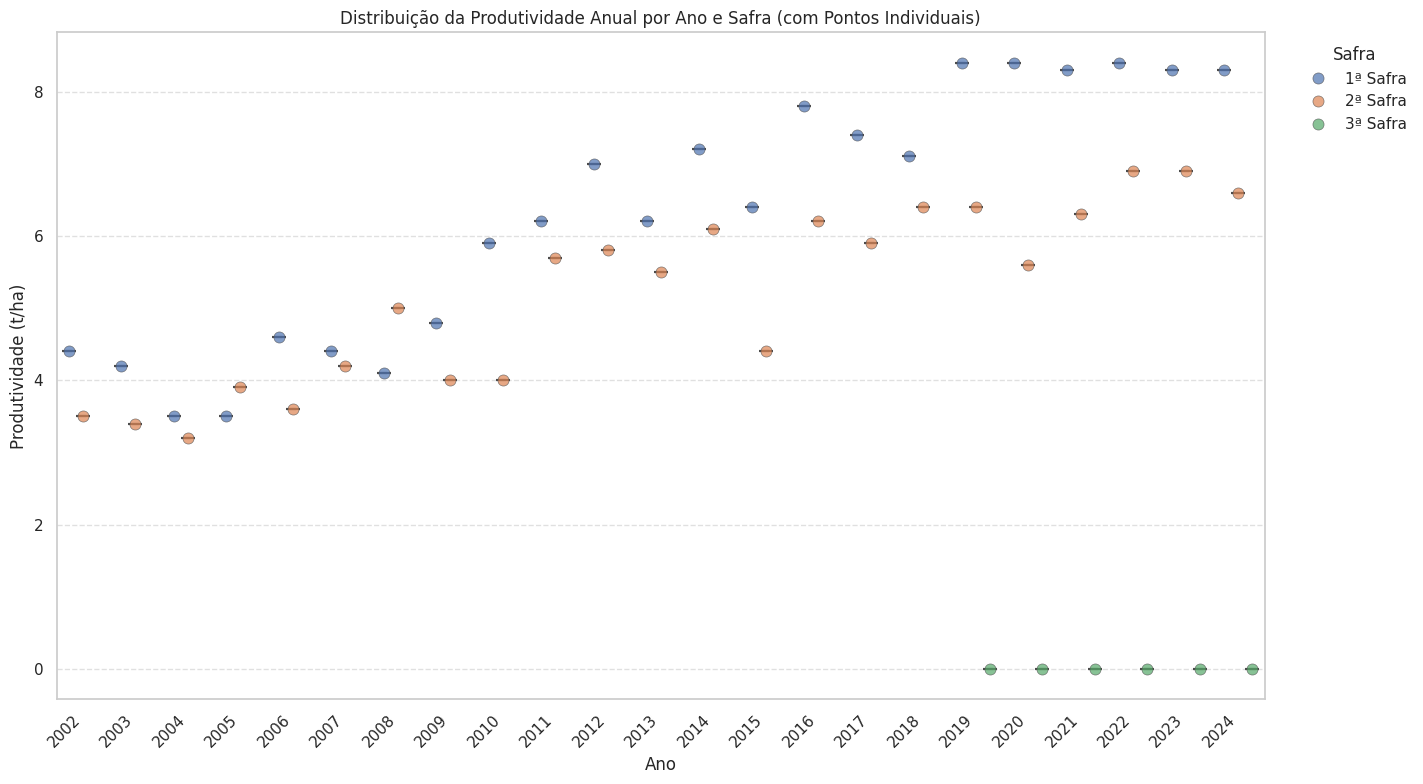


--- Fim do análise exploratória ---


In [5]:
# Análise Exploratória

print("\n--- Análise Exploratória (Milho CONAB) ---")

# Só executa se a etapa anterior foi criado o df_milho_proc com sucesso
if 'df_milho_proc' in locals() and isinstance(df_milho_proc, pd.DataFrame) and not df_milho_proc.empty:

    colunas_numericas_plot = ['area_plantada_mil_ha', 'producao_mil_t', 'Produtividade_Anual']
    colunas_numericas_plot = [col for col in colunas_numericas_plot if col in df_milho_proc.columns] # Garante que existe

    if colunas_numericas_plot:
        # Distribuições (histogramas)
        print("\n  Histogramas - Distribuição das variáveis:")
        n_cols_plot = len(colunas_numericas_plot)
        plt.figure(figsize=(5 * n_cols_plot, 4))
        for i, coluna in enumerate(colunas_numericas_plot):
            plt.subplot(1, n_cols_plot, i + 1)
            sns.histplot(df_milho_proc[coluna], kde=True)
            plt.title(f'Distribuição {coluna}')
        plt.tight_layout()
        plt.show()

        # Séries temporais (Agrupando por ANO e SAFRA para ver evolução)
        print("\n  Evolução temporal das métricas (por safra):")
        if 'ANO' in df_milho_proc.columns and 'safra' in df_milho_proc.columns:
            # Pivotear para ter safras como colunas ou usar hue no lineplot
            plt.figure(figsize=(14, 6))
            # Usar 'hue' para separar linhas por safra
            for coluna in colunas_numericas_plot:
                 # Cria um subplot para cada métrica para clareza
                 plt.figure(figsize=(12, 4))
                 sns.lineplot(data=df_milho_proc, x='ANO', y=coluna, hue='safra', marker='o', errorbar=None) # errorbar=None se não quiser desvio
                 plt.title(f'Evolução Temporal - {coluna} por Safra')
                 plt.xlabel('Ano')
                 plt.ylabel(coluna)
                 plt.legend(title='Safra')
                 plt.grid(True)
                 plt.tight_layout()
                 plt.show()
        else:
            print("    - [AVISO] Colunas 'ANO' ou 'safra' não encontradas para plotar série temporal por safra.")


        # Boxplots por Ano (Produtividade, separado por safra)
        print("\n  Boxplot + Stripplot - Produtividade Anual por Ano e Safra:")
        if 'ANO' in df_milho_proc.columns and 'Produtividade_Anual' in df_milho_proc.columns and 'safra' in df_milho_proc.columns:
             df_milho_proc['ANO'] = pd.to_numeric(df_milho_proc['ANO'], errors='coerce')
             df_milho_proc_plot = df_milho_proc.dropna(subset=['ANO', 'Produtividade_Anual', 'safra'])
             if not df_milho_proc_plot.empty:

                  plt.figure(figsize=(16, 8))
                  ordem_safra = sorted(df_milho_proc_plot['safra'].unique())

                  sns.boxplot(x='ANO', y='Produtividade_Anual', hue='safra', data=df_milho_proc_plot,
                              hue_order=ordem_safra,
                              dodge=True,
                              linewidth=1.5,
                              showfliers=False,
                              legend=False
                             )

                  marcadores_disponiveis = ["o", "s", "^", "D", "P", "*"]
                  safras_unicas = df_milho_proc_plot['safra'].unique()
                  marcadores_safra = {safra: marcadores_disponiveis[i % len(marcadores_disponiveis)] for i, safra in enumerate(ordem_safra)}

                  sns.stripplot(x='ANO', y='Produtividade_Anual', hue='safra', data=df_milho_proc_plot,
                                hue_order=ordem_safra,
                                size=8,
                                edgecolor='gray',
                                linewidth=0.5,
                                jitter=True,
                                dodge=True,
                                alpha=0.7,
                                legend=True,
                               )

                  plt.title('Distribuição da Produtividade Anual por Ano e Safra (com Pontos Individuais)')
                  plt.xlabel('Ano')
                  plt.ylabel('Produtividade (t/ha)')
                  plt.xticks(rotation=45, ha='right')
                  plt.grid(True, axis='y', linestyle='--', alpha=0.6)

                  handles, labels = plt.gca().get_legend_handles_labels()
                  plt.legend(handles=handles, labels=labels, title='Safra', bbox_to_anchor=(1.02, 1), loc='upper left')
                  plt.tight_layout(rect=[0, 0, 0.9, 1])
                  plt.show()

             else: print("    - [AVISO] Não há dados válidos para gerar boxplot anual por safra.")
        else: print("    - [AVISO] Colunas 'ANO', 'Produtividade_Anual' ou 'safra' não encontradas para boxplot.")

    else:
        print("  Nenhuma coluna numérica encontrada para plotar.")
else:
    print("  DataFrame processado 'df_milho_proc' não disponível ou vazio. Análise exploratória pulada.")

print("\n--- Fim do análise exploratória ---")

In [6]:
# Salvar Resultado Processado

print("\n--- Salvar Resultado Processado (Milho CONAB) ---")

# Só salva se o df_milho_proc foi criado com sucesso
if 'df_milho_proc' in locals() and isinstance(df_milho_proc, pd.DataFrame) and not df_milho_proc.empty:
    # Definir o caminho de saída
    caminho_saida_milho = os.path.join(pasta_dados_processados, 'milho.csv')
    try:
        # Salvar o DataFrame final
        df_milho_proc.to_csv(caminho_saida_milho, index=False, encoding='utf-8')
        print(f"[OK] Dados de milho processados salvos em: {caminho_saida_milho}")
        print("\n  Informações do DataFrame Salvo:")
        df_milho_proc.info()
        print("\n  Primeiras linhas do DataFrame Salvo:")
        print(df_milho_proc.head())
    except Exception as e:
        print(f"[ERRO] Falha ao salvar o arquivo processado: {e}")
else:
    print("[ERRO] DataFrame processado 'df_milho_proc' não disponível ou vazio. Nenhum arquivo salvo.")

print("\n--- Fim da etapar de salvar os resultado ---")


--- Salvar Resultado Processado (Milho CONAB) ---
[OK] Dados de milho processados salvos em: dados_processados/milho.csv

  Informações do DataFrame Salvo:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ANO                   52 non-null     Int64  
 1   safra                 52 non-null     object 
 2   area_plantada_mil_ha  52 non-null     float64
 3   producao_mil_t        52 non-null     float64
 4   Produtividade_Anual   52 non-null     float64
dtypes: Int64(1), float64(3), object(1)
memory usage: 2.2+ KB

  Primeiras linhas do DataFrame Salvo:
    ANO     safra  area_plantada_mil_ha  producao_mil_t  Produtividade_Anual
0  2002  1ª Safra                 176.0           772.0                  4.4
1  2002  2ª Safra                 704.0          2456.0                  3.5
2  2003  1ª Safra                 162.0           6

# Dados SatVeg  🛰️

Dados obtidos do sensor SatVeg para a Fazenda São José, Sorriso-MT
Coordenadas: -55.95520,-12.88229 | -55.95729,-12.88229

In [7]:
# Pré-processamento Dados SatVeg

# Configuração inicial e upload


print("--- Configuração Inicial e upload (SatVeg) ---")

# Importar as bibliotecas
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import shutil
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm

# Tentar importar do Colab para upload/download
try:
    from google.colab import files
    IN_COLAB = True
    print("Executando no Google Colab.")
except ImportError:
    IN_COLAB = False
    print("Executando localmente.")
    class DummyFiles:
        def upload(self):
            print("AVISO: files.upload() chamado, mas não disponível localmente.")
            print("       Coloque o arquivo CSV do SatVeg na pasta 'dados_originais'.")
            # Simula um upload bem-sucedido para testes locais
            dummy_path = os.path.join('dados_originais', 'satveg_original.csv')
            if not os.path.exists(dummy_path):
                 os.makedirs('dados_originais', exist_ok=True)
                 with open(dummy_path, 'w', encoding='utf-8') as f:

                      f.write("Data;NDVI;PreFiltro;FlatBottom\n")
                      f.write("01/01/2020;0,5;0,6;0,7\n")
                 print(f"       Arquivo dummy '{dummy_path}' criado para execução local.")
            return {os.path.basename(dummy_path): None}

        def download(self, path):
             print(f"AVISO: files.download({path}) chamado, mas não disponível localmente.")
             print(f"       O arquivo processado está salvo em: {path}")
    files = DummyFiles()

# Configurações gerais de plotagem
try:
    plt.style.use('seaborn-v0_8-whitegrid')
    print("Estilo de plotagem 'seaborn-v0_8-whitegrid' aplicado.")
except OSError:
    print("Estilo 'seaborn-v0_8-whitegrid' não encontrado, tentando 'seaborn-whitegrid'...")
    try:
        plt.style.use('seaborn-whitegrid')
        print("Estilo de plotagem 'seaborn-whitegrid' aplicado.")
    except OSError:
        print("Nenhum estilo seaborn encontrado. Usando estilo padrão do Matplotlib.")
sns.set(style="whitegrid")

# Definir as pastas
pasta_dados_originais = 'dados_originais'
pasta_dados_processados = 'dados_processados'
os.makedirs(pasta_dados_originais, exist_ok=True)
os.makedirs(pasta_dados_processados, exist_ok=True)
print(f"Diretórios '{pasta_dados_originais}' e '{pasta_dados_processados}' verificados/criados.")

# Nome esperado do arquivo SatVeg
nome_arquivo_satveg = "satveg_original.csv"
caminho_arquivo_satveg_orig = os.path.join(pasta_dados_originais, nome_arquivo_satveg)

# Limpeza de arquivo anterior
print(f"\n--- Limpando arquivo '{nome_arquivo_satveg}' antigo de '{pasta_dados_originais}' (se existir) ---")
if os.path.exists(caminho_arquivo_satveg_orig):
    try:
        os.remove(caminho_arquivo_satveg_orig)
        print(f"  Removido: {nome_arquivo_satveg}")
        print("--- Limpeza concluída ---")
    except OSError as e:
        print(f"  Erro ao remover {nome_arquivo_satveg}: {e}")
else:
    print(f"--- Arquivo '{nome_arquivo_satveg}' não encontrado para limpar ---")

# Upload do arquivo SatVeg (se estiver no Colab)
if IN_COLAB:
    print("\n--- Upload Arquivo SatVeg ---")
    print(f"Faça o upload do seu arquivo CSV do SatVeg (separador ';', encoding latin1)")
    uploaded_satveg = files.upload()
    print(f"\nMovendo arquivo carregado para '{pasta_dados_originais}'...")
    if uploaded_satveg:
        uploaded_filename = list(uploaded_satveg.keys())[0]
        print(f"  Arquivo carregado detectado: '{uploaded_filename}'")
        try:
            source_path = uploaded_filename

            destination_path = os.path.join(pasta_dados_originais, nome_arquivo_satveg)
            shutil.move(source_path, destination_path)
            print(f"  Movido e Renomeado: '{uploaded_filename}' -> '{destination_path}'")
        except Exception as e:
            print(f"Erro ao mover/renomear {uploaded_filename}: {e}.")
    else:
        print("  Nenhum arquivo foi carregado.")


# Verifica se o arquivo existe no local esperado
if os.path.exists(caminho_arquivo_satveg_orig):
    print(f"\n[OK] Arquivo '{nome_arquivo_satveg}' encontrado em '{pasta_dados_originais}'.")
else:
    print(f"\n[ERRO] Arquivo '{nome_arquivo_satveg}' NÃO encontrado em '{pasta_dados_originais}'.")
    print("       Certifique-se de que o upload foi feito ou o arquivo está no local correto.")

print("\n--- Fim do Bloco 1: Configuração e Upload (SatVeg) ---")

--- Configuração Inicial e Upload (SatVeg) ---
Executando no Google Colab.
Estilo de plotagem 'seaborn-v0_8-whitegrid' aplicado.
Diretórios 'dados_originais' e 'dados_processados' verificados/criados.

--- Limpando arquivo 'satveg_original.csv' antigo de 'dados_originais' (se existir) ---
--- Arquivo 'satveg_original.csv' não encontrado para limpar ---

--- Upload Arquivo SatVeg ---
Faça o upload do seu arquivo CSV do SatVeg (separador ';', encoding latin1)


Saving dados_satveg.csv to dados_satveg.csv

Movendo arquivo carregado para 'dados_originais'...
  Arquivo carregado detectado: 'dados_satveg.csv'
  Movido e Renomeado: 'dados_satveg.csv' -> 'dados_originais/satveg_original.csv'

[OK] Arquivo 'satveg_original.csv' encontrado em 'dados_originais'.

--- Fim do Bloco 1: Configuração e Upload (SatVeg) ---


In [10]:
# Carregamento e Verificação Inicial (SatVeg) ---

print("\n---Carregamento e Verificação Inicial (SatVeg) ---")

df_satveg_raw = None # Inicializa

# Verifica se o caminho do arquivo foi definido e existe
if 'caminho_arquivo_satveg_orig' in locals() and os.path.exists(caminho_arquivo_satveg_orig):
    try:

        try:
            df_satveg_raw = pd.read_csv(caminho_arquivo_satveg_orig, sep=";", encoding='latin1')
        except UnicodeDecodeError:
            print("  Falha com latin1, tentando utf-8...")
            df_satveg_raw = pd.read_csv(caminho_arquivo_satveg_orig, sep=";", encoding='utf-8')
        print(f"[OK] Arquivo SatVeg carregado: {caminho_arquivo_satveg_orig}")
        print(f"     Dimensões: {df_satveg_raw.shape}")
        print("     Primeiras 5 linhas:")
        from IPython.display import display
        display(df_satveg_raw.head())
        print("\n     Informações do DataFrame:")
        df_satveg_raw.info()

    except FileNotFoundError:
        print(f"[ERRO] Arquivo SatVeg não encontrado em: {caminho_arquivo_satveg_orig}")
    except Exception as e:
        print(f"[ERRO] Falha ao carregar o arquivo SatVeg: {e}")
else:
    print("[ERRO] Caminho do arquivo SatVeg não definido ou arquivo não existe. Execute o Bloco 1.")

print("\n--- Fim do carregamento e verificação inicial ---")


---Carregamento e Verificação Inicial (SatVeg) ---
[OK] Arquivo SatVeg carregado: dados_originais/satveg_original.csv
     Dimensões: (576, 4)
     Primeiras 5 linhas:


,Data,NDVI,PreFiltro,FlatBottom
0,18/02/2000,"0,6119","0,6542","0,6542"
1,05/03/2000,"0,6542","0,6542","0,6542"
2,21/03/2000,"0,5751","0,5751","0,6542"
3,06/04/2000,"0,6839","0,6839","0,6839"
4,22/04/2000,"0,4797","0,4797","0,4808"



     Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Data        576 non-null    object
 1   NDVI        576 non-null    object
 2   PreFiltro   576 non-null    object
 3   FlatBottom  576 non-null    object
dtypes: object(4)
memory usage: 18.1+ KB

--- Fim do carregamento e verificação inicial ---


In [12]:
#  Pré-processamento (SatVeg) ---

print("\n---  Pré-processamento (SatVeg) ---")

df_satveg_proc = None

# Só executa se a etapa anteriior criou df_satveg_raw com sucesso
if 'df_satveg_raw' in locals() and isinstance(df_satveg_raw, pd.DataFrame):
    df_working = df_satveg_raw.copy() # Trabalha em uma cópia
    print(f"  Iniciando pré-processamento. Linhas iniciais: {len(df_working)}")

    # Converter 'Data' para datetime
    if 'Data' in df_working.columns:
        df_working['Data'] = pd.to_datetime(df_working['Data'], format='%d/%m/%Y', errors='coerce')
        linhas_antes = len(df_working)
        df_working.dropna(subset=['Data'], inplace=True)
        removidos = linhas_antes - len(df_working)
        if removidos > 0: print(f"    - {removidos} linhas removidas por data inválida.")
        print("    - Coluna 'Data' convertida para datetime.")
    else:
        print("[ERRO] Coluna 'Data' não encontrada. Processamento interrompido.")
        df_working = None # Invalida o dataframe

    # Prossegue apenas se a data foi convertida
    if df_working is not None and not df_working.empty:
        # Criar colunas ANO e MES (padronizado)
        df_working['ANO'] = df_working['Data'].dt.year.astype('Int64')
        df_working['MES'] = df_working['Data'].dt.month.astype('Int64')
        df_working['AnoMes'] = df_working['Data'].dt.strftime('%Y-%m') # Formato YYYY-MM string
        print("    - Colunas 'ANO', 'MES', 'AnoMes' criadas.")

        # Converter colunas numéricas (NDVI, PreFiltro, FlatBottom)
        colunas_numericas_satveg = ["NDVI", "PreFiltro", "FlatBottom"]
        print("    - Convertendo colunas numéricas:")
        for coluna in colunas_numericas_satveg:
            if coluna in df_working.columns:
                if df_working[coluna].dtype == 'object':
                    df_working[coluna] = df_working[coluna].str.replace(',', '.', regex=False).astype(float)
                    print(f"      Coluna '{coluna}' convertida para float.")

                elif pd.api.types.is_numeric_dtype(df_working[coluna]): # Garante que é float
                     df_working[coluna] = df_working[coluna].astype(float)
                     print(f"      Coluna '{coluna}' já era numérica, garantido tipo float.")
            else:
                print(f"      Atenção: Coluna numérica '{coluna}' não encontrada.")
                df_working[coluna] = np.nan # Cria com NaN se não existir

        # Calcular NDVI médio mensal
        if 'NDVI' in df_working.columns and 'AnoMes' in df_working.columns:
            # Calcula a média para cada grupo AnoMes e associa de volta a cada linha
            df_working['NDVI_media_mensal'] = df_working.groupby('AnoMes')['NDVI'].transform('mean')
            print("    - Coluna 'NDVI_media_mensal' calculada.")
        else:
            print("    - Aviso: Não foi possível calcular 'NDVI_media_mensal'.")
            df_working['NDVI_media_mensal'] = np.nan # Cria com NaN

        # Verificar valores nulos após tratamento
        nulos_pos = df_working.isnull().sum()
        print("    - Verificação de nulos PÓS-processamento:")
        print(nulos_pos[nulos_pos > 0] if any(nulos_pos > 0) else "      Não há valores nulos.")

        # Atribui ao DataFrame final processado
        df_satveg_proc = df_working
        print("[OK] Pré-processamento SatVeg concluído.")
        print("     Informações do DataFrame processado:")
        df_satveg_proc.info()

    else:
        print("[ERRO] Processamento interrompido devido a erro na coluna 'Data'.")

else:
    print("[ERRO] DataFrame bruto 'df_satveg_raw' não foi criado na etapa anterior.")

print("\n--- Fim do pré-processamento (SatVeg) ---")


---  Pré-processamento (SatVeg) ---
  Iniciando pré-processamento. Linhas iniciais: 576
    - Coluna 'Data' convertida para datetime.
    - Colunas 'ANO', 'MES', 'AnoMes' criadas.
    - Convertendo colunas numéricas:
      Coluna 'NDVI' convertida para float.
      Coluna 'PreFiltro' convertida para float.
      Coluna 'FlatBottom' convertida para float.
    - Coluna 'NDVI_media_mensal' calculada.
    - Verificação de nulos PÓS-processamento:
      Não há valores nulos.
[OK] Pré-processamento SatVeg concluído.
     Informações do DataFrame processado:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Data               576 non-null    datetime64[ns]
 1   NDVI               576 non-null    float64       
 2   PreFiltro          576 non-null    float64       
 3   FlatBottom         576 non-null    float64       
 4   AN


---  Análise Exploratória (SatVeg) ---

  Histogramas - Distribuição das variáveis:


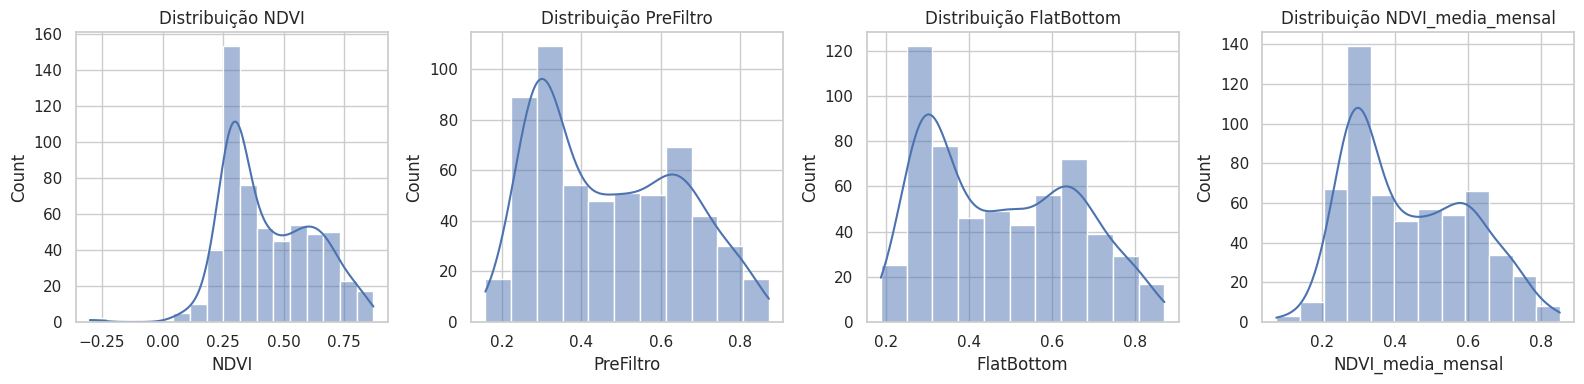


  Série Temporal - NDVI Original:


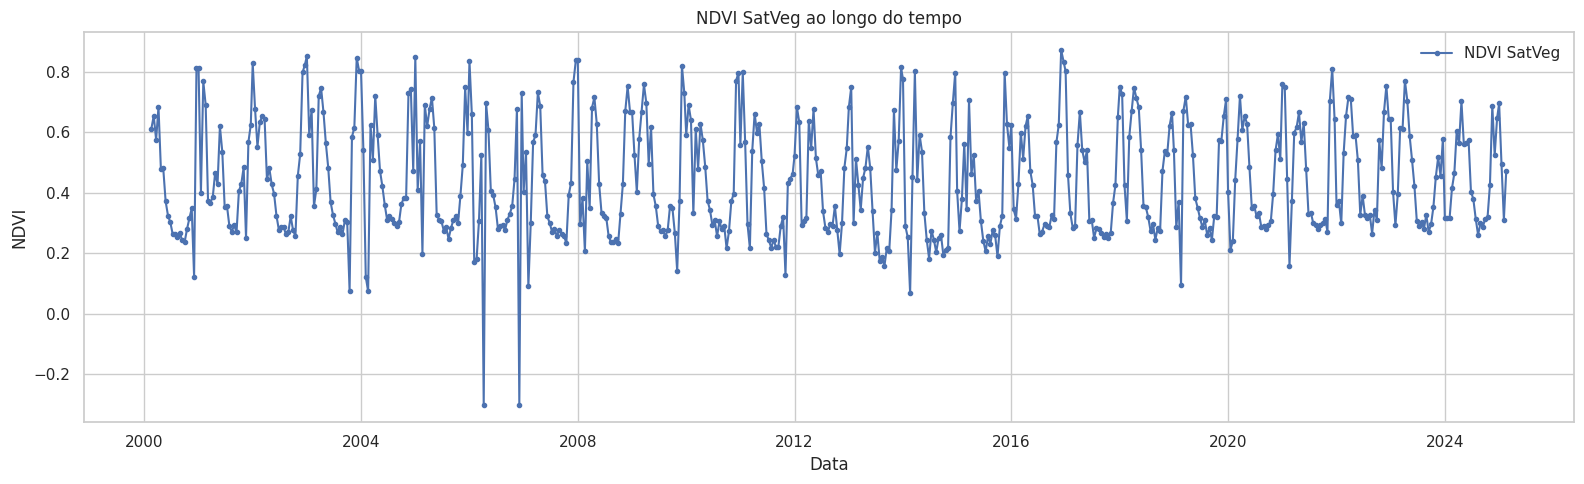


  Perfil Sazonal Médio - NDVI Original:


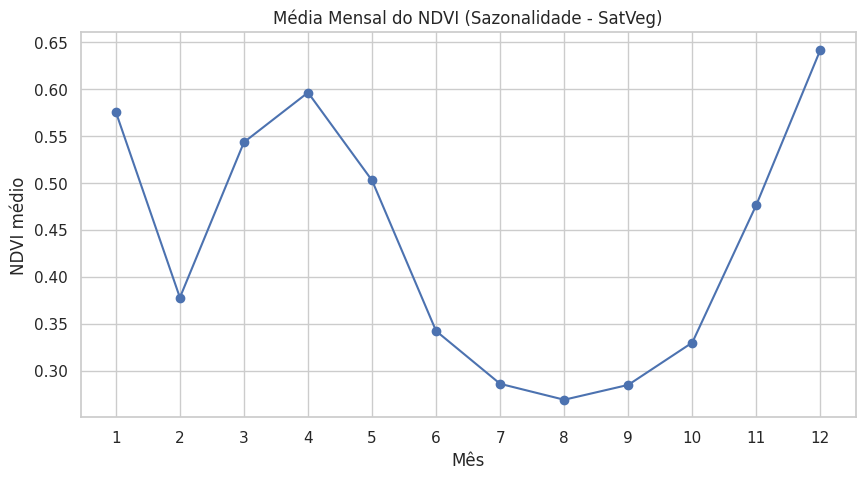


  Decomposição da Série Temporal (NDVI Médio Mensal):


<ipython-input-14-5bcd8107ba94>:46: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ndvi_monthly_decomp = df_satveg_proc.set_index('Data')['NDVI_media_mensal'].resample('M').mean().interpolate()


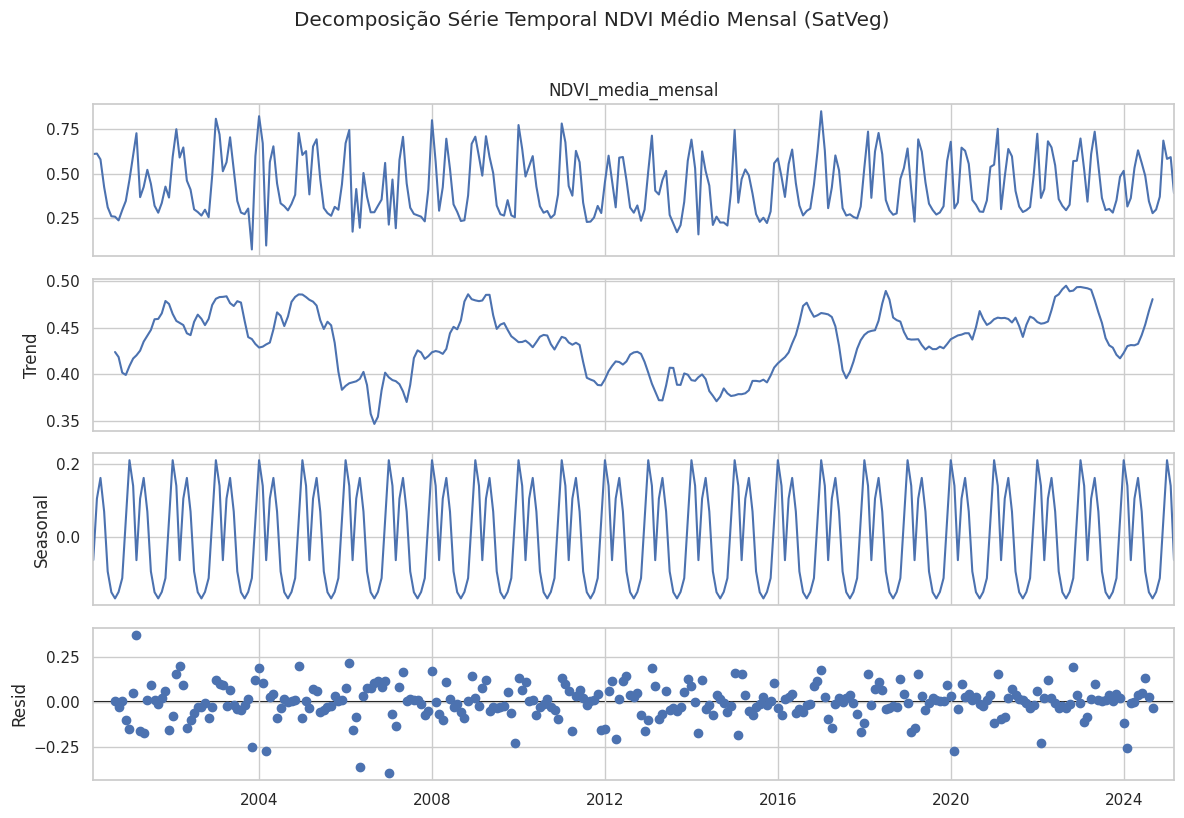


--- Fim  da análise exploratória ---


In [14]:
# --- Análise Exploratória  ---

print("\n---  Análise Exploratória (SatVeg) ---")

# Só executa se a etapa anterior criou df_satveg_proc com sucesso
if 'df_satveg_proc' in locals() and isinstance(df_satveg_proc, pd.DataFrame) and not df_satveg_proc.empty:

    colunas_numericas_plot = ['NDVI', 'PreFiltro', 'FlatBottom', 'NDVI_media_mensal']
    colunas_numericas_plot = [col for col in colunas_numericas_plot if col in df_satveg_proc.columns] # Garante que existem

    if colunas_numericas_plot:
        # Distribuições (histogramas)
        print("\n  Histogramas - Distribuição das variáveis:")
        n_cols_plot = len(colunas_numericas_plot)
        plt.figure(figsize=(4 * n_cols_plot, 4))
        for i, coluna in enumerate(colunas_numericas_plot):
            plt.subplot(1, n_cols_plot, i + 1)
            sns.histplot(df_satveg_proc[coluna].dropna(), kde=True) # dropna() para hist
            plt.title(f'Distribuição {coluna}')
        plt.tight_layout()
        plt.show()

        # Serie temporal completa (NDVI original)
        if 'Data' in df_satveg_proc.columns and 'NDVI' in df_satveg_proc.columns:
            print("\n  Série Temporal - NDVI Original:")
            plt.figure(figsize=(16,5))
            plt.plot(df_satveg_proc['Data'], df_satveg_proc['NDVI'], marker='.', linestyle='-', label='NDVI SatVeg')
            plt.title('NDVI SatVeg ao longo do tempo')
            plt.xlabel('Data'); plt.ylabel('NDVI')
            plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

        # Gráfico da média mensal (sazonalidade típica)
        if 'MES' in df_satveg_proc.columns and 'NDVI' in df_satveg_proc.columns:
            print("\n  Perfil Sazonal Médio - NDVI Original:")
            ndvi_media_mensal_plot = df_satveg_proc.groupby('MES')['NDVI'].mean()
            plt.figure(figsize=(10,5))
            plt.plot(ndvi_media_mensal_plot.index, ndvi_media_mensal_plot.values, marker='o')
            plt.title('Média Mensal do NDVI (Sazonalidade - SatVeg)')
            plt.xlabel('Mês'); plt.ylabel('NDVI médio')
            plt.xticks(range(1,13)); plt.grid(True); plt.show()

        # Decomposição da série temporal (NDVI Médio Mensal)
        if 'Data' in df_satveg_proc.columns and 'NDVI_media_mensal' in df_satveg_proc.columns:
             print("\n  Decomposição da Série Temporal (NDVI Médio Mensal):")
             # Prepara série mensal para decomposição (resample e interpola)
             ndvi_monthly_decomp = df_satveg_proc.set_index('Data')['NDVI_media_mensal'].resample('M').mean().interpolate()
             if len(ndvi_monthly_decomp) >= 24:
                  decomp = sm.tsa.seasonal_decompose(ndvi_monthly_decomp, model='additive', period=12)
                  fig = decomp.plot()
                  fig.set_size_inches(12, 8)
                  plt.suptitle('Decomposição Série Temporal NDVI Médio Mensal (SatVeg)', y=1.02)
                  plt.tight_layout()
                  plt.show()
             else:
                  print("     Dados insuficientes (< 24 meses) para realizar a decomposição temporal.")

    else:
        print("  Nenhuma coluna numérica encontrada para plotar.")
else:
    print("  DataFrame processado 'df_satveg_proc' não disponível ou vazio. Análise exploratória pulada.")

print("\n--- Fim  da análise exploratória ---")


In [15]:
#  Salvar Resultado Processado

print("\n---  Salvar Resultado Processado (SatVeg) ---")

# Só salva se a etapa anterior criou df_satveg_proc com sucesso
if 'df_satveg_proc' in locals() and isinstance(df_satveg_proc, pd.DataFrame) and not df_satveg_proc.empty:
    # Define as colunas FINAIS desejadas
    colunas_finais_satveg = [
        'Data', 'ANO', 'MES', 'AnoMes', 'NDVI', 'PreFiltro',
        'FlatBottom', 'NDVI_media_mensal'
    ]
    # Seleciona apenas as colunas que existem
    colunas_presentes_satveg = [col for col in colunas_finais_satveg if col in df_satveg_proc.columns]
    df_final_satveg = df_satveg_proc[colunas_presentes_satveg].copy()

    # Define o caminho de saída
    caminho_saida_satveg = os.path.join(pasta_dados_processados, 'satveg_processado.csv')
    try:
        # Salva o DataFrame final
        df_final_satveg.to_csv(caminho_saida_satveg, index=False, encoding='utf-8', date_format='%Y-%m-%d')
        print(f"[OK] Dados SatVeg processados salvos em: {caminho_saida_satveg}")
        print("\n  Informações do DataFrame Salvo:")
        df_final_satveg.info()
        print("\n  Primeiras linhas do DataFrame Salvo:")
        print(df_final_satveg.head())
    except Exception as e:
        print(f"[ERRO] Falha ao salvar o arquivo processado: {e}")
else:
    print("[ERRO] DataFrame processado 'df_satveg_proc' não disponível ou vazio. Nenhum arquivo salvo.")

print("\n--- Fim do Bloco 5: Salvar Resultado ---")
print("\n=== FIM DA ETAPA 1 (Processamento SatVeg) ===")



---  Salvar Resultado Processado (SatVeg) ---
[OK] Dados SatVeg processados salvos em: dados_processados/satveg_processado.csv

  Informações do DataFrame Salvo:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Data               576 non-null    datetime64[ns]
 1   ANO                576 non-null    Int64         
 2   MES                576 non-null    Int64         
 3   AnoMes             576 non-null    object        
 4   NDVI               576 non-null    float64       
 5   PreFiltro          576 non-null    float64       
 6   FlatBottom         576 non-null    float64       
 7   NDVI_media_mensal  576 non-null    float64       
dtypes: Int64(2), datetime64[ns](1), float64(4), object(1)
memory usage: 37.3+ KB

  Primeiras linhas do DataFrame Salvo:
        Data   ANO  MES   AnoMes    NDVI  PreFiltro  FlatBott

# Dados metereológicos ☀️☁️🌧️☂️🌬️
Optamos por fazer download dos arquivos, pois via API ia ficar muito lento

Fonte de dados https://portal.inmet.gov.br/dadoshistoricos

(Período: 2002 - 2025 (GAP anos 2021 e 2022, começa em 21/10/2022)


In [17]:
# Pré-processamento Clima INMET

# --- Configuração Inicial e Upload ---


print("--- Bloco 1: Configuração inicial e upload  ---")

# Importar Bibliotecas Essenciais
import pandas as pd
import numpy as np
import os
import glob
import re
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import shutil

# Tentar importar do Colab para upload/download
try:
    from google.colab import files
    IN_COLAB = True
    print("Executando no Google Colab.")
except ImportError:
    IN_COLAB = False
    print("Executando localmente.")

    class DummyFiles:
        def upload(self):
            print("AVISO: upload não disponível localmente.")

            dummy_path = os.path.join('dados_originais', 'sorriso_dummy.csv')
            if not os.path.exists(dummy_path):
                 os.makedirs('dados_originais', exist_ok=True)
                 with open(dummy_path, 'w', encoding='utf-8') as f:

                      f.write("DATA_ORIGINAL;HORA_ORIGINAL;PRECIPITACAO_TOTAL_HORARIO(mm);PRESSAO_ATM_NIVEL_ESTACAO_HORARIA(mB);PRESSAO_ATM_MAX_HORA_ANT(mB);PRESSAO_ATM_MIN_HORA_ANT(mB);RADIACAO_GLOBAL(KJ/m²);TEMP_AR_BULBO_SECO_HORARIA(°C);TEMP_PONTO_ORVALHO(°C);TEMP_MAX_HORA_ANT(°C);TEMP_MIN_HORA_ANT(°C);TEMP_ORVALHO_MAX_HORA_ANT(°C);TEMP_ORVALHO_MIN_HORA_ANT(°C);UMID_REL_MAX_HORA_ANT(%);UMID_REL_MIN_HORA_ANT(%);UMID_REL_AR_HORARIA(%);VENTO_DIRECAO_HORARIA(gr);VENTO_RAJADA_MAXIMA(m/s);VENTO_VELOCIDADE_HORARIA(m/s)\n")
                 print(f"       Arquivo dummy '{dummy_path}' criado para execução local.")
            return {}

        def download(self, path):
            print(f"AVISO: download não disponível localmente. Arquivo em: {path}")
    files = DummyFiles()

# Configurações Gerais de Plotagem
try:
    plt.style.use('seaborn-v0_8-whitegrid')
    print("Estilo de plotagem 'seaborn-v0_8-whitegrid' aplicado.")
except OSError:
    print("Estilo 'seaborn-v0_8-whitegrid' não encontrado, tentando 'seaborn-whitegrid'...")
    try:
        plt.style.use('seaborn-whitegrid')
        print("Estilo de plotagem 'seaborn-whitegrid' aplicado.")
    except OSError:
        print("Nenhum estilo seaborn encontrado. Usando estilo padrão do Matplotlib.")
sns.set(style="whitegrid")

# Definir Pastas
pasta_dados_originais = 'dados_originais'
pasta_dados_processados = 'dados_processados'
os.makedirs(pasta_dados_originais, exist_ok=True); os.makedirs(pasta_dados_processados, exist_ok=True)
print(f"Diretórios '{pasta_dados_originais}' e '{pasta_dados_processados}' verificados/criados.")
padrao_limpeza = 'sorriso_*.csv'; print(f"\n--- Limpando arquivos '{padrao_limpeza}' antigos de '{pasta_dados_originais}' ---")
arquivos_antigos = glob.glob(os.path.join(pasta_dados_originais, padrao_limpeza))
if arquivos_antigos:
    for f_antigo in arquivos_antigos:
        try: os.remove(f_antigo); print(f"  Removido: {os.path.basename(f_antigo)}")
        except OSError as e: print(f"  Erro ao remover {os.path.basename(f_antigo)}: {e}")
    print("--- Limpeza concluída ---")
else: print(f"--- Nenhum arquivo com padrão '{padrao_limpeza}' encontrado para limpar ---")
if IN_COLAB:
    print("\n--- Upload Arquivos INMET ---"); print(f"Faça o upload dos seus arquivos CSV do INMET (ex: sorriso_YYYY.csv)")
    uploaded_clima = files.upload(); print(f"\nMovendo arquivos carregados para '{pasta_dados_originais}'...")
    for filename in uploaded_clima.keys():
        try: source_path = filename; destination_path = os.path.join(pasta_dados_originais, filename); shutil.move(source_path, destination_path); print(f"  Movido: {filename} -> {pasta_dados_originais}/")
        except Exception as e: print(f"Erro ao mover {filename}: {e}.")
padrao_busca = 'sorriso_*.csv'; clima_brutos_paths = sorted(glob.glob(os.path.join(pasta_dados_originais, padrao_busca)))
print(f"\nArquivos encontrados em '{pasta_dados_originais}' com padrão '{padrao_busca}': {len(clima_brutos_paths)}")
print("\n--- Fim da configuração e upload ---")


--- Bloco 1: Configuração Inicial e Upload (Clima INMET) ---
Executando no Google Colab.
Estilo de plotagem 'seaborn-v0_8-whitegrid' aplicado.
Diretórios 'dados_originais' e 'dados_processados' verificados/criados.

--- Limpando arquivos 'sorriso_*.csv' antigos de 'dados_originais' ---
--- Nenhum arquivo com padrão 'sorriso_*.csv' encontrado para limpar ---

--- Upload Arquivos INMET ---
Faça o upload dos seus arquivos CSV do INMET (ex: sorriso_YYYY.csv)


Saving sorriso_2002.csv to sorriso_2002.csv
Saving sorriso_2003.csv to sorriso_2003.csv
Saving sorriso_2004.csv to sorriso_2004.csv
Saving sorriso_2005.csv to sorriso_2005.csv
Saving sorriso_2006.csv to sorriso_2006.csv
Saving sorriso_2007.csv to sorriso_2007.csv
Saving sorriso_2008.csv to sorriso_2008.csv
Saving sorriso_2009.csv to sorriso_2009.csv
Saving sorriso_2010.csv to sorriso_2010.csv
Saving sorriso_2011.csv to sorriso_2011.csv
Saving sorriso_2012.csv to sorriso_2012.csv
Saving sorriso_2013.csv to sorriso_2013.csv
Saving sorriso_2014.csv to sorriso_2014.csv
Saving sorriso_2015.csv to sorriso_2015.csv
Saving sorriso_2016.csv to sorriso_2016.csv
Saving sorriso_2017.csv to sorriso_2017.csv
Saving sorriso_2018.csv to sorriso_2018.csv
Saving sorriso_2019.csv to sorriso_2019.csv
Saving sorriso_2020.csv to sorriso_2020.csv
Saving sorriso_2022.csv to sorriso_2022.csv
Saving sorriso_2023.csv to sorriso_2023.csv
Saving sorriso_2024.csv to sorriso_2024.csv
Saving sorriso_2025.csv to sorri

In [18]:
# Carregamento e Concatenação ---

print("\n---  Carregamento e Concatenação (Clima INMET) ---")
dfs_lidos = []
nomes_colunas_inmet = [
    'DATA_ORIGINAL', 'HORA_ORIGINAL', 'PRECIPITACAO_TOTAL_HORARIO(mm)',
    'PRESSAO_ATM_NIVEL_ESTACAO_HORARIA(mB)', 'PRESSAO_ATM_MAX_HORA_ANT(mB)',
    'PRESSAO_ATM_MIN_HORA_ANT(mB)', 'RADIACAO_GLOBAL(KJ/m²)',
    'TEMP_AR_BULBO_SECO_HORARIA(°C)', 'TEMP_PONTO_ORVALHO(°C)',
    'TEMP_MAX_HORA_ANT(°C)', 'TEMP_MIN_HORA_ANT(°C)',
    'TEMP_ORVALHO_MAX_HORA_ANT(°C)', 'TEMP_ORVALHO_MIN_HORA_ANT(°C)',
    'UMID_REL_MAX_HORA_ANT(%)', 'UMID_REL_MIN_HORA_ANT(%)',
    'UMID_REL_AR_HORARIA(%)', 'VENTO_DIRECAO_HORARIA(gr)',
    'VENTO_RAJADA_MAXIMA(m/s)', 'VENTO_VELOCIDADE_HORARIA(m/s)'
]
n_cols_esperadas = len(nomes_colunas_inmet)
print(f"  Esperando {n_cols_esperadas} colunas nos arquivos CSV.")
if 'clima_brutos_paths' not in locals() or not clima_brutos_paths:
    print(f"[ERRO] Nenhum arquivo CSV encontrado ou lista 'clima_brutos_paths' não definida. Execute o Bloco 1.")
    df_clima_raw = None
else:
    for arq in clima_brutos_paths:
        print(f"  Processando: {os.path.basename(arq)}")
        df_temp = None; separador_usado = None; read_success = False
        try:
            try:
                df_temp = pd.read_csv(arq, sep=";", encoding='latin1', skiprows=8, header=None, names=nomes_colunas_inmet, usecols=range(n_cols_esperadas), on_bad_lines='warn', decimal=',')
                if df_temp.shape[1] == n_cols_esperadas: separador_usado = ';'; read_success = True
                else: raise ValueError(f"Cols={df_temp.shape[1]} com sep=';'.")
            except Exception as e1:
                try:
                    print(f"      Falha com ';'. Tentando sep=','...");
                    df_temp = pd.read_csv(arq, sep=",", encoding='latin1', skiprows=8, header=None, names=nomes_colunas_inmet, usecols=range(n_cols_esperadas), on_bad_lines='warn', decimal='.')
                    if df_temp.shape[1] == n_cols_esperadas: separador_usado = ','; read_success = True; print("      [OK] Lido com sep=','.")
                    else: raise ValueError(f"Cols={df_temp.shape[1]} com sep=','. ")
                except Exception as e2: print(f"    [ERRO] Falha final ao ler {arq}: {e2}. Pulando."); continue
            if read_success and df_temp is not None: dfs_lidos.append(df_temp)
        except Exception as e: print(f"    [ERRO] Falha inesperada ao processar {arq}: {e}")
    if dfs_lidos:
        df_clima_raw = pd.concat(dfs_lidos, ignore_index=True); print(f"\n[OK] Dados brutos concatenados. Total de linhas: {df_clima_raw.shape[0]}")
    else: print("[ERRO] Nenhum arquivo de clima lido com sucesso."); df_clima_raw = None
print("\n--- Fim do Bloco 2: Carregamento e Concatenação ---")



---  Carregamento e Concatenação (Clima INMET) ---
  Esperando 19 colunas nos arquivos CSV.
  Processando: sorriso_2002.csv
  Processando: sorriso_2003.csv
  Processando: sorriso_2004.csv
  Processando: sorriso_2005.csv
  Processando: sorriso_2006.csv
  Processando: sorriso_2007.csv
  Processando: sorriso_2008.csv
  Processando: sorriso_2009.csv
  Processando: sorriso_2010.csv
  Processando: sorriso_2011.csv
  Processando: sorriso_2012.csv
  Processando: sorriso_2013.csv
  Processando: sorriso_2014.csv
  Processando: sorriso_2015.csv
  Processando: sorriso_2016.csv
  Processando: sorriso_2017.csv
  Processando: sorriso_2018.csv
  Processando: sorriso_2019.csv
  Processando: sorriso_2020.csv
  Processando: sorriso_2022.csv
  Processando: sorriso_2023.csv
  Processando: sorriso_2024.csv
  Processando: sorriso_2025.csv

[OK] Dados brutos concatenados. Total de linhas: 179436

--- Fim do Bloco 2: Carregamento e Concatenação ---


In [19]:
# Processamento principal

print("\n--- Processamento Principal (com Diagnóstico Detalhado) ---")

df_clima_proc = None

# Só executa se a etapa anterior criou df_clima_raw
if 'df_clima_raw' in locals() and isinstance(df_clima_raw, pd.DataFrame):
    df_clima_renomeado = df_clima_raw.copy() # Trabalha em uma cópia

    # --- Renomeação das colunas  = em nomes_colunas_inmet) ---
    print("  Renomeando colunas para nomes padronizados...")
    rename_map_clima = {
        'DATA_ORIGINAL': 'DATA_STR', 'HORA_ORIGINAL': 'HORA_UTC',
        'PRECIPITACAO_TOTAL_HORARIO(mm)': 'PRECIPITACAO_mm',
        'PRESSAO_ATM_NIVEL_ESTACAO_HORARIA(mB)': 'PRESSAO_ATMO_ESTACAO',
        'PRESSAO_ATM_MAX_HORA_ANT(mB)': 'PRESSAO_ATMO_MAX',
        'PRESSAO_ATM_MIN_HORA_ANT(mB)': 'PRESSAO_ATMO_MIN',
        'RADIACAO_GLOBAL(KJ/m²)': 'RADIACAO_kJ_m2',
        'TEMP_AR_BULBO_SECO_HORARIA(°C)': 'TEMPERATURA_C',
        'TEMP_PONTO_ORVALHO(°C)': 'TEMPERATURA_ORVALHO',
        'TEMP_MAX_HORA_ANT(°C)': 'TEMP_MAX_ANT_C', 'TEMP_MIN_HORA_ANT(°C)': 'TEMP_MIN_ANT_C',
        'TEMP_ORVALHO_MAX_HORA_ANT(°C)': 'TEMP_ORVALHO_MAX', 'TEMP_ORVALHO_MIN_HORA_ANT(°C)': 'TEMP_ORVALHO_MIN',
        'UMID_REL_MAX_HORA_ANT(%)': 'UMID_REL_MAX_ANT_perc', 'UMID_REL_MIN_HORA_ANT(%)': 'UMID_REL_MIN_ANT_perc',
        'UMID_REL_AR_HORARIA(%)': 'UMID_REL_perc', 'VENTO_DIRECAO_HORARIA(gr)': 'VENTO_DIR_graus',
        'VENTO_RAJADA_MAXIMA(m/s)': 'VENTO_RAJADA_MAX_ms', 'VENTO_VELOCIDADE_HORARIA(m/s)': 'VENTO_VEL_ms'
    }
    cols_a_renomear_clima = {k: v for k, v in rename_map_clima.items() if k in df_clima_renomeado.columns}
    df_clima_renomeado.rename(columns=cols_a_renomear_clima, inplace=True)
    print(f"  Colunas renomeadas para nomes internos (exemplo): {list(cols_a_renomear_clima.values())[:7]}...")

    # --- Pré-processamento usando Nomes Internos ---
    print("  Iniciando pré-processamento do clima...")


    print("\n    --- DIAGNÓSTICO PRÉ-CONVERSÃO DATA/HORA ---")
    if 'DATA_STR' in df_clima_renomeado.columns and 'HORA_UTC' in df_clima_renomeado.columns:
        print("    Conteúdo das colunas DATA_STR e HORA_UTC (primeiras 10 linhas):")
        print(df_clima_renomeado[['DATA_STR', 'HORA_UTC']].head(10))
        print("\n    Conteúdo das colunas DATA_STR e HORA_UTC (últimas 10 linhas):")
        print(df_clima_renomeado[['DATA_STR', 'HORA_UTC']].tail(10))
        print("\n    Valores Nulos ANTES da conversão:")
        print(f"      DATA_STR: {df_clima_renomeado['DATA_STR'].isnull().sum()}")
        print(f"      HORA_UTC: {df_clima_renomeado['HORA_UTC'].isnull().sum()}")
        print("\n    Formatos únicos (amostra) em DATA_STR:")
        try: print(df_clima_renomeado['DATA_STR'].astype(str).str.strip().unique()[:20])
        except: print("      Erro ao obter formatos únicos de DATA_STR.")
        print("\n    Formatos únicos (amostra) em HORA_UTC:")
        try: print(df_clima_renomeado['HORA_UTC'].astype(str).str.strip().unique()[:20])
        except: print("      Erro ao obter formatos únicos de HORA_UTC.")
    else:
        print("    [ERRO] Colunas DATA_STR ou HORA_UTC não encontradas para diagnóstico.")
    print("    --------------------------------------------")


    # Combinar Data e Hora
    try:
        if 'DATA_STR' in df_clima_renomeado.columns and 'HORA_UTC' in df_clima_renomeado.columns:

            data_str_col = df_clima_renomeado['DATA_STR'].astype(str).str.strip()
            hora_utc_col = df_clima_renomeado['HORA_UTC'].astype(str).str.strip()

            # Tenta o formato DD/MM/YYYY HH:MM:SS primeiro
            print("\n    Tentando formato DD/MM/YYYY HH:MM:SS...")
            df_clima_renomeado['DATA'] = pd.to_datetime(data_str_col + ' ' + hora_utc_col,
                                                       format='%d/%m/%Y %H:%M:%S', errors='coerce')

            # Verifica quantas falharam e tenta outros formatos para as linhas que falharam
            mask_failed = df_clima_renomeado['DATA'].isnull()
            if mask_failed.any():
                print(f"    Formato DD/MM/YYYY HH:MM:SS falhou para {mask_failed.sum()} linhas.")
                # Tenta YYYY/MM/DD HH:MM:SS
                print("    Tentando formato YYYY/MM/DD HH:MM:SS...")
                df_clima_renomeado.loc[mask_failed, 'DATA'] = pd.to_datetime(df_clima_renomeado.loc[mask_failed, 'DATA_STR'] + ' ' + df_clima_renomeado.loc[mask_failed, 'HORA_UTC'],
                                                                               format='%Y/%m/%d %H:%M:%S', errors='coerce')
                mask_failed = df_clima_renomeado['DATA'].isnull() # Atualiza a máscara
                if mask_failed.any():
                    print(f"    Formato YYYY/MM/DD HH:MM:SS falhou para {mask_failed.sum()} linhas.")
                    # Tenta DD/MM/YYYY HHMM (formatando a hora)
                    print("    Tentando formato DD/MM/YYYY HHMM...")
                    hora_hhmm = hora_utc_col.str.replace(':', '', regex=False).str.slice(0, 4)
                    df_clima_renomeado.loc[mask_failed, 'DATA'] = pd.to_datetime(df_clima_renomeado.loc[mask_failed, 'DATA_STR'] + ' ' + hora_hhmm[mask_failed],
                                                                                format='%d/%m/%Y %H%M', errors='coerce')
                    mask_failed = df_clima_renomeado['DATA'].isnull() # Atualiza a máscara
                    if mask_failed.any():
                        print(f"    Formato DD/MM/YYYY HHMM falhou para {mask_failed.sum()} linhas.")
                        # Tenta YYYY/MM/DD HHMM
                        print("    Tentando formato YYYY/MM/DD HHMM...")
                        df_clima_renomeado.loc[mask_failed, 'DATA'] = pd.to_datetime(df_clima_renomeado.loc[mask_failed, 'DATA_STR'] + ' ' + hora_hhmm[mask_failed],
                                                                                    format='%Y/%m/%d %H%M', errors='coerce')
                        mask_failed = df_clima_renomeado['DATA'].isnull() # Atualiza a máscara
                        if mask_failed.any():
                             print(f"    [AVISO FINAL] {mask_failed.sum()} linhas não puderam ser convertidas para datetime com os formatos testados.")

            # Remove linhas onde a conversão falhou completamente
            linhas_antes = len(df_clima_renomeado)
            df_clima_renomeado.dropna(subset=['DATA'], inplace=True)
            removidos = linhas_antes - len(df_clima_renomeado)
            if removidos > 0: print(f"    - {removidos} linhas removidas por data/hora inválida final.")
            print("    - Coluna 'DATA' (datetime) criada/atualizada.")
            # <<< Check após criar DATA >>>
            if not df_clima_renomeado.empty: print(f"    >>> CHECK 1 - Min Data: {df_clima_renomeado['DATA'].min()}, Max Data: {df_clima_renomeado['DATA'].max()}")
            else: print("    >>> CHECK 1 - DataFrame vazio após dropna de DATA.")
        else: raise ValueError("Colunas de Data/Hora não encontradas.")

    except Exception as e_dt:
        print(f"[ERRO CRÍTICO] Falha ao criar coluna DATA datetime: {e_dt}")
        df_clima_renomeado = None

    # Prossegue apenas se a data foi criada com sucesso
    if df_clima_renomeado is not None:
        # Filtrar por ano
        ano_inicio_filtro = 2002; linhas_antes_filtro = len(df_clima_renomeado)
        if pd.api.types.is_datetime64_any_dtype(df_clima_renomeado['DATA']):
             df_clima_renomeado = df_clima_renomeado[df_clima_renomeado['DATA'].dt.year >= ano_inicio_filtro].copy()
             removidos_filtro = linhas_antes_filtro - len(df_clima_renomeado)
             if removidos_filtro > 0: print(f"  [FILTRO] Removidas {removidos_filtro} linhas com ano anterior a {ano_inicio_filtro}.")
             print(f"  Dados filtrados a partir de {ano_inicio_filtro}. Linhas restantes: {len(df_clima_renomeado)}")
             if df_clima_renomeado.empty: raise ValueError(f"Nenhum dado encontrado a partir do ano {ano_inicio_filtro}.")
             else: print(f"    >>> CHECK 2 - Min Data: {df_clima_renomeado['DATA'].min()}, Max Data: {df_clima_renomeado['DATA'].max()}")
        else: raise TypeError("Coluna DATA não é datetime. Filtro por ano falhou.")

    # Prossegue apenas se ainda houver dados
    if df_clima_renomeado is not None and not df_clima_renomeado.empty:
        # Criar colunas ANO, MES, ANO_MES
        df_clima_renomeado['ANO'] = df_clima_renomeado['DATA'].dt.year.astype('Int64'); df_clima_renomeado['MES'] = df_clima_renomeado['DATA'].dt.month.astype('Int64'); df_clima_renomeado['ANO_MES'] = df_clima_renomeado['DATA'].dt.strftime('%Y-%m')
        print("    - Colunas 'ANO', 'MES', 'ANO_MES' criadas/atualizadas.")

        # Tratar colunas numéricas principais
        print("    - Convertendo e tratando colunas numéricas principais:")
        colunas_principais = {'RADIACAO_kJ_m2': 'Radiação', 'TEMPERATURA_C': 'Temperatura', 'PRECIPITACAO_mm': 'Precipitação', 'UMID_REL_perc': 'Umidade Relativa', 'VENTO_VEL_ms': 'Velocidade Vento'}
        for col_interno, nome_legivel in colunas_principais.items():
            if col_interno in df_clima_renomeado.columns:
                df_clima_renomeado[col_interno] = pd.to_numeric(df_clima_renomeado[col_interno], errors='coerce')
                df_clima_renomeado[col_interno] = df_clima_renomeado[col_interno].replace(-9999, np.nan)
                if col_interno == 'RADIACAO_kJ_m2':
                     df_clima_renomeado.loc[df_clima_renomeado[col_interno] < 0, col_interno] = np.nan; print("      [AVISO] Convertendo Radiação..."); df_clima_renomeado['RADIACAO'] = df_clima_renomeado[col_interno] / 3.6
                elif col_interno == 'TEMPERATURA_C': df_clima_renomeado['TEMPERATURA'] = df_clima_renomeado[col_interno]
                elif col_interno == 'PRECIPITACAO_mm': df_clima_renomeado.loc[df_clima_renomeado[col_interno] < 0, col_interno] = 0
                elif col_interno == 'UMID_REL_perc': df_clima_renomeado.loc[~df_clima_renomeado[col_interno].between(0, 100), col_interno] = np.nan; df_clima_renomeado['UMIDADE_RELATIVA'] = df_clima_renomeado[col_interno]
                elif col_interno == 'VENTO_VEL_ms': df_clima_renomeado.loc[df_clima_renomeado[col_interno] < 0, col_interno] = np.nan; df_clima_renomeado['VENTO_VELOCIDADE'] = df_clima_renomeado[col_interno]
                print(f"      Coluna '{nome_legivel}' ({col_interno}) tratada.")
            else:
                print(f"      Atenção: Coluna '{nome_legivel}' ({col_interno}) não encontrada."); # Cria coluna padrão com NaN
                if col_interno == 'RADIACAO_kJ_m2': df_clima_renomeado['RADIACAO'] = np.nan
                if col_interno == 'TEMPERATURA_C': df_clima_renomeado['TEMPERATURA'] = np.nan
                if col_interno == 'PRECIPITACAO_mm': df_clima_renomeado['PRECIPITACAO_mm'] = np.nan
                if col_interno == 'UMID_REL_perc': df_clima_renomeado['UMIDADE_RELATIVA'] = np.nan
                if col_interno == 'VENTO_VEL_ms': df_clima_renomeado['VENTO_VELOCIDADE'] = np.nan

        # Calcular médias diárias usando nomes PADRÃO
        colunas_para_media = [c for c in ['RADIACAO', 'TEMPERATURA', 'UMIDADE_RELATIVA', 'VENTO_VELOCIDADE'] if c in df_clima_renomeado.columns]
        if colunas_para_media:
            df_clima_renomeado['date_only'] = df_clima_renomeado['DATA'].dt.date
            daily_averages = df_clima_renomeado.groupby('date_only')[colunas_para_media].mean()
            rename_avg = {'RADIACAO': 'RADIACAO_media_diaria', 'TEMPERATURA': 'TEMPERATURA_media_diaria', 'UMIDADE_RELATIVA': 'UMIDADE_media_diaria', 'VENTO_VELOCIDADE': 'VENTO_VEL_media_diaria'}
            rename_avg_presentes = {k: v for k, v in rename_avg.items() if k in daily_averages.columns}
            daily_averages = daily_averages.rename(columns=rename_avg_presentes)
            df_clima_renomeado = pd.merge(df_clima_renomeado, daily_averages.reset_index(), on='date_only', how='left')
            df_clima_renomeado = df_clima_renomeado.drop(columns=['date_only'])
            print("    - Médias diárias calculadas.")
            colunas_avg_criadas = list(rename_avg_presentes.values())
            # Antes de remover NaNs das médias diárias
            if not df_clima_renomeado.empty: print(f"    >>> CHECK 3 - Min Data ANTES do dropna final: {df_clima_renomeado['DATA'].min()}, Max Data: {df_clima_renomeado['DATA'].max()}"); print(f"        NaNs em médias diárias ({colunas_avg_criadas}): {df_clima_renomeado[colunas_avg_criadas].isnull().sum().to_dict()}")
            else: print("    >>> CHECK 3 - DataFrame vazio ANTES do dropna final.")
            linhas_antes_nan_avg = len(df_clima_renomeado); df_clima_renomeado.dropna(subset=colunas_avg_criadas, inplace=True); removidos_nan_avg = linhas_antes_nan_avg - len(df_clima_renomeado)
            if removidos_nan_avg > 0: print(f"    - {removidos_nan_avg} linhas removidas por NaNs nas médias diárias.")
            # Depois de remover NaNs das médias diárias
            if not df_clima_renomeado.empty: print(f"    >>> CHECK 4 - Min Data DEPOIS do dropna final: {df_clima_renomeado['DATA'].min()}, Max Data: {df_clima_renomeado['DATA'].max()}")
            else: print("    >>> CHECK 4 - DataFrame vazio DEPOIS do dropna final.")
        else: print("    - Aviso: Não foi possível calcular médias diárias.")

        df_clima_proc = df_clima_renomeado # Atribui resultado final
        print("[OK] Processamento principal concluído.")

    else:
        print("[ERRO] Processamento interrompido devido a erros anteriores.")

else:
    print("[ERRO] DataFrame bruto 'df_clima_raw' não foi criado na etapa anterior.")

print("\n--- Fim do Bloco 3: Processamento Principal ---")



--- Processamento Principal (com Diagnóstico Detalhado) ---
  Renomeando colunas para nomes padronizados...
  Colunas renomeadas para nomes internos (exemplo): ['DATA_STR', 'HORA_UTC', 'PRECIPITACAO_mm', 'PRESSAO_ATMO_ESTACAO', 'PRESSAO_ATMO_MAX', 'PRESSAO_ATMO_MIN', 'RADIACAO_kJ_m2']...
  Iniciando pré-processamento do clima...

    --- DIAGNÓSTICO PRÉ-CONVERSÃO DATA/HORA ---
    Conteúdo das colunas DATA_STR e HORA_UTC (primeiras 10 linhas):
     DATA_STR HORA_UTC
0  16/12/2002    07:00
1  16/12/2002    08:00
2  16/12/2002    09:00
3  16/12/2002    10:00
4  16/12/2002    11:00
5  16/12/2002    12:00
6  16/12/2002    13:00
7  16/12/2002    14:00
8  16/12/2002    15:00
9  16/12/2002    16:00

    Conteúdo das colunas DATA_STR e HORA_UTC (últimas 10 linhas):
          DATA_STR  HORA_UTC
179426  31/03/2025  1400 UTC
179427  31/03/2025  1500 UTC
179428  31/03/2025  1600 UTC
179429  31/03/2025  1700 UTC
179430  31/03/2025  1800 UTC
179431  31/03/2025  1900 UTC
179432  31/03/2025  2000 UTC


--- Análise Exploratória ---
  Gerando gráficos de série temporal...


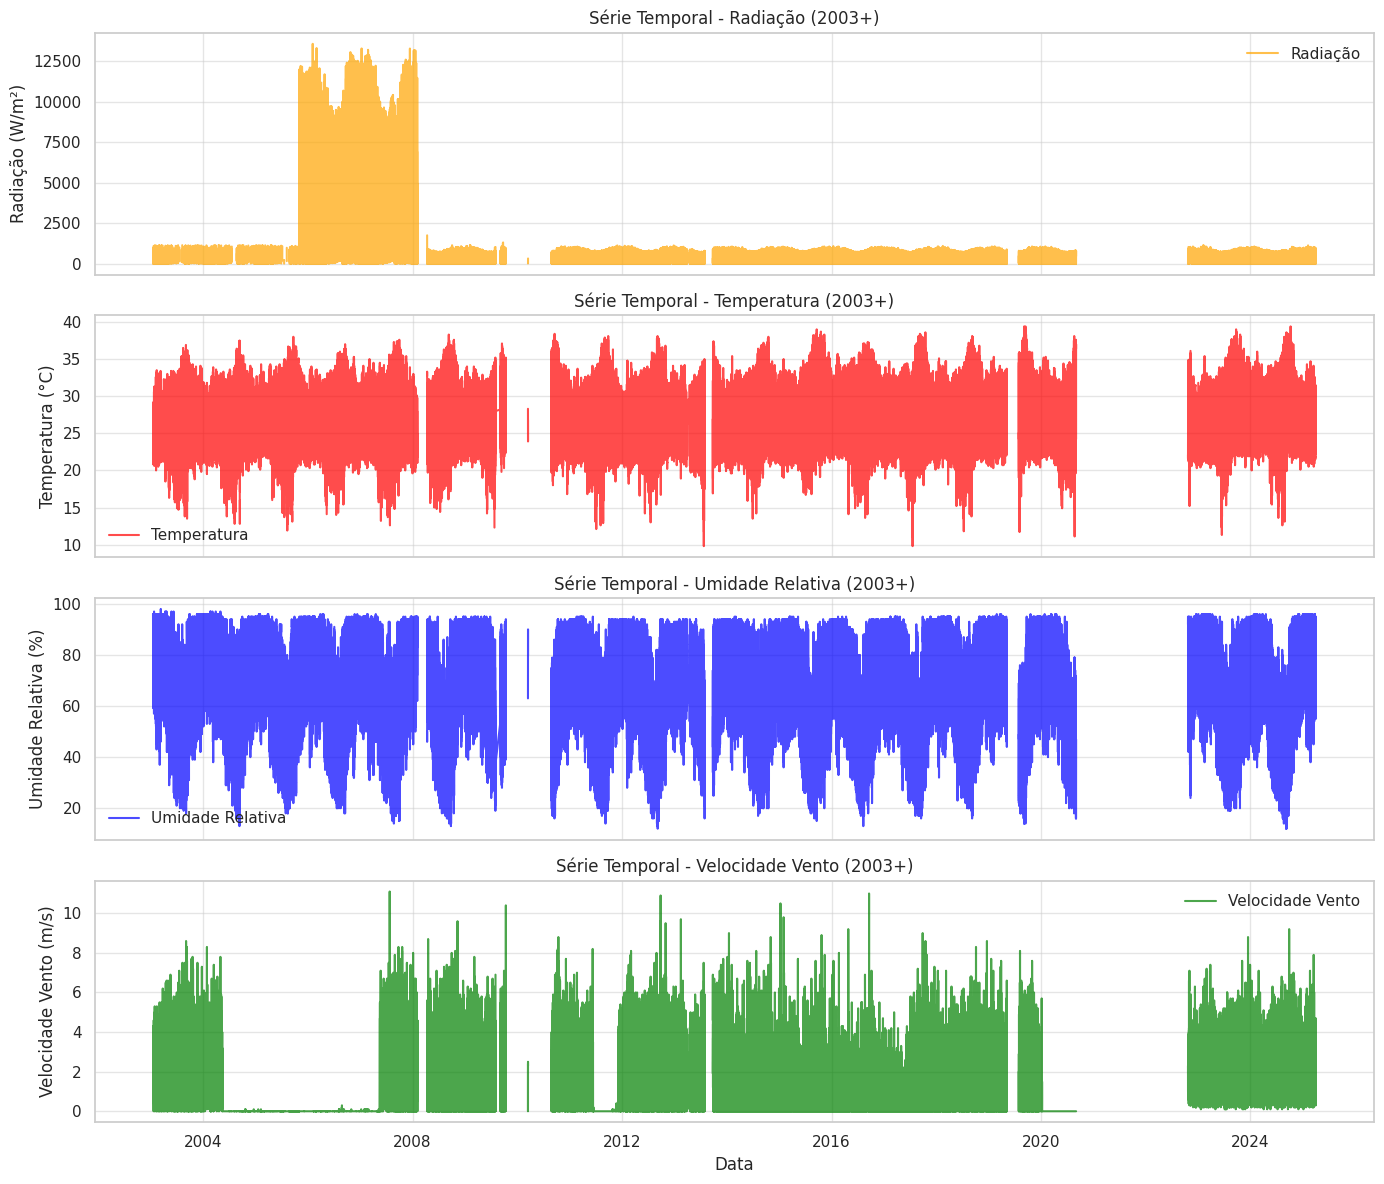


--- Fim da Análise Exploratória ---


In [21]:
# Análise Exploratória

print("\n--- Análise Exploratória ---")
if 'df_clima_proc' in locals() and isinstance(df_clima_proc, pd.DataFrame) and not df_clima_proc.empty:
    print("  Gerando gráficos de série temporal...")
    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
    plot_ok_count = 0
    plot_vars = {'RADIACAO': ('Radiação (W/m²)', 'orange', axes[0]),
                 'TEMPERATURA': ('Temperatura (°C)', 'red', axes[1]),
                 'UMIDADE_RELATIVA': ('Umidade Relativa (%)', 'blue', axes[2]),
                 'VENTO_VELOCIDADE': ('Velocidade Vento (m/s)', 'green', axes[3])}
    for col, (label, color, ax) in plot_vars.items():
        if col in df_clima_proc.columns and not df_clima_proc[col].isnull().all():
            ax.plot(df_clima_proc['DATA'], df_clima_proc[col], label=label.split('(')[0].strip(), alpha=0.7, color=color)
            ax.set_ylabel(label)
            try: ano_min_plot = df_clima_proc["ANO"].min()
            except: ano_min_plot = "Início"
            ax.set_title(f'Série Temporal - {label.split("(")[0].strip()} ({ano_min_plot}+)')
            ax.grid(True, alpha=0.5); ax.legend()
            plot_ok_count += 1
        else: print(f"    - Aviso: Coluna '{col}' não encontrada ou vazia para plot.")
    if plot_ok_count > 0: axes[-1].set_xlabel('Data'); plt.tight_layout(); plt.show()
    else: print("    - Não foi possível gerar gráficos de série temporal.")
else: print("  DataFrame processado 'df_clima_proc' não disponível ou vazio.")
print("\n--- Fim da Análise Exploratória ---")


In [22]:
#  Salvar Resultado Final

print("\n--- Bloco 5: Salvar Resultado Final ---")
if 'df_clima_proc' in locals() and isinstance(df_clima_proc, pd.DataFrame) and not df_clima_proc.empty:
    colunas_finais_clima = [
        'DATA', 'ANO', 'MES', 'ANO_MES',
        'RADIACAO', 'TEMPERATURA', 'PRECIPITACAO_mm', 'UMIDADE_RELATIVA', 'VENTO_VELOCIDADE',
        'RADIACAO_media_diaria', 'TEMPERATURA_media_diaria',
        'UMIDADE_media_diaria', 'VENTO_VEL_media_diaria'
    ]
    colunas_presentes_clima = [col for col in colunas_finais_clima if col in df_clima_proc.columns]
    df_final_clima = df_clima_proc[colunas_presentes_clima].copy()
    caminho_saida = os.path.join(pasta_dados_processados, 'clima_consolidado.csv')
    try:
        df_final_clima.to_csv(caminho_saida, index=False, encoding='utf-8', date_format='%Y-%m-%d %H:%M:%S')
        print(f"[OK] Clima consolidado (2002+) salvo em: {caminho_saida}")
        print("\n  Informações do DataFrame Climático Salvo:")
        df_final_clima.info()
        print("\n  Primeiras linhas do DataFrame Climático Salvo:")
        print(df_final_clima.head())
        if 'DATA' in df_final_clima.columns and pd.api.types.is_datetime64_any_dtype(df_final_clima['DATA']):
            data_minima = df_final_clima['DATA'].min(); data_maxima = df_final_clima['DATA'].max()
            print("\n--- Intervalo de Datas no DataFrame Final ---"); print(f"Data Mínima: {data_minima}"); print(f"Data Máxima: {data_maxima}")
        else: print("\n[AVISO] Não foi possível verificar o intervalo de datas.")
    except Exception as e: print(f"[ERRO] Falha ao salvar o arquivo processado: {e}")
else: print("[ERRO] DataFrame processado 'df_clima_proc' não disponível ou vazio. Nenhum arquivo salvo.")
print("\n--- Fim do Bloco 5: Salvar Resultado ---")
print("\n=== FIM DA ETAPA 1 (Processamento Climático) ===")



--- Bloco 5: Salvar Resultado Final ---
[OK] Clima consolidado (2002+) salvo em: dados_processados/clima_consolidado.csv

  Informações do DataFrame Climático Salvo:
<class 'pandas.core.frame.DataFrame'>
Index: 161313 entries, 754 to 179435
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   DATA                      161313 non-null  datetime64[ns]
 1   ANO                       161313 non-null  Int64         
 2   MES                       161313 non-null  Int64         
 3   ANO_MES                   161313 non-null  object        
 4   RADIACAO                  77055 non-null   float64       
 5   TEMPERATURA               158464 non-null  float64       
 6   PRECIPITACAO_mm           140848 non-null  float64       
 7   UMIDADE_RELATIVA          158464 non-null  float64       
 8   VENTO_VELOCIDADE          158252 non-null  float64       
 9   RADIACAO_media_diaria     1

# Dados Google Earth  🌍

In [24]:
# Acessas as imagens no Google Earth

# Instalar vivliotecas

!pip install earthengine-api geemap
import ee
import geemap
import os
from google.colab import files
import pandas as pd
import time


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.0 MB/s eta 0:00:00


In [26]:
# Autenticar e inicializar o Earth Engine
ee.Authenticate()
ee.Initialize(project="pipoca-452815")

# Defina seu projeto GEE
try:
    # Tenta inicializar no projeto específico primeiro
    ee.Initialize(project="pipoca-452815", quiet=True)
    print("[OK] GEE inicializado no projeto 'pipoca-452815'.")
except Exception as e_proj:
    print(f"[AVISO] Não foi possível inicializar no projeto GEE especificado: {e_proj}.")

    try:
        ee.Initialize(quiet=True)
        print("[OK] GEE inicializado (usando projeto padrão).")
    except Exception as e_init:
         print(f"[ERRO] Falha geral na inicialização do GEE: {e_init}")


# Definir área de interesse: Sorriso-MT
sorriso = ee.Geometry.Point(-55.71, -12.55).buffer(30000)  # 30km de buffer

# Definir período de uma safra completa
start_date = '2023-10-01'
end_date = '2025-03-31'

# Montar o Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Definir pasta no Drive
drive_folder = "EarthEngine_Exports_Mensal"

# Função para calcular o NDVI
def calculate_ndvi(image):
    nir = image.select('B8')
    red = image.select('B4')
    ndvi = nir.subtract(red).divide(nir.add(red)).rename('NDVI')
    return image.addBands(ndvi)

# Função para exportar para o Drive (modificada para incluir ano e mês)
def export_monthly_to_drive(image, name_prefix, year, month, region, scale=30):
    month_str = f"{month:02d}"
    file_name = f"{name_prefix}_{year}_{month_str}"
    task = ee.batch.Export.image.toDrive(
        image=image,
        description=file_name,
        folder=drive_folder,
        fileNamePrefix=file_name,
        region=region.getInfo()['coordinates'],
        scale=scale,
        maxPixels=1e9
    )
    task.start()
    print(f"Exportando {file_name} para o Google Drive...")
    return task

# Criar lista de períodos mensais
date_range = pd.date_range(start=start_date, end=end_date, freq='MS')

# Iterar sobre os meses e exportar as imagens
for date in date_range:
    year = date.year
    month = date.month
    start_month = f'{year}-{month:02d}-01'
    end_month = pd.to_datetime(start_month) + pd.offsets.MonthEnd(0)
    end_month_str = end_month.strftime('%Y-%m-%d')

    # Obter coleção Sentinel-2 para o mês atual
    s2_monthly = ee.ImageCollection('COPERNICUS/S2_SR') \
        .filterDate(start_month, end_month_str) \
        .filterBounds(sorriso) \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
        .select(['B2', 'B3', 'B4', 'B8']) \
        .median()  # Mediana para remover nuvens

    # Calcular NDVI para o mês atual
    ndvi_monthly = s2_monthly.normalizedDifference(['B8', 'B4']).rename('NDVI')

    # Exportar RGB para o mês atual
    export_monthly_to_drive(
        s2_monthly.select(['B4', 'B3', 'B2']).divide(3000).multiply(255).byte(),
        "sorriso_rgb",
        year,
        month,
        sorriso,
        scale=30
    )

    # Exportar NDVI para o mês atual
    export_monthly_to_drive(
        ndvi_monthly,
        "sorriso_ndvi",
        year,
        month,
        sorriso,
        scale=30
    )

print("\nImagens mensais estão sendo exportadas para seu Google Drive.")
print("Este processo pode levar um tempo considerável, dependendo do número de meses e da área.")
print("As imagens estarão na pasta", drive_folder)
print("Você pode verificar o progresso em: https://code.earthengine.google.com/tasks")
print("Quando as tarefas estiverem concluídas, você poderá acessar os arquivos no seu Google Drive")

[AVISO] Não foi possível inicializar no projeto GEE especificado: Initialize() got an unexpected keyword argument 'quiet'.
[ERRO] Falha geral na inicialização do GEE: Initialize() got an unexpected keyword argument 'quiet'
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.11/dist-packages/ee/deprecation.py:207: DeprecationWarning: 

Attention required for COPERNICUS/S2_SR! You are using a deprecated asset.
To make sure your code keeps working, please update it.
Learn more: https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR

  warnings.warn(warning, category=DeprecationWarning)


Exportando sorriso_rgb_2023_10 para o Google Drive...
Exportando sorriso_ndvi_2023_10 para o Google Drive...
Exportando sorriso_rgb_2023_11 para o Google Drive...
Exportando sorriso_ndvi_2023_11 para o Google Drive...
Exportando sorriso_rgb_2023_12 para o Google Drive...
Exportando sorriso_ndvi_2023_12 para o Google Drive...
Exportando sorriso_rgb_2024_01 para o Google Drive...
Exportando sorriso_ndvi_2024_01 para o Google Drive...
Exportando sorriso_rgb_2024_02 para o Google Drive...
Exportando sorriso_ndvi_2024_02 para o Google Drive...
Exportando sorriso_rgb_2024_03 para o Google Drive...
Exportando sorriso_ndvi_2024_03 para o Google Drive...
Exportando sorriso_rgb_2024_04 para o Google Drive...
Exportando sorriso_ndvi_2024_04 para o Google Drive...
Exportando sorriso_rgb_2024_05 para o Google Drive...
Exportando sorriso_ndvi_2024_05 para o Google Drive...
Exportando sorriso_rgb_2024_06 para o Google Drive...
Exportando sorriso_ndvi_2024_06 para o Google Drive...
Exportando sorriso_

In [31]:
# Google Earth - Transformar as imagens em numeros
# Autenticar e inicializar o Earth Engine
ee.Authenticate()
ee.Initialize(project="pipoca-452815")

# Definir região de interesse (Sorriso, Mato Grosso)
sorriso = ee.Geometry.Point([-55.71, -12.55])  # Coordenadas aproximadas

# Definir o período de tempo
start_date = '2002-01-01'
end_date = '2025-03-31'

# Criar uma lista de todos os meses no período
def generate_monthly_dates(start, end):
    start_date = pd.to_datetime(start)
    end_date = pd.to_datetime(end)
    dates = pd.date_range(start=start_date, end=end_date, freq='MS')
    # Removed getInfo() call and directly create ee.Date objects
    ee_dates = ee.List(dates.strftime('%Y-%m-%d').tolist()).map(lambda date_str: ee.Date(date_str))
    # Use get('year') and get('month') within a server-side function
    # Corrected to directly create FeatureCollection from the mapped list
    return ee.FeatureCollection(ee_dates.map(lambda date: ee.Feature(None, {'year': ee.Date(date).get('year'), 'month': ee.Date(date).get('month')})))


# Coleção de imagens Landsat (exemplo, escolha a coleção que melhor se adapta à sua necessidade)
landsat = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
    .filterBounds(sorriso) \
    .filterDate(start_date, end_date)

# Função para calcular o NDVI
def calculate_ndvi(image):
    nir = image.select('SR_B5')  # Banda NIR para Landsat 8
    red = image.select('SR_B4')  # Banda Vermelha para Landsat 8
    ndvi = nir.subtract(red).divide(nir.add(red)).rename('NDVI')
    return image.addBands(ndvi)

# Aplica a função para calcular o NDVI em toda a coleção
ndvi_collection = landsat.map(calculate_ndvi)

# Função para reduzir a imagem para a média do NDVI na região
def reduce_monthly_ndvi(year_month):
    year = ee.Number(year_month.get('year'))
    month = ee.Number(year_month.get('month'))
    start = ee.Date.fromYMD(year, month, 1)
    end = start.advance(1, 'month')

    monthly_image = ndvi_collection.filterDate(start, end).mean()
    monthly_image = monthly_image.addBands(
        ee.Image(0).rename('NDVI')  # Adiciona uma banda NDVI padrão se não estiver presente
    )

    if monthly_image:
        mean_ndvi = monthly_image.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=sorriso,
            scale=30,  # Ajuste a escala conforme a resolução da imagem
            maxPixels=1e9
        ).get('NDVI')
        return ee.Feature(None, {'year': year, 'month': month, 'mean_ndvi': mean_ndvi})
    else:
        return ee.Feature(None, {'year': year, 'month': month, 'mean_ndvi': None})

monthly_dates = generate_monthly_dates(start_date, end_date)

# Mapeamento da função de redução sobre a lista de meses
monthly_ndvi_features = monthly_dates.map(reduce_monthly_ndvi)

# Converter os resultados do Earth Engine para um DataFrame pandas
def ee_to_pandas(data):
    features = data.getInfo()['features']
    dict_list = []
    for f in features:
        dict_list.append(f['properties'])
    return pd.DataFrame(dict_list)

# Obter os resultados e converção para pandas
monthly_ndvi_df = ee_to_pandas(monthly_ndvi_features)

# Calcular média anual de NDVI
annual_ndvi_df = monthly_ndvi_df.groupby('year')['mean_ndvi'].mean().reset_index()
annual_ndvi_df = annual_ndvi_df.rename(columns={'mean_ndvi': 'annual_mean_ndvi'})

# Merge da médiaanual
monthly_ndvi_df = pd.merge(monthly_ndvi_df, annual_ndvi_df, on='year', how='left')


# Imprimir o dataframe resultante
print(monthly_ndvi_df)

# Salvar dados processados
processed_path = os.path.join('dados_processados', 'ndvi_mensalGoogle.csv') # Changed this line to save in 'dados_processados'
monthly_ndvi_df.to_csv(processed_path, index=False)
print(f"DataFrame NDVI mensal Google Earth em: {processed_path}")

     mean_ndvi  month  year  annual_mean_ndvi
0     0.000000      1  2002          0.000000
1     0.000000      2  2002          0.000000
2     0.000000      3  2002          0.000000
3     0.000000      4  2002          0.000000
4     0.000000      5  2002          0.000000
..         ...    ...   ...               ...
274   0.056022     11  2024          0.056120
275   0.069032     12  2024          0.056120
276   0.062482      1  2025          0.072914
277   0.044560      2  2025          0.072914
278   0.111702      3  2025          0.072914

[279 rows x 4 columns]
DataFrame NDVI mensal Google Earth em: dados_processados/ndvi_mensalGoogle.csv


# Etapa 2 – Extração de Informações Relevantes:

*   Definir variáveis-chave a serem utilizadas no modelo, a partir da análise
exploratória dos dados.
*   Analisar a relação entre NDVI e produtividade agrícola, identificando os períodos críticos de crescimento da cultura.
*   Aplicar técnicas de segmentação para destacar áreas específicas de cultivo na imagem de satélite.

In [33]:
# Consolidação dos Dados e Extração de Informações Relevantes

# --- 0. Importar Bibliotecas ---
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import sys # Para controle de erro opcional

print("--- Iniciando  Consolidação e Análise  --")

--- Iniciando  Consolidação e Análise  --


In [34]:
#  Carregar os Arquivos Processados

processed_folder = 'dados_processados'
all_files_loaded = True # Flag para verificar se todos os arquivos foram carregados
try:
    df_clima = pd.read_csv(os.path.join(processed_folder, 'clima_consolidado.csv'))
    df_satveg = pd.read_csv(os.path.join(processed_folder, 'satveg_processado.csv'))
    df_milho = pd.read_csv(os.path.join(processed_folder, 'milho.csv'))
    print("[OK] Arquivos CSV processados (Clima, SatVeg, Milho) carregados.")

    print("  Verificando DataFrames carregados:")
    for name, df_check in [('Clima', df_clima), ('SatVeg', df_satveg), ('Milho', df_milho)]:
        if isinstance(df_check, pd.DataFrame) and not df_check.empty:
            print(f"    - {name}: Carregado ({df_check.shape[0]} linhas)")
            # <<< DIAGNÓSTICO: Verificar datas iniciais do Clima >>>
            if name == 'Clima' and 'DATA' in df_check.columns:
                 df_check['DATA'] = pd.to_datetime(df_check['DATA'], errors='coerce') # Garante datetime
                 if not df_check['DATA'].isnull().all():
                      print(f"      -> Clima Min Data: {df_check['DATA'].min()}, Max Data: {df_check['DATA'].max()}")
                 else:
                      print("      -> [AVISO] Coluna DATA do Clima vazia ou inválida após leitura.")
        else:
            print(f"    - [ERRO] {name}: Não carregado ou vazio. Verifique a Etapa 1.")
            all_files_loaded = False

except FileNotFoundError as e:
    print(f"[ERRO] Arquivo CSV processado não encontrado: {e}.")
    all_files_loaded = False
except Exception as e:
    print(f"[ERRO] Falha ao carregar arquivos CSV processados: {e}")
    all_files_loaded = False


[OK] Arquivos CSV processados (Clima, SatVeg, Milho) carregados.
  Verificando DataFrames carregados:
    - Clima: Carregado (161313 linhas)
      -> Clima Min Data: 2003-01-17 00:00:00, Max Data: 2025-03-31 23:00:00
    - SatVeg: Carregado (576 linhas)
    - Milho: Carregado (52 linhas)


In [35]:
#  Preparar DataFrames para merge
print("\n--- Preparando DataFrames para merge ---")

# Preparar Clima
try:
    if 'df_clima' in locals() and isinstance(df_clima, pd.DataFrame):
        if 'DATA' in df_clima.columns: df_clima['DATA'] = pd.to_datetime(df_clima['DATA'], errors='coerce')
        if 'ANO' in df_clima.columns: df_clima['ANO'] = pd.to_numeric(df_clima['ANO'], errors='coerce').astype('Int64')
        if 'MES' in df_clima.columns: df_clima['MES'] = pd.to_numeric(df_clima['MES'], errors='coerce').astype('Int64')
        if 'UMIDADE_RELATIVA' in df_clima.columns: df_clima['UMIDADE_RELATIVA'] = pd.to_numeric(df_clima['UMIDADE_RELATIVA'], errors='coerce')
        if 'VENTO_VELOCIDADE' in df_clima.columns: df_clima['VENTO_VELOCIDADE'] = pd.to_numeric(df_clima['VENTO_VELOCIDADE'], errors='coerce')
        if 'PRECIPITACAO_mm' in df_clima.columns: df_clima['PRECIPITACAO_mm'] = pd.to_numeric(df_clima['PRECIPITACAO_mm'], errors='coerce')

        if 'ANO' in df_clima.columns and 'MES' in df_clima.columns: print("[OK] df_clima preparado.")
        else: print("[ERRO] Colunas ANO ou MES ausentes em df_clima."); df_clima = None
    else: print("[ERRO] df_clima não disponível."); df_clima = None
except Exception as e: print(f"[ERRO] Falha ao preparar df_clima: {e}"); df_clima = None

# Preparar SatVeg Mensal
df_satveg_mensal = None
try:
    if 'df_satveg' in locals() and isinstance(df_satveg, pd.DataFrame):
        if 'ANO' in df_satveg.columns and 'MES' in df_satveg.columns and 'NDVI_media_mensal' in df_satveg.columns:
            df_satveg_mensal = df_satveg[['ANO', 'MES', 'NDVI_media_mensal']].copy()
            df_satveg_mensal = df_satveg_mensal.rename(columns={'NDVI_media_mensal': 'NDVI_satveg_mensal'})
            df_satveg_mensal['ANO'] = pd.to_numeric(df_satveg_mensal['ANO'], errors='coerce').astype('Int64')
            df_satveg_mensal['MES'] = pd.to_numeric(df_satveg_mensal['MES'], errors='coerce').astype('Int64')
            df_satveg_mensal['NDVI_satveg_mensal'] = pd.to_numeric(df_satveg_mensal['NDVI_satveg_mensal'], errors='coerce')
            df_satveg_mensal.dropna(subset=['ANO', 'MES'], inplace=True)
            df_satveg_mensal = df_satveg_mensal.drop_duplicates(subset=['ANO', 'MES'], keep='first')

            if not df_satveg_mensal.empty:
                 print("[OK] df_satveg_mensal preparado.")
                 print(f"    >>> CHECK SatVeg - Min Ano: {df_satveg_mensal['ANO'].min()}, Max Ano: {df_satveg_mensal['ANO'].max()}")
            else:
                 print("[AVISO] df_satveg_mensal vazio após preparação.")
        else: print("[ERRO] Colunas necessárias não encontradas em df_satveg.")
    else: print("[ERRO] df_satveg não disponível.");
except Exception as e: print(f"[ERRO] Falha ao preparar df_satveg_mensal: {e}"); df_satveg_mensal = None

# Preparar Produtividade Anual
df_prod_anual = None
try:
    if 'df_milho' in locals() and isinstance(df_milho, pd.DataFrame):
        if 'ANO' in df_milho.columns and 'Produtividade_Anual' in df_milho.columns:
            df_prod_anual = df_milho[['ANO', 'Produtividade_Anual']].copy()
            df_prod_anual['ANO'] = pd.to_numeric(df_prod_anual['ANO'], errors='coerce').astype('Int64')
            df_prod_anual['Produtividade_Anual'] = pd.to_numeric(df_prod_anual['Produtividade_Anual'], errors='coerce')
            df_prod_anual.dropna(subset=['ANO', 'Produtividade_Anual'], inplace=True)
            df_prod_anual = df_prod_anual.drop_duplicates(subset=['ANO'], keep='first')
            if not df_prod_anual.empty:
                print("[OK] df_prod_anual preparado.")
                # <<< DIAGNÓSTICO: Verificar datas Produtividade >>>
                print(f"    >>> CHECK Prod - Min Ano: {df_prod_anual['ANO'].min()}, Max Ano: {df_prod_anual['ANO'].max()}")
            else: print("[AVISO] df_prod_anual ficou vazio."); df_prod_anual = None
        else: print("[ERRO] Colunas necessárias não encontradas em df_milho.")
    else: print("[ERRO] df_milho não disponível.");
except Exception as e: print(f"[ERRO] Falha ao preparar df_prod_anual: {e}"); df_prod_anual = None

# Realizar Merges para Consolidação
print("\n--- Realizando Merges para Consolidar (Base Mensal) ---")
df_consolidado_mensal = None

try:
    if 'df_clima' in locals() and isinstance(df_clima, pd.DataFrame) and 'ANO' in df_clima.columns and 'MES' in df_clima.columns:
        print("  * Agregando clima mensalmente...")
        agg_clima_funcs = {}
        if 'RADIACAO' in df_clima.columns: agg_clima_funcs['RADIACAO_media_mensal'] = ('RADIACAO', 'mean')
        if 'TEMPERATURA' in df_clima.columns: agg_clima_funcs['TEMPERATURA_media_mensal'] = ('TEMPERATURA', 'mean')
        if 'PRECIPITACAO_mm' in df_clima.columns: agg_clima_funcs['PRECIPITACAO_mm_mensal_soma'] = ('PRECIPITACAO_mm', 'sum')
        if 'UMIDADE_RELATIVA' in df_clima.columns: agg_clima_funcs['UMIDADE_media_mensal'] = ('UMIDADE_RELATIVA', 'mean')
        if 'VENTO_VELOCIDADE' in df_clima.columns: agg_clima_funcs['VENTO_VEL_media_mensal'] = ('VENTO_VELOCIDADE', 'mean')

        if agg_clima_funcs:
            df_clima_mensal_agg = df_clima.groupby(['ANO', 'MES']).agg(**agg_clima_funcs).reset_index()

            if not df_clima_mensal_agg.empty:
                 print("    -> Clima agregado.")
                 print(f"    >>> CHECK Clima Agg - Min Ano: {df_clima_mensal_agg['ANO'].min()}, Max Ano: {df_clima_mensal_agg['ANO'].max()}")
            else:
                 print("    -> [ERRO] Clima agregado resultou vazio.")
                 raise ValueError("Agregação mensal do clima falhou.")

            df_consolidado_mensal = df_clima_mensal_agg.copy()

            # Merge com SatVeg Mensal
            if df_satveg_mensal is not None:
                 df_consolidado_mensal = pd.merge(df_consolidado_mensal, df_satveg_mensal, on=['ANO', 'MES'], how='left')
                 print("  + Merge com SatVeg Mensal realizado.")
            else: print("  - Pular Merge com SatVeg (inválido/ausente).")

            # Merge com Produtividade Anual
            if df_prod_anual is not None:
                 df_consolidado_mensal = pd.merge(df_consolidado_mensal, df_prod_anual, on='ANO', how='left')
                 print("  + Merge com Produtividade Anual realizado.")
            else: print("  - Pular Merge com Produtividade (inválido/ausente).")

            df_consolidado_mensal = df_consolidado_mensal.sort_values(by=['ANO', 'MES']).reset_index(drop=True)

            print("\n[OK] Base Consolidada Mensal criada.")

            if not df_consolidado_mensal.empty:
                 print(f"    >>> CHECK Consolidado - Min Ano: {df_consolidado_mensal['ANO'].min()}, Max Ano: {df_consolidado_mensal['ANO'].max()}")
                 print("        Contagem de NaNs por coluna na base consolidada (antes do dropna da análise):")
                 print(df_consolidado_mensal.isnull().sum())
                 # Verifica NaNs no NDVI SatVeg para anos específicos
                 if 'NDVI_satveg_mensal' in df_consolidado_mensal.columns:
                      nan_ndvi_2002_2018 = df_consolidado_mensal.loc[df_consolidado_mensal['ANO'] < 2019, 'NDVI_satveg_mensal'].isnull().sum()
                      total_2002_2018 = len(df_consolidado_mensal.loc[df_consolidado_mensal['ANO'] < 2019])
                      print(f"        NaNs em NDVI_satveg_mensal (Anos < 2019): {nan_ndvi_2002_2018} / {total_2002_2018}")
            else:
                 print("    >>> CHECK Consolidado - DataFrame vazio.")

            print("\n[INFO] DataFrame Consolidado Mensal - Estrutura:")
            df_consolidado_mensal.info()
            print("\n[INFO] Primeiras linhas do DataFrame Consolidado Mensal:")
            print(df_consolidado_mensal.head())
        else:
            print("[ERRO] Nenhuma coluna climática encontrada para agregação mensal.")
    else:
        print("[ERRO] df_clima inválido ou sem colunas ANO/MES. Base mensal não pode ser criada.")

except Exception as e:
    print(f"[ERRO CRÍTICO] Falha durante a agregação ou merge mensal: {e}")
    df_consolidado_mensal = None


--- Preparando DataFrames para merge ---
[OK] df_clima preparado.
[OK] df_satveg_mensal preparado.
    >>> CHECK SatVeg - Min Ano: 2000, Max Ano: 2025
[OK] df_prod_anual preparado.
    >>> CHECK Prod - Min Ano: 2002, Max Ano: 2024

--- Realizando Merges para Consolidar (Base Mensal) ---
  * Agregando clima mensalmente...
    -> Clima agregado.
    >>> CHECK Clima Agg - Min Ano: 2003, Max Ano: 2025
  + Merge com SatVeg Mensal realizado.
  + Merge com Produtividade Anual realizado.

[OK] Base Consolidada Mensal criada.
    >>> CHECK Consolidado - Min Ano: 2003, Max Ano: 2025
        Contagem de NaNs por coluna na base consolidada (antes do dropna da análise):
ANO                            0
MES                            0
RADIACAO_media_mensal          0
TEMPERATURA_media_mensal       0
PRECIPITACAO_mm_mensal_soma    0
UMIDADE_media_mensal           0
VENTO_VEL_media_mensal         0
NDVI_satveg_mensal             1
Produtividade_Anual            3
dtype: int64
        NaNs em NDVI_sa

In [36]:
# Salvar a Base Consolidada Mensal


print("\n--- Salvando Base Consolidada Mensal ---")
output_filename_mensal = 'base_consolidada_mensal.csv'
output_path_mensal = os.path.join(processed_folder, output_filename_mensal)
if 'df_consolidado_mensal' in locals() and isinstance(df_consolidado_mensal, pd.DataFrame) and not df_consolidado_mensal.empty:
    try:
        df_consolidado_mensal.to_csv(output_path_mensal, index=False, encoding='utf-8')
        print(f"[OK] Base consolidada MENSAL salva em: {output_path_mensal}")
    except Exception as e: print(f"[ERRO] Falha ao salvar base consolidada mensal: {e}")
else: print(f"[AVISO] df_consolidado_mensal não definido ou vazio. Arquivo '{output_filename_mensal}' não salvo.")


--- Salvando Base Consolidada Mensal ---
[OK] Base consolidada MENSAL salva em: dados_processados/base_consolidada_mensal.csv



--- Análise da Base Consolidada Mensal ---
[INFO] Iniciando análise com 'df_consolidado_mensal'.

5.1. Identificando Variáveis-Chave...
    Colunas consideradas para correlação: ['RADIACAO_media_mensal', 'TEMPERATURA_media_mensal', 'PRECIPITACAO_mm_mensal_soma', 'UMIDADE_media_mensal', 'VENTO_VEL_media_mensal', 'NDVI_satveg_mensal', 'Produtividade_Anual']
    Shape ANTES do dropna para correlação: (232, 7)
    Shape DEPOIS do dropna para correlação: (229, 7)
    Anos restantes para correlação: Min=2003, Max=2024


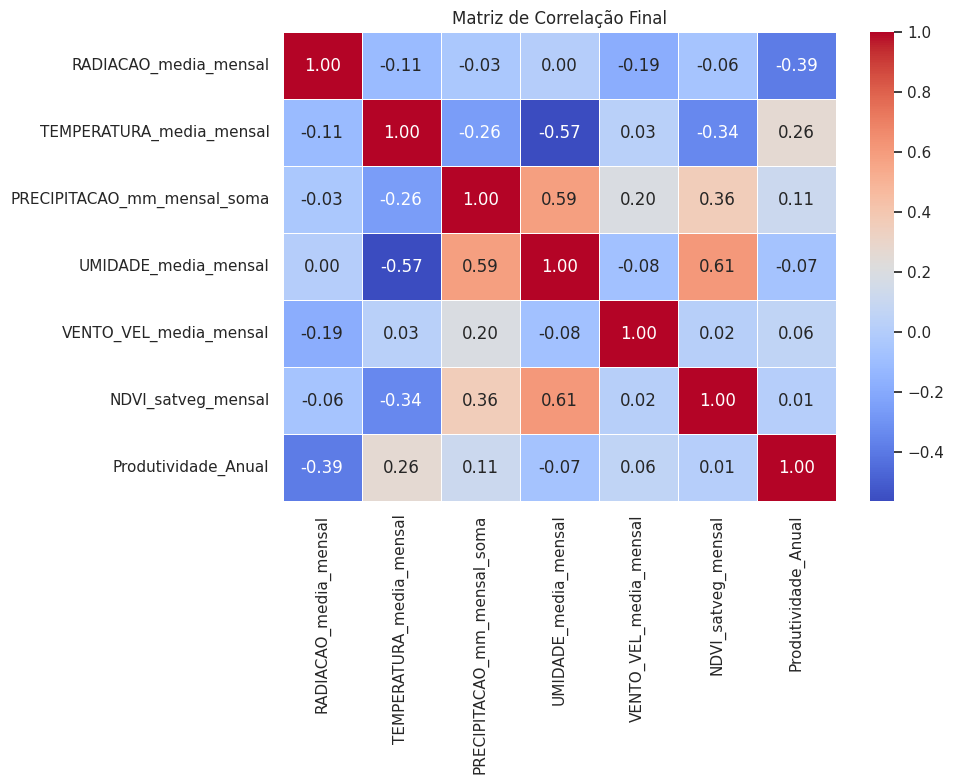

Produtividade_Anual            1.000000
TEMPERATURA_media_mensal       0.263549
PRECIPITACAO_mm_mensal_soma    0.114480
VENTO_VEL_media_mensal         0.061347
NDVI_satveg_mensal             0.009863
UMIDADE_media_mensal          -0.068961
RADIACAO_media_mensal         -0.390487
Name: Produtividade_Anual, dtype: float64

**Variáveis-Chave Sugeridas:**
  - Produtividade_Anual (Alvo)
  - NDVI_satveg_mensal (ou métrica agregada)
  - TEMPERATURA_media_mensal (ou métrica agregada)
  - RADIACAO_media_mensal (ou métrica agregada)
  - PRECIPITACAO_mm_mensal_soma (ou métrica agregada)
  - UMIDADE_media_mensal (ou métrica agregada)
  - VENTO_VEL_media_mensal (ou métrica agregada)
  - ANO (para tendências)

5.2. Relação NDVI-Produtividade e Períodos Críticos...


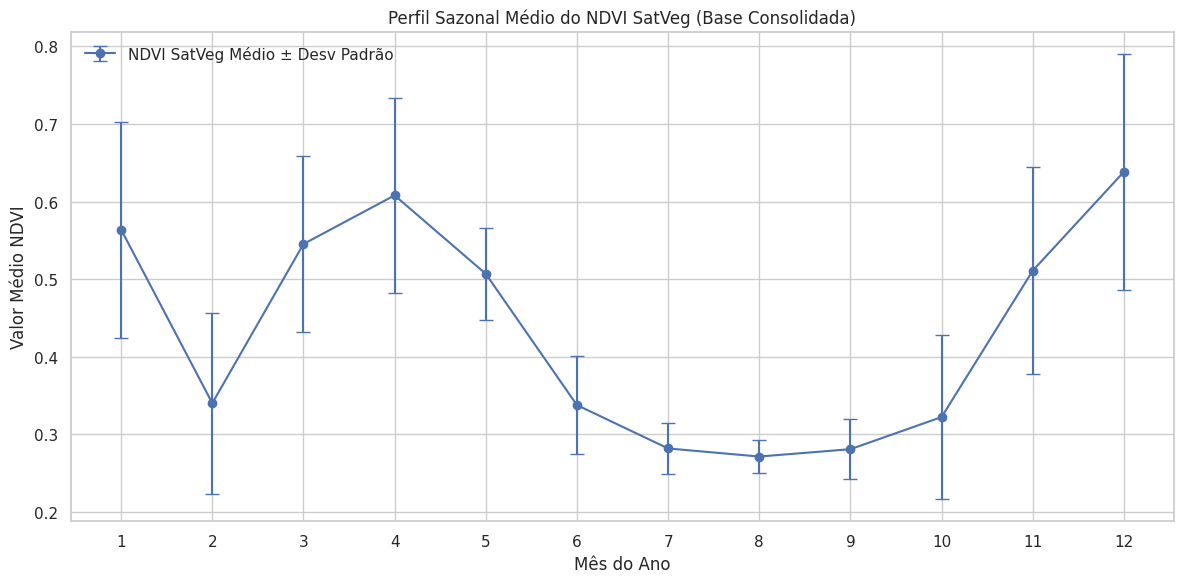

  - Pico médio do NDVI SatVeg ocorre no Mês: 12 (Valor médio: 0.638)
  - Meses próximos a este pico são considerados críticos.


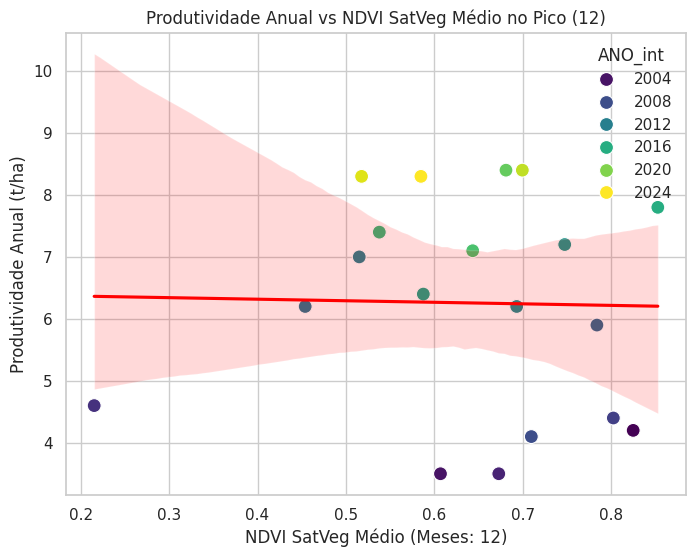


  -> Correlação entre Produtividade Anual e NDVI SatVeg Médio no Pico: -0.022

5.3. Segmentação (Identificação de Fases Fenológicas)...
  A 'segmentação' neste contexto refere-se à identificação das fases de crescimento:
    - Fase 1: Início/Emergência (NDVI subindo)
    - Fase 2: Pico Vegetativo (NDVI máximo)
    - Fase 3: Maturação/Senescência (NDVI caindo)
    - Fase 4: Entressafra/Repouso (NDVI baixo)
  -> Identifique visualmente no gráfico 'Perfil Sazonal Médio do NDVI SatVeg'.
  (Segmentação espacial de imagem não abordada aqui).

--- Fim da Análise da Base Consolidada Mensal ---


In [37]:
# Análise para definir variáveis-chave a serem utilizadas no modelo
print("\n--- Análise da Base Consolidada Mensal ---")

if 'df_consolidado_mensal' not in locals() or not isinstance(df_consolidado_mensal, pd.DataFrame) or df_consolidado_mensal.empty:
    print("[ERRO] DataFrame 'df_consolidado_mensal' não está disponível ou está vazio. Análise da Etapa 2 não pode continuar.")
else:
    print("[INFO] Iniciando análise com 'df_consolidado_mensal'.")
    # --- 5.1. Definir Variáveis-Chave ---
    print("\n5.1. Identificando Variáveis-Chave...")
    colunas_corr_prod = [
        'RADIACAO_media_mensal', 'TEMPERATURA_media_mensal', 'PRECIPITACAO_mm_mensal_soma',
        'UMIDADE_media_mensal', 'VENTO_VEL_media_mensal',
        'NDVI_satveg_mensal',
        'Produtividade_Anual'
    ]
    colunas_corr_existentes = [col for col in colunas_corr_prod if col in df_consolidado_mensal.columns]

    if len(colunas_corr_existentes) > 1:

        print(f"    Colunas consideradas para correlação: {colunas_corr_existentes}")
        print(f"    Shape ANTES do dropna para correlação: {df_consolidado_mensal[colunas_corr_existentes].shape}")
        df_corr = df_consolidado_mensal[colunas_corr_existentes].dropna()
        print(f"    Shape DEPOIS do dropna para correlação: {df_corr.shape}")
        if not df_corr.empty and len(df_corr) > 1:

             anos_corr = df_consolidado_mensal.loc[df_corr.index, 'ANO'].unique()
             print(f"    Anos restantes para correlação: Min={anos_corr.min()}, Max={anos_corr.max()}")
             matriz_corr_final = df_corr.corr()
             plt.figure(figsize=(10, 8)); sns.heatmap(matriz_corr_final, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
             plt.title('Matriz de Correlação Final'); plt.tight_layout(); plt.show()
             if 'Produtividade_Anual' in matriz_corr_final.columns: print(matriz_corr_final['Produtividade_Anual'].sort_values(ascending=False))
             else: print("  -> Coluna 'Produtividade_Anual' não encontrada na matriz.")
        else: print("[AVISO] Não há dados suficientes após remover NaNs para calcular a matriz de correlação.")
    else: print("[AVISO] Não há colunas suficientes ou válidas para calcular a matriz de correlação final.")

    print("\n**Variáveis-Chave Sugeridas:**")
    print("  - Produtividade_Anual (Alvo)")
    print("  - NDVI_satveg_mensal (ou métrica agregada)")
    print("  - TEMPERATURA_media_mensal (ou métrica agregada)")
    print("  - RADIACAO_media_mensal (ou métrica agregada)")
    print("  - PRECIPITACAO_mm_mensal_soma (ou métrica agregada)")
    print("  - UMIDADE_media_mensal (ou métrica agregada)")
    print("  - VENTO_VEL_media_mensal (ou métrica agregada)")
    print("  - ANO (para tendências)")


    # Relação NDVI-Produtividade e Períodos Críticos

    print("\n5.2. Relação NDVI-Produtividade e Períodos Críticos...")
    mes_pico = None
    try:
        ndvi_col_perfil = 'NDVI_satveg_mensal'
        if 'MES' in df_consolidado_mensal.columns and ndvi_col_perfil in df_consolidado_mensal.columns:
            df_perfil = df_consolidado_mensal.dropna(subset=['MES', ndvi_col_perfil], how='any')
            if not df_perfil.empty:
                 perfil_ndvi_medio_final = df_perfil.groupby('MES').agg(NDVI_medio=(ndvi_col_perfil, 'mean'), NDVI_std=(ndvi_col_perfil, 'std'))
                 if not perfil_ndvi_medio_final.empty:
                      plt.figure(figsize=(12, 6))
                      plt.errorbar(perfil_ndvi_medio_final.index, perfil_ndvi_medio_final['NDVI_medio'],
                                   yerr=perfil_ndvi_medio_final.get('NDVI_std'), label='NDVI SatVeg Médio ± Desv Padrão', fmt='-o', capsize=5)
                      plt.title('Perfil Sazonal Médio do NDVI SatVeg (Base Consolidada)')
                      plt.xlabel('Mês do Ano'); plt.ylabel('Valor Médio NDVI')
                      plt.xticks(range(1, 13)); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
                      if not perfil_ndvi_medio_final['NDVI_medio'].isnull().all():
                          mes_pico = perfil_ndvi_medio_final['NDVI_medio'].idxmax()
                          valor_pico = perfil_ndvi_medio_final['NDVI_medio'].max()
                          print(f"  - Pico médio do NDVI SatVeg ocorre no Mês: {mes_pico} (Valor médio: {valor_pico:.3f})")
                          print("  - Meses próximos a este pico são considerados críticos.")
                      else: print("  - Não foi possível calcular o pico do NDVI SatVeg.")
                 else: print("[AVISO] Não foi possível calcular o perfil NDVI SatVeg médio.")
            else: print("[AVISO] Não foi possível calcular o perfil NDVI SatVeg médio.")
        else: print("[AVISO] Não foi possível calcular o perfil NDVI SatVeg médio.")
    except Exception as e: print(f"[ERRO] Falha ao gerar gráfico de perfil sazonal: {e}")

    # Relação Produtividade vs NDVI SatVeg no pico
    if mes_pico is not None and 'Produtividade_Anual' in df_consolidado_mensal.columns and 'NDVI_satveg_mensal' in df_consolidado_mensal.columns:
        try:
            meses_pico = [mes_pico]
            df_anual_pico = df_consolidado_mensal[df_consolidado_mensal['MES'].isin(meses_pico)].groupby('ANO').agg(
                NDVI_pico_medio = ('NDVI_satveg_mensal', 'mean'),
                Produtividade_Anual = ('Produtividade_Anual', 'first')
            ).dropna()
            if not df_anual_pico.empty and len(df_anual_pico) > 1:
                df_anual_pico['ANO_int'] = df_anual_pico.index.astype(int)
                plt.figure(figsize=(8, 6))
                sns.scatterplot(data=df_anual_pico, x='NDVI_pico_medio', y='Produtividade_Anual', hue='ANO_int', palette='viridis', s=100)
                sns.regplot(data=df_anual_pico, x='NDVI_pico_medio', y='Produtividade_Anual', scatter=False, color='red')
                plt.title(f'Produtividade Anual vs NDVI SatVeg Médio no Pico ({",".join(map(str, meses_pico))})')
                plt.xlabel(f'NDVI SatVeg Médio (Meses: {",".join(map(str, meses_pico))})')
                plt.ylabel('Produtividade Anual (t/ha)')
                plt.grid(True); plt.show()
                if df_anual_pico['NDVI_pico_medio'].nunique() > 1 and df_anual_pico['Produtividade_Anual'].nunique() > 1:
                    correlacao_pico = df_anual_pico['NDVI_pico_medio'].corr(df_anual_pico['Produtividade_Anual'])
                    print(f"\n  -> Correlação entre Produtividade Anual e NDVI SatVeg Médio no Pico: {correlacao_pico:.3f}")
                else: print("\n  -> Não foi possível calcular a correlação.")
            else: print("[AVISO] Não foi possível gerar o gráfico Produtividade vs NDVI SatVeg no pico.")
        except Exception as e: print(f"[ERRO] Falha ao analisar relação Produtividade vs NDVI SatVeg no pico: {e}")
    elif mes_pico is None: print("[AVISO] Mês de pico não identificado.")
    else: print("[AVISO] Colunas necessárias não encontradas para análise Produtividade vs NDVI SatVeg.")

    # Segmentação (Identificação de Fases Fenológicas)

    print("\n5.3. Segmentação (Identificação de Fases Fenológicas)...")
    print("  A 'segmentação' neste contexto refere-se à identificação das fases de crescimento:")
    print("    - Fase 1: Início/Emergência (NDVI subindo)")
    print("    - Fase 2: Pico Vegetativo (NDVI máximo)")
    print("    - Fase 3: Maturação/Senescência (NDVI caindo)")
    print("    - Fase 4: Entressafra/Repouso (NDVI baixo)")
    print("  -> Identifique visualmente no gráfico 'Perfil Sazonal Médio do NDVI SatVeg'.")
    print("  (Segmentação espacial de imagem não abordada aqui).")

print("\n--- Fim da Análise da Base Consolidada Mensal ---")


In [ ]:
# Aplicar técnicas de segmentação para destacar áreas específicas de cultivo na imagem de satélite.

In [49]:
# Segmentação de Imagem

#  Montar Google Drive e definição de caminhos

print("--- Montar Google Drive e definição de caminhos ---")

import os
import glob
import shutil
import sys

# Tentar importar do Colab
try:
    from google.colab import drive
    IN_COLAB = True
    print("Executando no Google Colab. Montando Google Drive...")
    try:
        drive.mount('/content/drive', force_remount=False)
    except Exception as e_mount:
         print(f"  Falha na montagem inicial ({e_mount}). Tentando forçar remount...")
         drive.mount('/content/drive', force_remount=True)

    drive_image_folder = "/content/drive/MyDrive/EarthEngine_Exports_Mensal"
    if not os.path.isdir(drive_image_folder):
         print(f"[AVISO] Pasta '{drive_image_folder}' não encontrada no Google Drive.")
    else:
         print(f"Pasta de origem no Google Drive: {drive_image_folder}")

except ImportError:
    IN_COLAB = False
    drive_image_folder = "caminho/local/para/EarthEngine_Exports_Mensal"
    print(f"Executando localmente. Verifique 'drive_image_folder': {drive_image_folder}")
except Exception as e:
    print(f"[ERRO] Falha ao montar o Google Drive: {e}")
    drive_image_folder = None

# Definir pasta de destino local
pasta_destino_colab = 'dados_originais/imagens_satelite'
os.makedirs(pasta_destino_colab, exist_ok=True)
print(f"Pasta de destino local: '{pasta_destino_colab}'")

print("\n--- Fim acesso ao Google Drive e definição de caminhos ---")

--- Montar Google Drive e definição de caminhos ---
Executando no Google Colab. Montando Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Pasta de origem no Google Drive: /content/drive/MyDrive/EarthEngine_Exports_Mensal
Pasta de destino local: 'dados_originais/imagens_satelite'

--- Fim acesso ao Google Drive e definição de caminhos ---


In [50]:
# Listar e Copiar Imagens NDVI do Drive para o Colab

print("\n--- Listar e copiar imagens NDVI ---")

# Importar bibliotecas
import os
import glob
import shutil

caminhos_ndvi_local = []

# Só continua se a pasta de origem no Drive foi definida e existe
if 'drive_image_folder' in locals() and drive_image_folder and os.path.isdir(drive_image_folder):
    padrao_ndvi = "sorriso_ndvi_*.tif"
    caminho_busca_drive = os.path.join(drive_image_folder, padrao_ndvi)
    print(f"Procurando por arquivos com padrão '{padrao_ndvi}' em '{drive_image_folder}'...")

    arquivos_ndvi_drive = sorted(glob.glob(caminho_busca_drive))

    if not arquivos_ndvi_drive:
        print(f"[AVISO] Nenhum arquivo NDVI encontrado no Drive com o padrão '{padrao_ndvi}'.")
    else:
        print(f"Encontrados {len(arquivos_ndvi_drive)} arquivos NDVI no Google Drive:")
        for i, f_path in enumerate(arquivos_ndvi_drive):
             print(f"  [{i}] {os.path.basename(f_path)}")

        print("\nCopiando arquivos para a pasta local do Colab...")
        arquivos_copiados = []

        pasta_destino_colab = 'dados_originais/imagens_satelite'
        os.makedirs(pasta_destino_colab, exist_ok=True)

        for arquivo_drive in arquivos_ndvi_drive:
            nome_arquivo = os.path.basename(arquivo_drive)
            caminho_destino = os.path.join(pasta_destino_colab, nome_arquivo)
            try:
                shutil.copy2(arquivo_drive, caminho_destino)
                arquivos_copiados.append(caminho_destino)
            except Exception as e_copy:
                print(f"  [ERRO] Falha ao copiar {nome_arquivo}: {e_copy}")

        print(f"\nCópia concluída. {len(arquivos_copiados)} arquivos NDVI copiados para '{pasta_destino_colab}'.")
        caminhos_ndvi_local = arquivos_copiados
else:
     print("[ERRO] Pasta de origem no Google Drive não definida ou não encontrada. Verifique o Bloco 1.")

print("\n--- Fim de listar e copiar imagens NDVId ---")


--- Listar e copiar imagens NDVI ---
Procurando por arquivos com padrão 'sorriso_ndvi_*.tif' em '/content/drive/MyDrive/EarthEngine_Exports_Mensal'...
Encontrados 12 arquivos NDVI no Google Drive:
  [0] sorriso_ndvi_2023_10.tif
  [1] sorriso_ndvi_2023_11.tif
  [2] sorriso_ndvi_2023_12.tif
  [3] sorriso_ndvi_2024_01.tif
  [4] sorriso_ndvi_2024_02.tif
  [5] sorriso_ndvi_2024_04.tif
  [6] sorriso_ndvi_2024_05.tif
  [7] sorriso_ndvi_2024_06.tif
  [8] sorriso_ndvi_2024_07.tif
  [9] sorriso_ndvi_2024_08.tif
  [10] sorriso_ndvi_2024_09.tif
  [11] sorriso_ndvi_2024_10.tif

Copiando arquivos para a pasta local do Colab...

Cópia concluída. 12 arquivos NDVI copiados para 'dados_originais/imagens_satelite'.

--- Fim de listar e copiar imagens NDVId ---



--- Segmentação por Limiar Fixo de NDVI ---
Usando imagem selecionada (índice 6): sorriso_ndvi_2024_05.tif
  Aplicando limiar de NDVI > 0.4...
[OK] Máscara de segmentação por limiar criada.
  Gerando visualização...


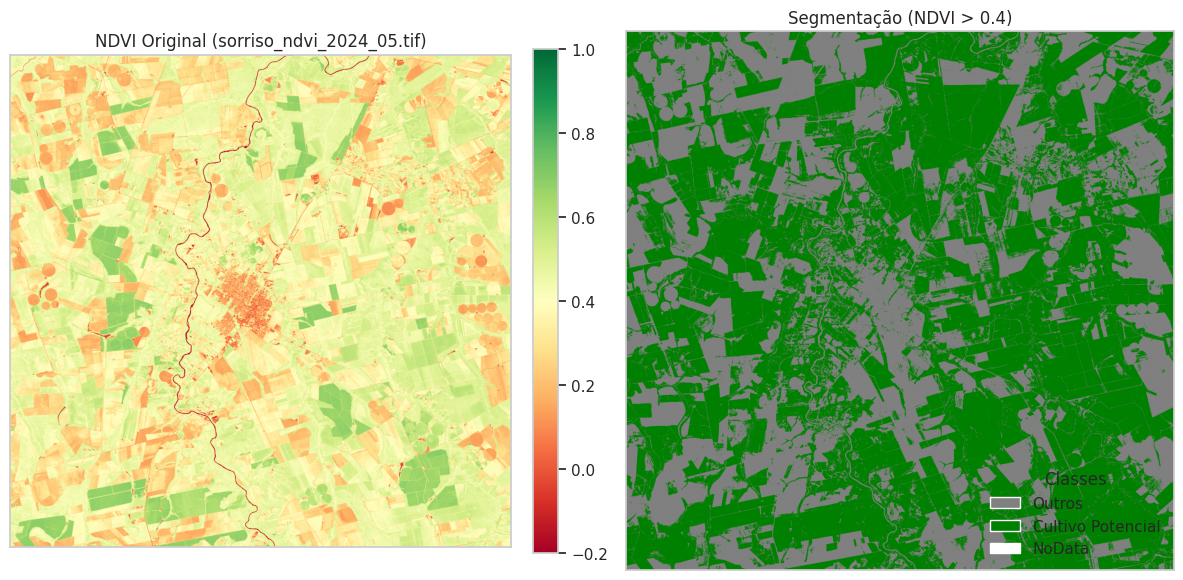

[OK] Imagem segmentada salva em: dados_processados/sorriso_ndvi_2024_05_segmentado_limiar0.4.tif

--- Fim da Segmentação por Limiar Fixo de NDVI ---


In [51]:
# Segmentação por Limiar Fixo de NDVI


print("\n--- Segmentação por Limiar Fixo de NDVI ---")

# Importar bibliotecas
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import os


indice_imagem_a_usar = 6 # opção p/ escolher a imagem

limiar_ndvi = 0.4 # Eopção p/ definir o limiar


# Verifica se a lista de arquivos locais existe e o índice é válido
if 'caminhos_ndvi_local' in locals() and caminhos_ndvi_local and 0 <= indice_imagem_a_usar < len(caminhos_ndvi_local):
    caminho_imagem_selecionada = caminhos_ndvi_local[indice_imagem_a_usar]
    print(f"Usando imagem selecionada (índice {indice_imagem_a_usar}): {os.path.basename(caminho_imagem_selecionada)}")
    pasta_dados_processados = 'dados_processados' # Garante que a pasta de saída exista
    os.makedirs(pasta_dados_processados, exist_ok=True)

    try:
        with rasterio.open(caminho_imagem_selecionada) as src:
            ndvi = src.read(1).astype(float)
            profile = src.profile
            nodata_val = src.nodata
            if nodata_val is not None: ndvi[ndvi == nodata_val] = np.nan

            print(f"  Aplicando limiar de NDVI > {limiar_ndvi}...")
            mascara_cultivo = np.where(ndvi > limiar_ndvi, 1, 0).astype(np.uint8)
            mascara_cultivo = np.where(np.isnan(ndvi), 255, mascara_cultivo).astype(np.uint8)
            print("[OK] Máscara de segmentação por limiar criada.")

            # Visualização
            print("  Gerando visualização...")
            fig, axes = plt.subplots(1, 2, figsize=(12, 6))
            cmap_ndvi = 'RdYlGn'; vmin_ndvi=-0.2; vmax_ndvi=1.0
            im1 = axes[0].imshow(ndvi, cmap=cmap_ndvi, vmin=vmin_ndvi, vmax=vmax_ndvi)
            axes[0].set_title(f'NDVI Original ({os.path.basename(caminho_imagem_selecionada)})'); axes[0].set_xticks([]); axes[0].set_yticks([])
            fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
            cmap_seg = plt.cm.colors.ListedColormap(['gray', 'green', 'white']); bounds = [-0.5, 0.5, 1.5, 256]; norm = plt.cm.colors.BoundaryNorm(bounds, cmap_seg.N)
            im2 = axes[1].imshow(mascara_cultivo, cmap=cmap_seg, norm=norm)
            axes[1].set_title(f'Segmentação (NDVI > {limiar_ndvi})'); axes[1].set_xticks([]); axes[1].set_yticks([])
            patches = [plt.Rectangle((0,0),1,1,fc=color) for color in ['gray', 'green', 'white']]
            axes[1].legend(patches, ['Outros', 'Cultivo Potencial', 'NoData'], loc='lower right', title="Classes")
            plt.tight_layout(); plt.show()

            # Salvar a Imagem Segmentada
            profile.update(dtype=rasterio.uint8, count=1, nodata=255)
            nome_arquivo_saida = os.path.basename(caminho_imagem_selecionada).replace('.tif', f'_segmentado_limiar{limiar_ndvi:.1f}.tif')
            caminho_saida_segmentado = os.path.join(pasta_dados_processados, nome_arquivo_saida)
            try:
                with rasterio.open(caminho_saida_segmentado, 'w', **profile) as dst: dst.write(mascara_cultivo, 1)
                print(f"[OK] Imagem segmentada salva em: {caminho_saida_segmentado}")
            except Exception as e_save: print(f"[ERRO] Falha ao salvar imagem segmentada: {e_save}")

    except rasterio.RasterioIOError: print(f"[ERRO] Não foi possível abrir a imagem: {caminho_imagem_selecionada}.")
    except IndexError: print(f"[ERRO] Índice de imagem {indice_imagem_a_usar} inválido.")
    except Exception as e: print(f"[ERRO] Falha inesperada: {e}")
else:
    print("[ERRO] Nenhum arquivo NDVI local encontrado ou índice inválido. Execute o Bloco 2 ou ajuste o índice.")

print("\n--- Fim da Segmentação por Limiar Fixo de NDVI ---")


--- Segmentação por Limiar Automático (Otsu) ---
Usando imagem selecionada (índice 6): sorriso_ndvi_2024_05.tif

  Calculando limiar automático (Otsu)...
    Limiar Otsu encontrado: 0.370
[OK] Máscara de segmentação Otsu criada.
  Gerando visualização...


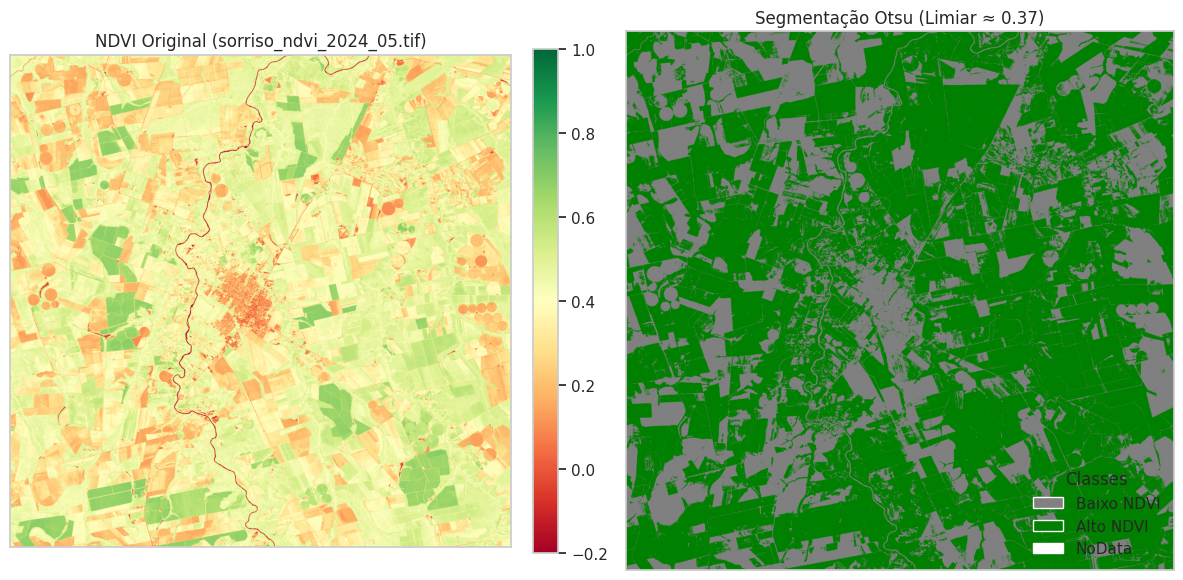

[OK] Imagem segmentada (Otsu) salva em: dados_processados/sorriso_ndvi_2024_05_segmentado_otsu.tif

--- Fim do Bloco 4 ---


In [52]:
#  Segmentação por Limiar Automático (Otsu)

print("\n--- Segmentação por Limiar Automático (Otsu) ---")

# Instalar/Importar bibliotecas necessárias
try:
    import rasterio
    import matplotlib.pyplot as plt
    import numpy as np
    from skimage.filters import threshold_otsu
except ImportError:
    print("Instalando bibliotecas necessárias (rasterio, scikit-image)...")
    try:
      get_ipython().run_line_magic('pip', 'install rasterio matplotlib numpy scikit-image -q')
      import rasterio
      import matplotlib.pyplot as plt
      import numpy as np
      from skimage.filters import threshold_otsu
      print("Bibliotecas instaladas.")
    except NameError:
       print("[ERRO] Falha ao instalar bibliotecas. Instale manualmente.")
       # sys.exit()


indice_imagem_a_usar_otsu = 6 # opção para escolher a imagem


# Verifica se a lista de arquivos locais existe e o índice é válido
if 'caminhos_ndvi_local' in locals() and caminhos_ndvi_local and 0 <= indice_imagem_a_usar_otsu < len(caminhos_ndvi_local):
    caminho_imagem_selecionada = caminhos_ndvi_local[indice_imagem_a_usar_otsu]
    print(f"Usando imagem selecionada (índice {indice_imagem_a_usar_otsu}): {os.path.basename(caminho_imagem_selecionada)}")
    pasta_dados_processados = 'dados_processados'
    os.makedirs(pasta_dados_processados, exist_ok=True)

    try:
        with rasterio.open(caminho_imagem_selecionada) as src:
            ndvi = src.read(1).astype(float)
            profile = src.profile
            nodata_val = src.nodata
            if nodata_val is not None: ndvi[ndvi == nodata_val] = np.nan

            print("\n  Calculando limiar automático (Otsu)...")
            ndvi_valid = ndvi[~np.isnan(ndvi)]
            if len(ndvi_valid) > 0:
                otsu_thresh = threshold_otsu(ndvi_valid)
                print(f"    Limiar Otsu encontrado: {otsu_thresh:.3f}")
                # Cria a máscara binária usando o limiar Otsu
                mascara_cultivo_otsu = np.where(ndvi > otsu_thresh, 1, 0).astype(np.uint8)
                mascara_cultivo_otsu = np.where(np.isnan(ndvi), 255, mascara_cultivo_otsu).astype(np.uint8)
                print("[OK] Máscara de segmentação Otsu criada.")

                # Visualização
                print("  Gerando visualização...")
                fig, axes = plt.subplots(1, 2, figsize=(12, 6))
                cmap_ndvi = 'RdYlGn'; vmin_ndvi=-0.2; vmax_ndvi=1.0
                im1 = axes[0].imshow(ndvi, cmap=cmap_ndvi, vmin=vmin_ndvi, vmax=vmax_ndvi)
                axes[0].set_title(f'NDVI Original ({os.path.basename(caminho_imagem_selecionada)})'); axes[0].set_xticks([]); axes[0].set_yticks([])
                fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

                cmap_seg = plt.cm.colors.ListedColormap(['gray', 'green', 'white']); bounds = [-0.5, 0.5, 1.5, 256]; norm = plt.cm.colors.BoundaryNorm(bounds, cmap_seg.N)
                im2 = axes[1].imshow(mascara_cultivo_otsu, cmap=cmap_seg, norm=norm) # Usa máscara Otsu
                axes[1].set_title(f'Segmentação Otsu (Limiar ≈ {otsu_thresh:.2f})'); axes[1].set_xticks([]); axes[1].set_yticks([])
                patches = [plt.Rectangle((0,0),1,1,fc=color) for color in ['gray', 'green', 'white']]
                axes[1].legend(patches, ['Baixo NDVI', 'Alto NDVI', 'NoData'], loc='lower right', title="Classes") # Legenda ajustada
                plt.tight_layout(); plt.show()

                # Salvar a Imagem Segmentada (Opcional)
                profile.update(dtype=rasterio.uint8, count=1, nodata=255)
                nome_arquivo_saida = os.path.basename(caminho_imagem_selecionada).replace('.tif', f'_segmentado_otsu.tif')
                caminho_saida_segmentado = os.path.join(pasta_dados_processados, nome_arquivo_saida)
                try:
                    with rasterio.open(caminho_saida_segmentado, 'w', **profile) as dst: dst.write(mascara_cultivo_otsu, 1)
                    print(f"[OK] Imagem segmentada (Otsu) salva em: {caminho_saida_segmentado}")
                except Exception as e_save: print(f"[ERRO] Falha ao salvar imagem segmentada (Otsu): {e_save}")
            else:
                print("    [AVISO] Não há dados válidos na imagem NDVI para calcular limiar Otsu.")

    except rasterio.RasterioIOError: print(f"[ERRO] Não foi possível abrir a imagem: {caminho_imagem_selecionada}.")
    except IndexError: print(f"[ERRO] Índice de imagem {indice_imagem_a_usar_otsu} inválido.")
    except Exception as e: print(f"[ERRO] Falha inesperada durante a segmentação Otsu: {e}")
else:
    print("[ERRO] Nenhum arquivo NDVI local encontrado ou índice inválido. Execute o Bloco 2 ou ajuste o índice.")

print("\n--- Fim da Segmentação por Limiar Automático (Otsu) ---")


In [54]:
# Exemplo de Segmentação Não Supervisionada (K-Means) no Google Earth Engine

import ee
# import ee.mapclient # Descomente se usar ee.mapclient
# import geemap # Descomente se usar geemap
import os
import time
import pandas as pd # Para manipulação de datas

# --- Configurações ---
try:
    # Tenta inicializar silenciosamente primeiro
    ee.Initialize(project="pipoca-452815", opt_url='https://earthengine-highvolume.googleapis.com', quiet=True) # <<< SEU PROJETO AQUI + High Volume Endpoint
    print("[OK] GEE inicializado no projeto 'pipoca-452815'.")
except Exception as e_proj:
    print(f"[AVISO] Não foi possível inicializar no projeto GEE especificado: {e_proj}.")
    # Se falhar no projeto específico, tenta inicializar sem projeto (usando padrão)
    try:
        print("   Tentando autenticação/inicialização padrão...")
        ee.Initialize(opt_url='https://earthengine-highvolume.googleapis.com', quiet=True)
        print("[OK] GEE inicializado (usando projeto padrão).")
    except Exception as e_init:
         print("   Autenticação padrão necessária...")
         ee.Authenticate()
         ee.Initialize(project="pipoca-452815", opt_url='https://earthengine-highvolume.googleapis.com') # Tenta com projeto após autenticar
         print("[OK] GEE inicializado após autenticação.")


# --- Parâmetros da Análise ---
# Área de Interesse (AOI): Use um polígono para abranger a área da fazenda/talhões
aoi = ee.Geometry.Rectangle([-56.0, -13.0, -55.5, -12.5]) # Exemplo: Retângulo sobre Sorriso
print(f"\nÁrea de Interesse (AOI) definida: Retângulo sobre Sorriso (Exemplo).")

# Período de Interesse para a Imagem a ser Segmentada
start_period = '2023-02-01'
end_period = '2023-03-31'
print(f"Período para imagem de segmentação: {start_period} a {end_period}")

# Coleção de Imagens
collection_id = 'COPERNICUS/S2_SR_HARMONIZED'
cloud_cover_max = 20
print(f"Coleção de imagens: {collection_id} (Nuvens < {cloud_cover_max}%)")

# Parâmetros da Segmentação
num_clusters = 5
bands_for_clustering = ['B4', 'B3', 'B2', 'B8', 'NDVI']
scale = 10
# <<< NOVO PARÂMETRO: Número de pixels para amostrar para o treinamento >>>
num_training_pixels = 5000 # Ajuste conforme necessário (mais pixels = treino mais preciso, porém mais lento)
print(f"Segmentação K-Means com {num_clusters} clusters, usando bandas: {bands_for_clustering}")
print(f"Número de pixels para treinamento: {num_training_pixels}")

# Parâmetros de Exportação
output_folder_drive = 'GEE_Segmentacao_Resultados'
output_filename_prefix = 'sorriso_segmentado_kmeans'
print(f"Resultado será exportado para a pasta '{output_folder_drive}' no Google Drive.")

# --- Processamento GEE ---

# 1. Filtrar coleção e criar composição livre de nuvens (Mediana)
print(f"\n[INFO] Filtrando coleção '{collection_id}'...")
image_collection = ee.ImageCollection(collection_id) \
    .filterBounds(aoi) \
    .filterDate(start_period, end_period) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', cloud_cover_max))

collection_size = image_collection.size().getInfo()
if collection_size == 0:
    print(f"[ERRO] Nenhuma imagem encontrada na coleção.")
    image_composite = None
else:
    print(f"[INFO] {collection_size} imagens encontradas. Calculando mediana...")
    image_composite = image_collection.median().clip(aoi)

# 2. Calcular NDVI
image_composite_ndvi = None
if image_composite is not None:
    print("[INFO] Calculando NDVI...")
    def calculate_ndvi_s2(image):
        required_bands = ee.List(['B8', 'B4'])
        has_bands = image.bandNames().containsAll(required_bands)
        return ee.Image(ee.Algorithms.If(
            has_bands,
            image.addBands(image.normalizedDifference(['B8', 'B4']).rename('NDVI')),
            image
        ))
    image_composite_ndvi = calculate_ndvi_s2(image_composite)
    if 'NDVI' not in image_composite_ndvi.bandNames().getInfo():
         print("[AVISO] Banda NDVI não pôde ser calculada.")
         if 'NDVI' in bands_for_clustering:
              print("[ERRO] Removendo NDVI das bandas de clusterização.")
              bands_for_clustering.remove('NDVI')

# 3. Preparar dados para Clusterização
image_for_clustering = None
if image_composite_ndvi is not None:
    bands_presentes = [b for b in bands_for_clustering if b in image_composite_ndvi.bandNames().getInfo()]
    if not bands_presentes:
         print("[ERRO] Nenhuma das bandas selecionadas existe.")
    else:
         if len(bands_presentes) < len(bands_for_clustering):
              print(f"[AVISO] Usando apenas as bandas presentes: {bands_presentes}")
         # Seleciona apenas as bandas presentes e preenche máscaras com 0
         image_for_clustering = image_composite_ndvi.select(bands_presentes).unmask(0)
         print(f"[INFO] Imagem para clusterização preparada com bandas: {bands_presentes}")

# 4. Amostrar Pontos para Treinamento ***
training_samples = None
if image_for_clustering is not None:
    print(f"[INFO] Amostrando {num_training_pixels} pixels da imagem para treinamento...")
    try:
        # Cria uma amostra aleatória de pixels dentro da AOI
        training_samples = image_for_clustering.sample(
            region=aoi,
            scale=scale,
            numPixels=num_training_pixels,
            seed=42, # Para reprodutibilidade da amostragem
            tileScale=4 # Aumenta tileScale para amostragens grandes
        )
        # Verifica se a amostragem retornou features
        if training_samples.size().getInfo() > 0:
             print("[OK] Amostragem concluída.")
        else:
             print("[ERRO] Amostragem não retornou nenhum ponto. Verifique a imagem e a AOI.")
             training_samples = None
    except Exception as e_sample:
        print(f"[ERRO] Falha durante a amostragem de pixels: {e_sample}")
        training_samples = None

# 5. Treinar o Clusterizador (K-Means) usando as Amostras
clusterer = None
if training_samples is not None: # Treina se a amostragem funcionou
    print(f"[INFO] Treinando clusterizador K-Means com {num_clusters} clusters...")
    try:
        # *** CORREÇÃO: Passa a FeatureCollection (amostras) para .train() ***
        clusterer = ee.Clusterer.wekaKMeans(num_clusters).train(
            features=training_samples,
            # inputProperties=bands_presentes # Especifica quais propriedades usar (opcional, mas bom)
        )
        print("[OK] Clusterizador treinado.")
    except Exception as e_train:
        print(f"[ERRO] Falha ao treinar o clusterizador: {e_train}")

# 6. Classificar a Imagem Completa
classified_image = None
if clusterer is not None and image_for_clustering is not None: # Classifica se treinou e tem imagem
    print("[INFO] Classificando a imagem completa...")
    try:
        # Aplica o clusterizador treinado à imagem preparada (com as bandas certas)
        classified_image = image_for_clustering.cluster(clusterer).rename('cluster')
        print(f"[OK] Imagem classificada em {num_clusters} clusters.")
    except Exception as e_classify:
        print(f"[ERRO] Falha ao classificar a imagem: {e_classify}")

# Exportar o Resultado
if classified_image is not None:
    print("\n--- Exportando Resultado para Google Drive ---")
    export_filename = f"{output_filename_prefix}_{num_clusters}clusters_{start_period}_to_{end_period}"

    # Montar o Google Drive se estiver no Colab
    if 'google.colab' in sys.modules: # Verifica se está no Colab de forma mais segura
        try:
            from google.colab import drive
            drive.mount('/content/drive', force_remount=True)
            print("Google Drive montado para exportação.")
        except Exception as e_mount:
            print(f"[ERRO] Não foi possível montar o Google Drive: {e_mount}")
            classified_image = None # Impede exportação

    if classified_image is not None:
        task = ee.batch.Export.image.toDrive(
            image=classified_image.byte(),
            description=export_filename,
            folder=output_folder_drive,
            fileNamePrefix=export_filename,
            region=aoi.getInfo()['coordinates'],
            scale=scale,
            crs='EPSG:4326',
            maxPixels=1e10
        )
        try:
            task.start()
            print(f"\n[EXPORTANDO] Tarefa '{export_filename}' iniciada.")
            print(f"  -> Verifique o progresso em: https://code.earthengine.google.com/tasks")
            print(f"  -> O arquivo GeoTIFF resultante será salvo na pasta '{output_folder_drive}' do seu Google Drive.")
        except Exception as e:
            print(f"[ERRO] Falha ao iniciar a exportação: {e}")
else:
    print("\n[INFO] Exportação não realizada (imagem não classificada).")

# --- Fim do Script GEE ---
print("\n--- Fim do Script de Segmentação K-Means GEE ---")



[AVISO] Não foi possível inicializar no projeto GEE especificado: Initialize() got an unexpected keyword argument 'quiet'.
   Tentando autenticação/inicialização padrão...
   Autenticação padrão necessária...
[OK] GEE inicializado após autenticação.

Área de Interesse (AOI) definida: Retângulo sobre Sorriso (Exemplo).
Período para imagem de segmentação: 2023-02-01 a 2023-03-31
Coleção de imagens: COPERNICUS/S2_SR_HARMONIZED (Nuvens < 20%)
Segmentação K-Means com 5 clusters, usando bandas: ['B4', 'B3', 'B2', 'B8', 'NDVI']
Número de pixels para treinamento: 5000
Resultado será exportado para a pasta 'GEE_Segmentacao_Resultados' no Google Drive.

[INFO] Filtrando coleção 'COPERNICUS/S2_SR_HARMONIZED'...
[INFO] 5 imagens encontradas. Calculando mediana...
[INFO] Calculando NDVI...
[INFO] Imagem para clusterização preparada com bandas: ['B4', 'B3', 'B2', 'B8', 'NDVI']
[INFO] Amostrando 5000 pixels da imagem para treinamento...
[OK] Amostragem concluída.
[INFO] Treinando clusterizador K-Mean

# Etapa 3 e 4 – Construção do Modelo de IA | Avaliação e Ajustes 🤖🔍 🔧

*   Selecionar um modelo de aprendizado de máquina ou redes neurais para previsão da produtividade.
*   Treinar o modelo utilizando os dados históricos e validar sua capacidade preditiva.
*   Ajustar hiperparâmetros e otimizar o desempenho do modelo.

*   Testar o modelo com diferentes períodos de dados, avaliando sua precisão e confiabilidade.
*   Ajustar a estratégia de modelagem com base nos resultados obtidos.
*   Gerar visualizações e métricas de desempenho para demonstrar os insights obtidos.











# 1º Modelo - Linear/Ridge

In [56]:
# Importar Bibliotecas
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import TimeSeriesSplit, LeaveOneOut
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import sys

print("--- Iniciando construção do modelo (Linear/Ridge, Dados 2003+) ---")

--- Iniciando Etapa 3: Construção do Modelo (Linear/Ridge, Dados 2003+) ---


In [57]:
#  Carregar Dados Consolidados Mensais
processed_folder = 'dados_processados'
consolidated_monthly_path = os.path.join(processed_folder, 'base_consolidada_mensal.csv')

df_mensal = None
X = None
y = None
features_cols = []

try:
    df_mensal = pd.read_csv(consolidated_monthly_path)
    print(f"[OK] Base consolidada mensal carregada de: {consolidated_monthly_path}")
    if 'ANO' in df_mensal.columns:
        df_mensal['ANO'] = pd.to_numeric(df_mensal['ANO'], errors='coerce').astype('Int64')
    else: raise ValueError("Coluna 'ANO' não encontrada.")
    if 'MES' in df_mensal.columns:
        df_mensal['MES'] = pd.to_numeric(df_mensal['MES'], errors='coerce').astype('Int64')
    else: raise ValueError("Coluna 'MES' não encontrada.")
    df_mensal.dropna(subset=['ANO', 'MES'], inplace=True)
    df_mensal = df_mensal.sort_values(by=['ANO', 'MES'])

    if not df_mensal.empty:
        print(f"     Intervalo de Anos Carregado: {df_mensal['ANO'].min()} - {df_mensal['ANO'].max()}")
    else:
        raise ValueError("DataFrame mensal vazio após carregamento/limpeza inicial.")

except FileNotFoundError:
    print(f"[ERRO] Arquivo '{consolidated_monthly_path}' não encontrado.")
    # sys.exit()
except ValueError as ve:
     print(f"[ERRO] Problema ao processar colunas ANO/MES: {ve}")
     # sys.exit()
except Exception as e:
    print(f"[ERRO] Falha ao carregar ou processar a base consolidada mensal: {e}")
    # sys.exit()

[OK] Base consolidada mensal carregada de: dados_processados/base_consolidada_mensal.csv
     Intervalo de Anos Carregado: 2003 - 2025


In [58]:
#  Engenharia de Atributos (Agregação Anual Simplificada)
print("\n--- Agregando Features Mensais Anualmente (Modo Simplificado) ---")
df_anual = None

if 'df_mensal' in locals() and isinstance(df_mensal, pd.DataFrame) and not df_mensal.empty:
    # Define as agregações ANUAIS simplificadas
    aggregations_anual_simplificada = {
        # Usar a MÉDIA ANUAL das médias mensais/somas
        'RADIACAO_media_mensal': ['mean'],
        'TEMPERATURA_media_mensal': ['mean'],
        'PRECIPITACAO_mm_mensal_soma': ['mean'], # Média das somas mensais = Precipitação média mensal no ano
        'UMIDADE_media_mensal': ['mean'],
        'VENTO_VEL_media_mensal': ['mean'],
        'NDVI_satveg_mensal': ['mean', 'max'], # Média e Máximo anual do NDVI SatVeg
        'Produtividade_Anual': ['first'] # Alvo
    }
    agg_funcs_existentes = {col: funcs for col, funcs in aggregations_anual_simplificada.items() if col in df_mensal.columns}

    if agg_funcs_existentes:
        try:
            df_anual = df_mensal.groupby('ANO', observed=False).agg(agg_funcs_existentes)
            df_anual.columns = ['_'.join(col).strip() for col in df_anual.columns.values]
            target_col_agg = 'Produtividade_Anual_first'
            if target_col_agg in df_anual.columns:
                df_anual = df_anual.rename(columns={target_col_agg: 'Produtividade_Anual'})
            else: raise ValueError("Coluna alvo não encontrada após agregação anual.")
            df_anual.dropna(subset=['Produtividade_Anual'], inplace=True)
            df_anual.dropna(axis=1, how='all', inplace=True)
            df_anual = df_anual.sort_index()

            if df_anual.empty: raise ValueError("DataFrame anual vazio após agregação/limpeza.")

            print("[OK] Agregação anual simplificada concluída.")
            print(f"     Dimensões da base anual: {df_anual.shape}")
            print("     Colunas disponíveis:", df_anual.columns.tolist())

        except Exception as e_agg:
             print(f"[ERRO] Falha durante a agregação anual simplificada: {e_agg}")
             df_anual = None
    else:
        print("[ERRO] Nenhuma coluna válida encontrada para realizar a agregação anual.")
        df_anual = None
else:
    print("[ERRO] DataFrame mensal ('df_mensal') não está definido ou vazio.")
    df_anual = None


--- Agregando Features Mensais Anualmente (Modo Simplificado) ---
[OK] Agregação anual simplificada concluída.
     Dimensões da base anual: (21, 8)
     Colunas disponíveis: ['RADIACAO_media_mensal_mean', 'TEMPERATURA_media_mensal_mean', 'PRECIPITACAO_mm_mensal_soma_mean', 'UMIDADE_media_mensal_mean', 'VENTO_VEL_media_mensal_mean', 'NDVI_satveg_mensal_mean', 'NDVI_satveg_mensal_max', 'Produtividade_Anual']


In [59]:
#  Seleção de Atributos (Features) e Alvo (Target)
print("\n--- Selecionando Features e Target ---")
if 'df_anual' in locals() and isinstance(df_anual, pd.DataFrame) and 'Produtividade_Anual' in df_anual.columns:
    target = 'Produtividade_Anual'
    y = df_anual[target]
    # Seleciona TODAS as colunas agregadas como features (exceto o alvo)
    features_cols = [col for col in df_anual.columns if col != target]
    # Adiciona ANO como feature explícita (se não for o índice)

    X = df_anual[features_cols] # Assume que ANO é o índice por enquanto

    # Preenchimento de NaNs nas features (com média)
    if X.isnull().any().any():
         print("  [AVISO] Preenchendo NaNs nas features com a média da coluna...")
         numeric_cols = X.select_dtypes(include=np.number).columns
         means = X[numeric_cols].mean()
         X.fillna(means, inplace=True)
         if X.isnull().any().any():
              cols_com_nan_final = X.columns[X.isnull().any()].tolist()
              print(f"  [ERRO] NaNs persistentes nas features após preenchimento: {cols_com_nan_final}.")
              X = None # Invalida

    if X is not None:
         print(f"[OK] Target: '{target}' ({len(y)} amostras)")
         print(f"[OK] Features: {len(features_cols)} colunas ({X.shape[0]} amostras)")
         print("     Nomes das Features:", features_cols)
else:
    print("[ERRO] DataFrame anual ('df_anual') ou coluna 'Produtividade_Anual' não disponíveis.")
    X, y = None, None


--- Selecionando Features e Target ---
[OK] Target: 'Produtividade_Anual' (21 amostras)
[OK] Features: 7 colunas (21 amostras)
     Nomes das Features: ['RADIACAO_media_mensal_mean', 'TEMPERATURA_media_mensal_mean', 'PRECIPITACAO_mm_mensal_soma_mean', 'UMIDADE_media_mensal_mean', 'VENTO_VEL_media_mensal_mean', 'NDVI_satveg_mensal_mean', 'NDVI_satveg_mensal_max']



--- Implementando Validação Cruzada Temporal (Modelos Lineares) ---
  Configurando TimeSeriesSplit com 4 divisões.

  --- Fold 1/4 ---
    Anos de Treino: [2003, 2004, 2005, 2006, 2007]
    Anos de Teste : [2008, 2009, 2010, 2011]
    Features escalonadas.
      LR - Métricas: R²=-6.7100, RMSE=2.3438, MAE=2.1763
    Melhor Alpha para Ridge (Fold 1): 10.00
      RidgeCV - Métricas: R²=-2.0516, RMSE=1.4745, MAE=1.2243

  --- Fold 2/4 ---
    Anos de Treino: [2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011]
    Anos de Teste : [2012, 2013, 2014, 2015]
    Features escalonadas.
      LR - Métricas: R²=-27.4592, RMSE=2.1996, MAE=1.8939
    Melhor Alpha para Ridge (Fold 2): 0.10
      RidgeCV - Métricas: R²=-20.8960, RMSE=1.9293, MAE=1.7075

  --- Fold 3/4 ---
    Anos de Treino: [2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015]
    Anos de Teste : [2016, 2017, 2018, 2019]
    Features escalonadas.
      LR - Métricas: R²=-65.4356, RMSE=3.9670, MAE=3.6659
 

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(


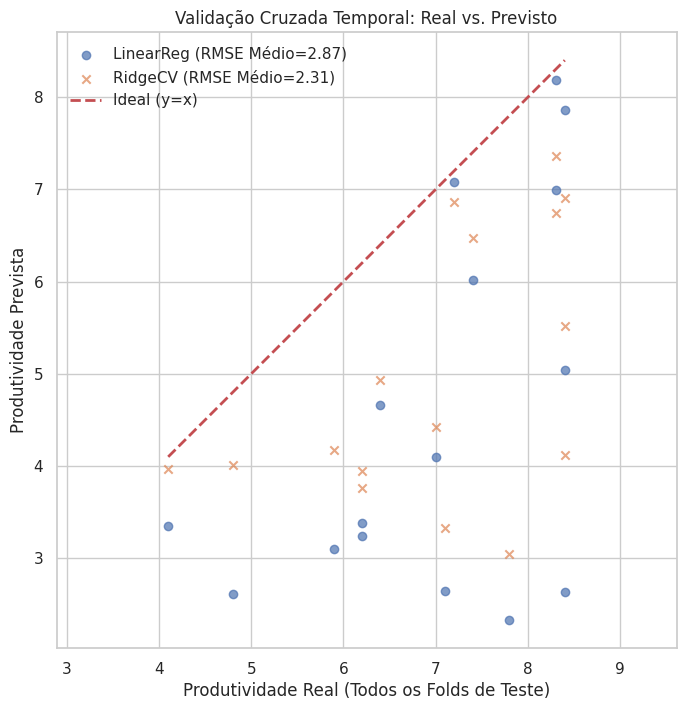

In [61]:
# Validação Cruzada Temporal com Modelos Lineares
print("\n--- Implementando Validação Cruzada Temporal (Modelos Lineares) ---")

if X is not None and y is not None and not X.empty and not y.empty:
    n_anos = len(X)
    n_splits_ts = min(4, n_anos - 1) if n_anos > 1 else 0

    if n_splits_ts >= 2:
        tscv = TimeSeriesSplit(n_splits=n_splits_ts)
        print(f"  Configurando TimeSeriesSplit com {n_splits_ts} divisões.")

        fold_metrics_lr = {'r2': [], 'rmse': [], 'mae': []}
        fold_metrics_ridge = {'r2': [], 'rmse': [], 'mae': []}
        fold_counter = 0

        # Listas para armazenar previsões de cada fold para análise posterior
        all_y_test_ts = []
        all_y_pred_lr = []
        all_y_pred_ridge = []

        for train_index, test_index in tscv.split(X):
            fold_counter += 1
            print(f"\n  --- Fold {fold_counter}/{n_splits_ts} ---")
            X_train_ts, X_test_ts = X.iloc[train_index], X.iloc[test_index]
            y_train_ts, y_test_ts = y.iloc[train_index], y.iloc[test_index]
            anos_treino = X_train_ts.index.tolist(); anos_teste = X_test_ts.index.tolist()
            print(f"    Anos de Treino: {anos_treino}")
            print(f"    Anos de Teste : {anos_teste}")

            try:
                # Escalonamento
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train_ts)
                X_test_scaled = scaler.transform(X_test_ts)
                print("    Features escalonadas.")

                # Regressão Linear
                lr_model = LinearRegression()
                lr_model.fit(X_train_scaled, y_train_ts)
                y_pred_lr = lr_model.predict(X_test_scaled)
                r2_lr = r2_score(y_test_ts, y_pred_lr) if len(y_test_ts) > 1 else np.nan # R2 só com >1 ponto
                rmse_lr = np.sqrt(mean_squared_error(y_test_ts, y_pred_lr))
                mae_lr = mean_absolute_error(y_test_ts, y_pred_lr)
                fold_metrics_lr['r2'].append(r2_lr); fold_metrics_lr['rmse'].append(rmse_lr); fold_metrics_lr['mae'].append(mae_lr)
                print(f"      LR - Métricas: R²={r2_lr:.4f}, RMSE={rmse_lr:.4f}, MAE={mae_lr:.4f}")

                # Regressão Ridge (com busca de alpha ótimo via RidgeCV)
                alphas_to_test = [0.01, 0.1, 1.0, 10.0, 100.0] # Valores de alpha para testar
                # RidgeCV usa validação cruzada interna para achar o melhor alpha
                ridge_cv_model = RidgeCV(alphas=alphas_to_test, store_cv_values=True)
                ridge_cv_model.fit(X_train_scaled, y_train_ts)
                best_alpha = ridge_cv_model.alpha_
                print(f"    Melhor Alpha para Ridge (Fold {fold_counter}): {best_alpha:.2f}")
                y_pred_ridge = ridge_cv_model.predict(X_test_scaled)
                r2_ridge = r2_score(y_test_ts, y_pred_ridge) if len(y_test_ts) > 1 else np.nan
                rmse_ridge = np.sqrt(mean_squared_error(y_test_ts, y_pred_ridge))
                mae_ridge = mean_absolute_error(y_test_ts, y_pred_ridge)
                fold_metrics_ridge['r2'].append(r2_ridge); fold_metrics_ridge['rmse'].append(rmse_ridge); fold_metrics_ridge['mae'].append(mae_ridge)
                print(f"      RidgeCV - Métricas: R²={r2_ridge:.4f}, RMSE={rmse_ridge:.4f}, MAE={mae_ridge:.4f}")

                # Armazenar resultados para plot final
                all_y_test_ts.extend(y_test_ts.tolist())
                all_y_pred_lr.extend(y_pred_lr.tolist())
                all_y_pred_ridge.extend(y_pred_ridge.tolist())

            except Exception as e_fold:
                print(f"    [ERRO] Falha ao treinar/avaliar o Fold {fold_counter}: {e_fold}")
                for metrics_dict in [fold_metrics_lr, fold_metrics_ridge]:
                    metrics_dict['r2'].append(np.nan); metrics_dict['rmse'].append(np.nan); metrics_dict['mae'].append(np.nan)

        # --- Resultados Consolidados da Validação Temporal ---
        print("\n  --- Resultados Consolidados da Validação Cruzada Temporal ---")
        print("\n    Modelo: Regressão Linear")
        if fold_metrics_lr['rmse']:
             print(f"      R² Médio    : {np.nanmean(fold_metrics_lr['r2']):.4f} ± {np.nanstd(fold_metrics_lr['r2']):.4f}")
             print(f"      RMSE Médio  : {np.nanmean(fold_metrics_lr['rmse']):.4f} ± {np.nanstd(fold_metrics_lr['rmse']):.4f}")
             print(f"      MAE Médio   : {np.nanmean(fold_metrics_lr['mae']):.4f} ± {np.nanstd(fold_metrics_lr['mae']):.4f}")
        else: print("      Nenhuma métrica válida calculada.")

        print("\n    Modelo: Regressão Ridge (com CV para Alpha)")
        if fold_metrics_ridge['rmse']:
             print(f"      R² Médio    : {np.nanmean(fold_metrics_ridge['r2']):.4f} ± {np.nanstd(fold_metrics_ridge['r2']):.4f}")
             print(f"      RMSE Médio  : {np.nanmean(fold_metrics_ridge['rmse']):.4f} ± {np.nanstd(fold_metrics_ridge['rmse']):.4f}")
             print(f"      MAE Médio   : {np.nanmean(fold_metrics_ridge['mae']):.4f} ± {np.nanstd(fold_metrics_ridge['mae']):.4f}")
        else: print("      Nenhuma métrica válida calculada.")

        # --- Plot Consolidado: Real vs Previsto (Todos os Folds) ---
        print("\n  --- Gráfico Consolidado: Real vs. Previsto (Todos os Folds) ---")
        if all_y_test_ts: # Verifica se há previsões para plotar
             plt.figure(figsize=(8, 8))
             plt.scatter(all_y_test_ts, all_y_pred_lr, alpha=0.7, label=f'LinearReg (RMSE Médio={np.nanmean(fold_metrics_lr["rmse"]):.2f})')
             plt.scatter(all_y_test_ts, all_y_pred_ridge, alpha=0.7, label=f'RidgeCV (RMSE Médio={np.nanmean(fold_metrics_ridge["rmse"]):.2f})', marker='x')
             # Linha ideal y=x
             min_val = min(all_y_test_ts); max_val = max(all_y_test_ts)
             plt.plot([min_val, max_val], [min_val, max_val], '--r', linewidth=2, label='Ideal (y=x)')
             plt.xlabel('Produtividade Real (Todos os Folds de Teste)')
             plt.ylabel('Produtividade Prevista')
             plt.title('Validação Cruzada Temporal: Real vs. Previsto')
             plt.legend()
             plt.grid(True)
             plt.axis('equal')
             plt.show()
        else:
             print("    Nenhuma previsão válida gerada para o gráfico consolidado.")

    # Mensagens caso não seja possível executar a validação cruzada
    elif n_anos <= 1: print(f"[AVISO] Número de anos ({n_anos}) insuficiente para TimeSeriesSplit.")
    else: print(f"[AVISO] Número de splits ({n_splits_ts}) inválido. Validação não executada.")
else:
    print("[ERRO] Dados anuais (X, y) não disponíveis para Validação Cruzada Temporal.")




In [68]:
# Treinar Modelo Final e Salvar

print("\n--- Treinamento do Modelo Final ---")
final_model = None
if X is not None and y is not None:
     try:
          print("  Treinando modelo RidgeCV final com todos os dados...")
          # Escalonar TODOS os dados X
          final_scaler = StandardScaler()
          X_scaled_final = final_scaler.fit_transform(X)
          # Treinar RidgeCV com todos os dados escalonados
          final_ridge_model = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0])
          final_ridge_model.fit(X_scaled_final, y)
          final_model = final_ridge_model # Guarda o modelo final
          print(f"  Modelo Ridge final treinado com alpha={final_model.alpha_:.2f}")

          # Salvar o modelo final e o scaler
          model_folder = os.path.join('resultados', 'modelos')
          os.makedirs(model_folder, exist_ok=True)
          model_path_final = os.path.join(model_folder, 'modelo_final_ridge.joblib')
          scaler_path_final = os.path.join(model_folder, 'scaler_final.joblib')
          joblib.dump(final_model, model_path_final)
          joblib.dump(final_scaler, scaler_path_final)
          print(f"  Modelo final salvo em: {model_path_final}")
          print(f"  Scaler final salvo em: {scaler_path_final}")

          # Exibir coeficientes do modelo final
          if hasattr(final_model, 'coef_') and hasattr(X, 'columns'):
               print("\n  Coeficientes do Modelo Ridge Final:")
               coefs = pd.Series(final_model.coef_, index=X.columns).sort_values(ascending=False)
               print(coefs)
               print("  -> Coeficientes indicam a relação (positiva/negativa) e a 'força'")
               print("     de cada feature na previsão, APÓS escalonamento.")

     except Exception as e_final:
          print(f"[ERRO] Falha ao treinar ou salvar o modelo final: {e_final}")
else:
     print("  Dados (X, y) não disponíveis para treinar modelo final.")


print("\n--- Fim da construção do modelo (Linear/Ridge, Dados 2003+)) ---")


--- Treinamento do Modelo Final ---
  Treinando modelo RidgeCV final com todos os dados...
  Modelo Ridge final treinado com alpha=10.00
[ERRO] Falha ao treinar ou salvar o modelo final: name 'joblib' is not defined

--- Fim da construção do modelo (Linear/Ridge, Dados 2003+)) ---


# 2º Modelo - Linear/Ridge (Features de Período Crítico)

In [64]:
# Importar Bibliotecas
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import TimeSeriesSplit, LeaveOneOut #  Validação Cruzada
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV # Modelos Lineares
from sklearn.preprocessing import StandardScaler # escalonar features
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import sys

print("--- Iniciando Etapa 3: Construção do modelo de RF (Features de Período Crítico) (Features de Período Crítico) ---")

--- Iniciando Etapa 3: Construção do modelo de RF (Features de Período Crítico) (Features de Período Crítico) ---


In [65]:
# Carregar Dados Consolidados Mensais
processed_folder = 'dados_processados'
consolidated_monthly_path = os.path.join(processed_folder, 'base_consolidada_mensal.csv')

df_mensal = None
X = None
y = None
features_cols = []

try:
    df_mensal = pd.read_csv(consolidated_monthly_path)
    print(f"[OK] Base consolidada mensal carregada de: {consolidated_monthly_path}")
    if 'ANO' in df_mensal.columns:
        df_mensal['ANO'] = pd.to_numeric(df_mensal['ANO'], errors='coerce').astype('Int64')
    else: raise ValueError("Coluna 'ANO' não encontrada.")
    if 'MES' in df_mensal.columns:
        df_mensal['MES'] = pd.to_numeric(df_mensal['MES'], errors='coerce').astype('Int64')
    else: raise ValueError("Coluna 'MES' não encontrada.")
    df_mensal.dropna(subset=['ANO', 'MES'], inplace=True)
    df_mensal = df_mensal.sort_values(by=['ANO', 'MES'])
    if not df_mensal.empty:
        print(f"     Intervalo de Anos Carregado: {df_mensal['ANO'].min()} - {df_mensal['ANO'].max()}")
    else: raise ValueError("DataFrame mensal vazio após carregamento/limpeza inicial.")
except FileNotFoundError:
    print(f"[ERRO CRÍTICO] Arquivo '{consolidated_monthly_path}' não encontrado.")
    # sys.exit()
except ValueError as ve:
     print(f"[ERRO CRÍTICO] Problema ao processar colunas ANO/MES: {ve}")
     # sys.exit()
except Exception as e:
    print(f"[ERRO CRÍTICO] Falha ao carregar ou processar a base consolidada mensal: {e}")
    # sys.exit()

[OK] Base consolidada mensal carregada de: dados_processados/base_consolidada_mensal.csv
     Intervalo de Anos Carregado: 2003 - 2025


In [66]:
# Engenharia de Atributos (Foco no Período Crítico)
print("\n--- Agregando Features do Período Crítico Anualmente ---")

# Baseado na análise anterior (pico NDVI SatVeg em Março),
# Optamos por usar Fev, Mar, Abr (2, 3, 4) como exemplo.
meses_criticos = [2, 3, 4]
print(f"  Meses definidos como críticos: {meses_criticos}")

df_anual_critico = None

# Verifica se o DataFrame mensal foi carregado
if 'df_mensal' in locals() and isinstance(df_mensal, pd.DataFrame) and not df_mensal.empty:
    # Filtra os dados mensais para incluir apenas os meses críticos
    df_periodo_critico = df_mensal[df_mensal['MES'].isin(meses_criticos)].copy()

    if not df_periodo_critico.empty:
        print(f"  Dados filtrados para os meses críticos. Linhas restantes: {len(df_periodo_critico)}")


        # Optamo por usar 'mean' para a maioria, 'sum' para precipitação, 'max' para NDVI
        aggregations_critico = {
            # Clima (média no período crítico)
            'RADIACAO_media_mensal': ['mean'],
            'TEMPERATURA_media_mensal': ['mean', 'max', 'min'], # Média, max e min da temperatura no período
            'PRECIPITACAO_mm_mensal_soma': ['sum'], # Soma da precipitação no período
            'UMIDADE_media_mensal': ['mean'], # Média da umidade no período
            'VENTO_VEL_media_mensal': ['mean'],   # Média do vento no período
            # NDVI SatVeg (média e máximo no período crítico)
            'NDVI_satveg_mensal': ['mean', 'max'],
            # Produtividade (Alvo) - Pega o primeiro valor do ano
            'Produtividade_Anual': ['first']
        }

        # Filtra o dicionário de agregações para incluir apenas colunas existentes
        agg_funcs_critico_existentes = {}
        for col, funcs in aggregations_critico.items():
            if col in df_periodo_critico.columns:
                agg_funcs_critico_existentes[col] = funcs
            else:
                print(f"    [AVISO] Coluna '{col}' não encontrada para agregação no período crítico.")

        # Realiza a agregação anual se houver funções definidas
        if agg_funcs_critico_existentes:
            try:
                # Agrega os dados filtrados por ANO
                df_anual_critico = df_periodo_critico.groupby('ANO', observed=False).agg(agg_funcs_critico_existentes)
                # Achata os nomes das colunas multi-nível, adicionando sufixo '_critico'
                df_anual_critico.columns = ['_'.join(col).strip() + '_critico' for col in df_anual_critico.columns.values]
                # Renomeia a coluna alvo
                target_col_agg = 'Produtividade_Anual_first_critico'
                if target_col_agg in df_anual_critico.columns:
                    df_anual_critico = df_anual_critico.rename(columns={target_col_agg: 'Produtividade_Anual'})
                else: raise ValueError("Coluna alvo não encontrada após agregação crítica.")

                # Remove anos onde a produtividade anual é NaN
                df_anual_critico.dropna(subset=['Produtividade_Anual'], inplace=True)
                # Remove colunas que são totalmente NaN após agregação
                df_anual_critico.dropna(axis=1, how='all', inplace=True)
                # Garante ordenação por ano (índice)
                df_anual_critico = df_anual_critico.sort_index()

                if df_anual_critico.empty: raise ValueError("DataFrame anual crítico vazio após agregação/limpeza.")

                print("[OK] Agregação anual focada no período crítico concluída.")
                print(f"     Dimensões da base anual crítica: {df_anual_critico.shape}")
                print("     Primeiras linhas da base anual crítica:")
                print(df_anual_critico.head())
                print("\n     Colunas disponíveis na base anual crítica:")
                print(df_anual_critico.columns.tolist())

            except Exception as e_agg:
                 print(f"[ERRO] Falha durante a agregação do período crítico: {e_agg}")
                 df_anual_critico = None
        else:
            print("[ERRO] Nenhuma coluna válida encontrada para realizar a agregação do período crítico.")
            df_anual_critico = None
    else:
        print("[ERRO] Nenhum dado encontrado para os meses críticos selecionados.")
        df_anual_critico = None
else:
    print("[ERRO] DataFrame mensal ('df_mensal') não está definido ou vazio.")
    df_anual_critico = None


--- Agregando Features do Período Crítico Anualmente ---
  Meses definidos como críticos: [2, 3, 4]
  Dados filtrados para os meses críticos. Linhas restantes: 59
[OK] Agregação anual focada no período crítico concluída.
     Dimensões da base anual crítica: (20, 10)
     Primeiras linhas da base anual crítica:
      RADIACAO_media_mensal_mean_critico  \
ANO                                        
2003                          377.927007   
2004                          345.544218   
2005                          379.481184   
2006                         4202.109250   
2007                         4705.780754   

      TEMPERATURA_media_mensal_mean_critico  \
ANO                                           
2003                              25.145036   
2004                              25.386365   
2005                              25.499078   
2006                              25.149445   
2007                              25.802780   

      TEMPERATURA_media_mensal_max_critico  \
A

In [67]:
# Seleção de Atributos (Features) e Alvo (Target)
print("\n--- Selecionando Features e Target (Período Crítico) ---")

X = None
y = None
features_cols = []

# Verifica se a base anual crítica foi criada
if 'df_anual_critico' in locals() and isinstance(df_anual_critico, pd.DataFrame) and 'Produtividade_Anual' in df_anual_critico.columns:
    target = 'Produtividade_Anual'
    y = df_anual_critico[target]
    # Seleciona todas as outras colunas (agregadas no período crítico) como features
    features_cols = [col for col in df_anual_critico.columns if col != target]
    X = df_anual_critico[features_cols]

    # Tratar NaNs restantes nas features (preenchendo com a média)
    if X.isnull().any().any():
         print("  [AVISO] Existem NaNs nas features críticas. Preenchendo com a média da coluna...")
         numeric_cols = X.select_dtypes(include=np.number).columns
         means = X[numeric_cols].mean()
         X.fillna(means, inplace=True)
         if X.isnull().any().any():
              cols_com_nan_final = X.columns[X.isnull().any()].tolist()
              print(f"  [ERRO] NaNs persistentes nas features críticas após preenchimento: {cols_com_nan_final}.")
              X = None # Invalida se ainda houver NaNs

    if X is not None:
         print(f"[OK] Target definido: '{target}' ({len(y)} amostras)")
         print(f"[OK] Features (Período Crítico) definidas: {len(features_cols)} colunas ({X.shape[0]} amostras)")
         print("     Nomes das Features:", features_cols)

else:
    print("[ERRO] DataFrame anual crítico ('df_anual_critico') ou coluna 'Produtividade_Anual' não disponíveis.")



--- Selecionando Features e Target (Período Crítico) ---
[OK] Target definido: 'Produtividade_Anual' (20 amostras)
[OK] Features (Período Crítico) definidas: 9 colunas (20 amostras)
     Nomes das Features: ['RADIACAO_media_mensal_mean_critico', 'TEMPERATURA_media_mensal_mean_critico', 'TEMPERATURA_media_mensal_max_critico', 'TEMPERATURA_media_mensal_min_critico', 'PRECIPITACAO_mm_mensal_soma_sum_critico', 'UMIDADE_media_mensal_mean_critico', 'VENTO_VEL_media_mensal_mean_critico', 'NDVI_satveg_mensal_mean_critico', 'NDVI_satveg_mensal_max_critico']


In [ ]:
#  Validação Cruzada Temporal com Modelos Lineares

print("\n--- Implementando Validação Cruzada Temporal (Modelos Lineares com Features Críticas) ---")

if X is not None and y is not None and not X.empty and not y.empty:
    n_anos = len(X)
    n_splits_ts = min(4, n_anos - 1) if n_anos > 1 else 0

    if n_splits_ts >= 2:
        tscv = TimeSeriesSplit(n_splits=n_splits_ts)
        print(f"  Configurando TimeSeriesSplit com {n_splits_ts} divisões.")

        fold_metrics_lr = {'r2': [], 'rmse': [], 'mae': []}
        fold_metrics_ridge = {'r2': [], 'rmse': [], 'mae': []}
        fold_counter = 0
        all_y_test_ts, all_y_pred_lr, all_y_pred_ridge = [], [], []

        for train_index, test_index in tscv.split(X):
            fold_counter += 1
            print(f"\n  --- Fold {fold_counter}/{n_splits_ts} ---")
            X_train_ts, X_test_ts = X.iloc[train_index], X.iloc[test_index]
            y_train_ts, y_test_ts = y.iloc[train_index], y.iloc[test_index]
            anos_treino = X_train_ts.index.tolist(); anos_teste = X_test_ts.index.tolist()
            print(f"    Anos de Treino: {anos_treino}")
            print(f"    Anos de Teste : {anos_teste}")

            try:
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train_ts)
                X_test_scaled = scaler.transform(X_test_ts)
                print("    Features escalonadas.")

                lr_model = LinearRegression()
                lr_model.fit(X_train_scaled, y_train_ts)
                y_pred_lr = lr_model.predict(X_test_scaled)
                r2_lr = r2_score(y_test_ts, y_pred_lr) if len(y_test_ts) > 1 else np.nan
                rmse_lr = np.sqrt(mean_squared_error(y_test_ts, y_pred_lr))
                mae_lr = mean_absolute_error(y_test_ts, y_pred_lr)
                fold_metrics_lr['r2'].append(r2_lr); fold_metrics_lr['rmse'].append(rmse_lr); fold_metrics_lr['mae'].append(mae_lr)
                print(f"      LR - Métricas: R²={r2_lr:.4f}, RMSE={rmse_lr:.4f}, MAE={mae_lr:.4f}")

                alphas_to_test = [0.01, 0.1, 1.0, 10.0, 100.0]
                ridge_cv_model = RidgeCV(alphas=alphas_to_test, store_cv_values=True)
                ridge_cv_model.fit(X_train_scaled, y_train_ts)
                best_alpha = ridge_cv_model.alpha_
                print(f"    Melhor Alpha para Ridge (Fold {fold_counter}): {best_alpha:.2f}")
                y_pred_ridge = ridge_cv_model.predict(X_test_scaled)
                r2_ridge = r2_score(y_test_ts, y_pred_ridge) if len(y_test_ts) > 1 else np.nan
                rmse_ridge = np.sqrt(mean_squared_error(y_test_ts, y_pred_ridge))
                mae_ridge = mean_absolute_error(y_test_ts, y_pred_ridge)
                fold_metrics_ridge['r2'].append(r2_ridge); fold_metrics_ridge['rmse'].append(rmse_ridge); fold_metrics_ridge['mae'].append(mae_ridge)
                print(f"      RidgeCV - Métricas: R²={r2_ridge:.4f}, RMSE={rmse_ridge:.4f}, MAE={mae_ridge:.4f}")

                all_y_test_ts.extend(y_test_ts.tolist())
                all_y_pred_lr.extend(y_pred_lr.tolist())
                all_y_pred_ridge.extend(y_pred_ridge.tolist())

            except Exception as e_fold:
                print(f"    [ERRO] Falha ao treinar/avaliar o Fold {fold_counter}: {e_fold}")
                for metrics_dict in [fold_metrics_lr, fold_metrics_ridge]:
                    metrics_dict['r2'].append(np.nan); metrics_dict['rmse'].append(np.nan); metrics_dict['mae'].append(np.nan)

        # --- Resultados Consolidados da Validação Temporal ---
        print("\n  --- Resultados Consolidados da Validação Cruzada Temporal (Features Críticas) ---")
        print("\n    Modelo: Regressão Linear")
        if fold_metrics_lr['rmse']:
             print(f"      R² Médio    : {np.nanmean(fold_metrics_lr['r2']):.4f} ± {np.nanstd(fold_metrics_lr['r2']):.4f}")
             print(f"      RMSE Médio  : {np.nanmean(fold_metrics_lr['rmse']):.4f} ± {np.nanstd(fold_metrics_lr['rmse']):.4f}")
             print(f"      MAE Médio   : {np.nanmean(fold_metrics_lr['mae']):.4f} ± {np.nanstd(fold_metrics_lr['mae']):.4f}")
        else: print("      Nenhuma métrica válida calculada.")

        print("\n    Modelo: Regressão Ridge (com CV para Alpha)")
        if fold_metrics_ridge['rmse']:
             print(f"      R² Médio    : {np.nanmean(fold_metrics_ridge['r2']):.4f} ± {np.nanstd(fold_metrics_ridge['r2']):.4f}")
             print(f"      RMSE Médio  : {np.nanmean(fold_metrics_ridge['rmse']):.4f} ± {np.nanstd(fold_metrics_ridge['rmse']):.4f}")
             print(f"      MAE Médio   : {np.nanmean(fold_metrics_ridge['mae']):.4f} ± {np.nanstd(fold_metrics_ridge['mae']):.4f}")
        else: print("      Nenhuma métrica válida calculada.")

        # --- Plot Consolidado: Real vs Previsto (Todos os Folds) ---
        print("\n  --- Gráfico Consolidado: Real vs. Previsto (Todos os Folds) ---")
        if all_y_test_ts:
             plt.figure(figsize=(8, 8))
             plt.scatter(all_y_test_ts, all_y_pred_lr, alpha=0.7, label=f'LinearReg (RMSE Médio={np.nanmean(fold_metrics_lr["rmse"]):.2f})')
             plt.scatter(all_y_test_ts, all_y_pred_ridge, alpha=0.7, label=f'RidgeCV (RMSE Médio={np.nanmean(fold_metrics_ridge["rmse"]):.2f})', marker='x')
             min_val = min(all_y_test_ts); max_val = max(all_y_test_ts)
             plt.plot([min_val, max_val], [min_val, max_val], '--r', linewidth=2, label='Ideal (y=x)')
             plt.xlabel('Produtividade Real (Todos os Folds de Teste)')
             plt.ylabel('Produtividade Prevista')
             plt.title('Validação Cruzada Temporal: Real vs. Previsto (Features Críticas)')
             plt.legend(); plt.grid(True); plt.axis('equal'); plt.show()
        else: print("    Nenhuma previsão válida gerada para o gráfico consolidado.")

    elif n_anos <= 1: print(f"[AVISO] Número de anos ({n_anos}) insuficiente para TimeSeriesSplit.")
    else: print(f"[AVISO] Número de splits ({n_splits_ts}) inválido. Validação não executada.")
else:
    print("[ERRO] Dados anuais (X, y) com features críticas não disponíveis para Validação.")

# Treinar Modelo Final e Salvar
# (Código de Treinamento Final e Salvamento permanece o mesmo, mas usará as features críticas)
print("\n--- Treinamento do Modelo Final ---")
final_model = None
if X is not None and y is not None:
     try:
          print("  Treinando modelo RidgeCV final com todos os dados (features críticas)...")
          final_scaler = StandardScaler()
          X_scaled_final = final_scaler.fit_transform(X)
          final_ridge_model = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0])
          final_ridge_model.fit(X_scaled_final, y)
          final_model = final_ridge_model
          print(f"  Modelo Ridge final treinado com alpha={final_model.alpha_:.2f}")

          model_folder = os.path.join('resultados', 'modelos')
          os.makedirs(model_folder, exist_ok=True)
          model_path_final = os.path.join(model_folder, 'modelo_final_ridge_critico.joblib') # Nome diferente
          scaler_path_final = os.path.join(model_folder, 'scaler_final_critico.joblib') # Nome diferente

          try: import joblib
          except ImportError: print("[ERRO] Biblioteca 'joblib' não instalada. Não foi possível salvar o modelo.")
          joblib.dump(final_model, model_path_final)
          joblib.dump(final_scaler, scaler_path_final)
          print(f"  Modelo final salvo em: {model_path_final}")
          print(f"  Scaler final salvo em: {scaler_path_final}")

          if hasattr(final_model, 'coef_') and hasattr(X, 'columns'):
               print("\n  Coeficientes do Modelo Ridge Final (Features Críticas):")
               coefs = pd.Series(final_model.coef_, index=X.columns).sort_values(ascending=False)
               print(coefs)

     except Exception as e_final:
          print(f"[ERRO] Falha ao treinar ou salvar o modelo final: {e_final}")
else:
     print("  Dados (X, y) não disponíveis para treinar modelo final.")

print("\n--- Fim da Etapa 3 (Refinada com Features Críticas) ---")


# 3º Modelo - Random Forest (Features de Período Crítico)

In [69]:
# Importar Bibliotecas
import pandas as pd
import numpy as np
import os
import joblib
from sklearn.model_selection import TimeSeriesSplit # validação cruzada temporal
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import sys

print("--- Iniciando Construção do Modelo (RandomForest com Features Críticas) ---")

--- Iniciando Construção do Modelo (RandomForest com Features Críticas) ---


In [70]:
# Carregar Dados Consolidados Mensais
processed_folder = 'dados_processados'
consolidated_monthly_path = os.path.join(processed_folder, 'base_consolidada_mensal.csv')

df_mensal = None
X = None
y = None
features_cols = []

try:
    df_mensal = pd.read_csv(consolidated_monthly_path)
    print(f"[OK] Base consolidada mensal carregada de: {consolidated_monthly_path}")
    if 'ANO' in df_mensal.columns:
        df_mensal['ANO'] = pd.to_numeric(df_mensal['ANO'], errors='coerce').astype('Int64')
    else: raise ValueError("Coluna 'ANO' não encontrada.")
    if 'MES' in df_mensal.columns:
        df_mensal['MES'] = pd.to_numeric(df_mensal['MES'], errors='coerce').astype('Int64')
    else: raise ValueError("Coluna 'MES' não encontrada.")
    df_mensal.dropna(subset=['ANO', 'MES'], inplace=True)
    df_mensal = df_mensal.sort_values(by=['ANO', 'MES'])
    if not df_mensal.empty:
        print(f"     Intervalo de Anos Carregado: {df_mensal['ANO'].min()} - {df_mensal['ANO'].max()}")
    else: raise ValueError("DataFrame mensal vazio após carregamento/limpeza inicial.")
except FileNotFoundError:
    print(f"[ERRO CRÍTICO] Arquivo '{consolidated_monthly_path}' não encontrado.")
    # sys.exit()
except ValueError as ve:
     print(f"[ERRO CRÍTICO] Problema ao processar colunas ANO/MES: {ve}")
     # sys.exit()
except Exception as e:
    print(f"[ERRO CRÍTICO] Falha ao carregar ou processar a base consolidada mensal: {e}")
    # sys.exit()

[OK] Base consolidada mensal carregada de: dados_processados/base_consolidada_mensal.csv
     Intervalo de Anos Carregado: 2003 - 2025


In [71]:
# Engenharia de Atributos (Foco no Período Crítico)
print("\n--- Agregando Features do Período Crítico Anualmente ---")


meses_criticos = [2, 3, 4] # opção p/ definir meses criticos, aqui usamos Fev, Mar, Abr
print(f"  Meses definidos como críticos: {meses_criticos}")

df_anual_critico = None

if 'df_mensal' in locals() and isinstance(df_mensal, pd.DataFrame) and not df_mensal.empty:
    df_periodo_critico = df_mensal[df_mensal['MES'].isin(meses_criticos)].copy()

    if not df_periodo_critico.empty:
        print(f"  Dados filtrados para os meses críticos. Linhas restantes: {len(df_periodo_critico)}")
        aggregations_critico = {
            'RADIACAO_media_mensal': ['mean'],
            'TEMPERATURA_media_mensal': ['mean', 'max', 'min'],
            'PRECIPITACAO_mm_mensal_soma': ['sum'],
            'UMIDADE_media_mensal': ['mean'],
            'VENTO_VEL_media_mensal': ['mean'],
            'NDVI_satveg_mensal': ['mean', 'max'],
            'Produtividade_Anual': ['first']
        }
        agg_funcs_critico_existentes = {col: funcs for col, funcs in aggregations_critico.items() if col in df_periodo_critico.columns}

        if agg_funcs_critico_existentes:
            try:
                df_anual_critico = df_periodo_critico.groupby('ANO', observed=False).agg(agg_funcs_critico_existentes)
                df_anual_critico.columns = ['_'.join(col).strip() + '_critico' for col in df_anual_critico.columns.values]
                target_col_agg = 'Produtividade_Anual_first_critico'
                if target_col_agg in df_anual_critico.columns:
                    df_anual_critico = df_anual_critico.rename(columns={target_col_agg: 'Produtividade_Anual'})
                else: raise ValueError("Coluna alvo não encontrada após agregação crítica.")
                df_anual_critico.dropna(subset=['Produtividade_Anual'], inplace=True)
                df_anual_critico.dropna(axis=1, how='all', inplace=True)
                df_anual_critico = df_anual_critico.sort_index()
                if df_anual_critico.empty: raise ValueError("DataFrame anual crítico vazio após agregação/limpeza.")
                print("[OK] Agregação anual focada no período crítico concluída.")
                print(f"     Dimensões da base anual crítica: {df_anual_critico.shape}")
                # print("     Primeiras linhas da base anual crítica:") # Comentado para brevidade
                # print(df_anual_critico.head())
                print("\n     Colunas disponíveis na base anual crítica:")
                print(df_anual_critico.columns.tolist())
            except Exception as e_agg: print(f"[ERRO] Falha durante a agregação: {e_agg}"); df_anual_critico = None
        else: print("[ERRO] Nenhuma coluna válida para agregação."); df_anual_critico = None
    else: print("[ERRO] Nenhum dado encontrado para os meses críticos."); df_anual_critico = None
else: print("[ERRO] DataFrame mensal não definido ou vazio."); df_anual_critico = None


--- Agregando Features do Período Crítico Anualmente ---
  Meses definidos como críticos: [2, 3, 4]
  Dados filtrados para os meses críticos. Linhas restantes: 59
[OK] Agregação anual focada no período crítico concluída.
     Dimensões da base anual crítica: (20, 10)

     Colunas disponíveis na base anual crítica:
['RADIACAO_media_mensal_mean_critico', 'TEMPERATURA_media_mensal_mean_critico', 'TEMPERATURA_media_mensal_max_critico', 'TEMPERATURA_media_mensal_min_critico', 'PRECIPITACAO_mm_mensal_soma_sum_critico', 'UMIDADE_media_mensal_mean_critico', 'VENTO_VEL_media_mensal_mean_critico', 'NDVI_satveg_mensal_mean_critico', 'NDVI_satveg_mensal_max_critico', 'Produtividade_Anual']


In [72]:
# Seleção de Atributos (Features) e Alvo (Target)
print("\n--- Selecionando Features e Target (Período Crítico) ---")
X = None; y = None; features_cols = []
if 'df_anual_critico' in locals() and isinstance(df_anual_critico, pd.DataFrame) and 'Produtividade_Anual' in df_anual_critico.columns:
    target = 'Produtividade_Anual'
    y = df_anual_critico[target]
    features_cols = [col for col in df_anual_critico.columns if col != target]
    X = df_anual_critico[features_cols]
    if X.isnull().any().any():
         print("  [AVISO] Preenchendo NaNs nas features críticas com a média...");
         numeric_cols = X.select_dtypes(include=np.number).columns
         means = X[numeric_cols].mean()
         X.fillna(means, inplace=True)
         if X.isnull().any().any(): print(f"  [ERRO] NaNs persistentes: {X.columns[X.isnull().any()].tolist()}."); X = None
    if X is not None: print(f"[OK] Target: '{target}' ({len(y)} amostras). Features: {len(features_cols)} ({X.shape[0]} amostras)."); print("     Features:", features_cols)
else: print("[ERRO] DataFrame anual crítico ou Target não disponíveis.")



--- Selecionando Features e Target (Período Crítico) ---
[OK] Target: 'Produtividade_Anual' (20 amostras). Features: 9 (20 amostras).
     Features: ['RADIACAO_media_mensal_mean_critico', 'TEMPERATURA_media_mensal_mean_critico', 'TEMPERATURA_media_mensal_max_critico', 'TEMPERATURA_media_mensal_min_critico', 'PRECIPITACAO_mm_mensal_soma_sum_critico', 'UMIDADE_media_mensal_mean_critico', 'VENTO_VEL_media_mensal_mean_critico', 'NDVI_satveg_mensal_mean_critico', 'NDVI_satveg_mensal_max_critico']



--- Implementando Validação Cruzada Temporal (RandomForest com Features Críticas) ---
  Configurando TimeSeriesSplit com 4 divisões.

  --- Fold 1/4 ---
    Anos de Treino: [2003, 2004, 2005, 2006]
    Anos de Teste : [2007, 2008, 2009, 2010]
    Treinando RandomForestRegressor (parâmetros padrão)...
      RF - Métricas: R²=-1.9794, RMSE=1.1770, MAE=0.9413

  --- Fold 2/4 ---
    Anos de Treino: [2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010]
    Anos de Teste : [2011, 2012, 2013, 2014]
    Treinando RandomForestRegressor (parâmetros padrão)...
      RF - Métricas: R²=-34.2364, RMSE=2.7040, MAE=2.6622

  --- Fold 3/4 ---
    Anos de Treino: [2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014]
    Anos de Teste : [2015, 2016, 2017, 2018]
    Treinando RandomForestRegressor (parâmetros padrão)...
      RF - Métricas: R²=-11.4108, RMSE=1.8028, MAE=1.6355

  --- Fold 4/4 ---
    Anos de Treino: [2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2

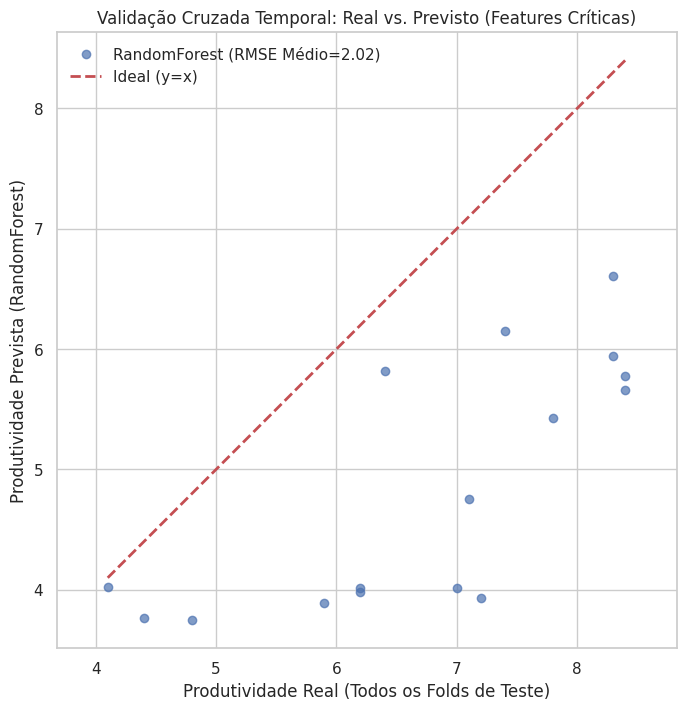


  --- Importância Média das Features (RandomForest - Todos os Folds) ---
                                   Feature  Importance
0       RADIACAO_media_mensal_mean_critico    0.227121
8           NDVI_satveg_mensal_max_critico    0.211355
1    TEMPERATURA_media_mensal_mean_critico    0.102206
5        UMIDADE_media_mensal_mean_critico    0.098971
3     TEMPERATURA_media_mensal_min_critico    0.098023
2     TEMPERATURA_media_mensal_max_critico    0.095173
4  PRECIPITACAO_mm_mensal_soma_sum_critico    0.070469
6      VENTO_VEL_media_mensal_mean_critico    0.056589
7          NDVI_satveg_mensal_mean_critico    0.040093


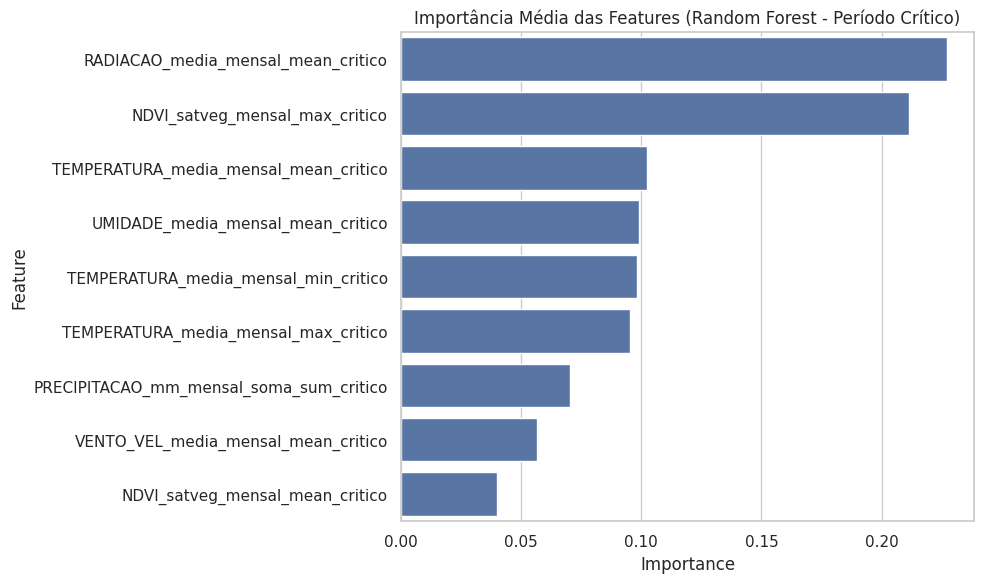

In [74]:
#  Validação Cruzada Temporal com RandomForestRegressor
print("\n--- Implementando Validação Cruzada Temporal (RandomForest com Features Críticas) ---")

if X is not None and y is not None and not X.empty and not y.empty:
    n_anos = len(X)
    n_splits_ts = min(4, n_anos - 1) if n_anos > 1 else 0

    if n_splits_ts >= 2:
        tscv = TimeSeriesSplit(n_splits=n_splits_ts)
        print(f"  Configurando TimeSeriesSplit com {n_splits_ts} divisões.")

        fold_metrics_rf = {'r2': [], 'rmse': [], 'mae': []} # Métricas para RandomForest
        fold_counter = 0
        all_y_test_ts = []
        all_y_pred_rf = []
        feature_importances_list = [] # Para armazenar importâncias de cada fold

        for train_index, test_index in tscv.split(X):
            fold_counter += 1
            print(f"\n  --- Fold {fold_counter}/{n_splits_ts} ---")
            X_train_ts, X_test_ts = X.iloc[train_index], X.iloc[test_index]
            y_train_ts, y_test_ts = y.iloc[train_index], y.iloc[test_index]
            anos_treino = X_train_ts.index.tolist(); anos_teste = X_test_ts.index.tolist()
            print(f"    Anos de Treino: {anos_treino}")
            print(f"    Anos de Teste : {anos_teste}")

            try:
                # --- Modelo: RandomForestRegressor ---
                print("    Treinando RandomForestRegressor (parâmetros padrão)...")
                # Usar random_state para reprodutibilidade
                rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)
                rf_model.fit(X_train_ts, y_train_ts) # Treina com dados não escalonados
                y_pred_rf = rf_model.predict(X_test_ts)

                # Calcular e armazenar métricas RF
                r2_rf = r2_score(y_test_ts, y_pred_rf) if len(y_test_ts) > 1 else np.nan
                rmse_rf = np.sqrt(mean_squared_error(y_test_ts, y_pred_rf))
                mae_rf = mean_absolute_error(y_test_ts, y_pred_rf)
                fold_metrics_rf['r2'].append(r2_rf); fold_metrics_rf['rmse'].append(rmse_rf); fold_metrics_rf['mae'].append(mae_rf)
                print(f"      RF - Métricas: R²={r2_rf:.4f}, RMSE={rmse_rf:.4f}, MAE={mae_rf:.4f}")

                # Armazenar importâncias das features deste fold
                if hasattr(rf_model, 'feature_importances_'):
                     feature_importances_list.append(rf_model.feature_importances_)

                # Armazenar resultados para plot final
                all_y_test_ts.extend(y_test_ts.tolist())
                all_y_pred_rf.extend(y_pred_rf.tolist())

            except Exception as e_fold:
                print(f"    [ERRO] Falha ao treinar/avaliar o Fold {fold_counter}: {e_fold}")
                fold_metrics_rf['r2'].append(np.nan); fold_metrics_rf['rmse'].append(np.nan); fold_metrics_rf['mae'].append(np.nan)

        # --- Resultados Consolidados da Validação Temporal ---
        print("\n  --- Resultados Consolidados da Validação Cruzada Temporal (RandomForest) ---")
        if fold_metrics_rf['rmse']:
             print(f"    R² Médio    : {np.nanmean(fold_metrics_rf['r2']):.4f} ± {np.nanstd(fold_metrics_rf['r2']):.4f}")
             print(f"    RMSE Médio  : {np.nanmean(fold_metrics_rf['rmse']):.4f} ± {np.nanstd(fold_metrics_rf['rmse']):.4f}")
             print(f"    MAE Médio   : {np.nanmean(fold_metrics_rf['mae']):.4f} ± {np.nanstd(fold_metrics_rf['mae']):.4f}")
        else: print("      Nenhuma métrica válida calculada.")

        # --- Plot Consolidado: Real vs Previsto (Todos os Folds) ---
        print("\n  --- Gráfico Consolidado: Real vs. Previsto (RandomForest - Todos os Folds) ---")
        if all_y_test_ts:
             plt.figure(figsize=(8, 8))
             plt.scatter(all_y_test_ts, all_y_pred_rf, alpha=0.7, label=f'RandomForest (RMSE Médio={np.nanmean(fold_metrics_rf["rmse"]):.2f})')
             min_val = min(all_y_test_ts); max_val = max(all_y_test_ts)
             plt.plot([min_val, max_val], [min_val, max_val], '--r', linewidth=2, label='Ideal (y=x)')
             plt.xlabel('Produtividade Real (Todos os Folds de Teste)')
             plt.ylabel('Produtividade Prevista (RandomForest)')
             plt.title('Validação Cruzada Temporal: Real vs. Previsto (Features Críticas)')
             plt.legend(); plt.grid(True); plt.axis('equal'); plt.show()
        else: print("    Nenhuma previsão válida gerada para o gráfico consolidado.")

        # --- Análise de Importância Média das Features ---
        if feature_importances_list and features_cols:
             print("\n  --- Importância Média das Features (RandomForest - Todos os Folds) ---")
             mean_importances = np.mean(feature_importances_list, axis=0)
             feature_importance_df = pd.DataFrame({'Feature': features_cols, 'Importance': mean_importances})
             feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
             print(feature_importance_df)

             plt.figure(figsize=(10, max(6, len(feature_importance_df) * 0.3)))
             sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
             plt.title('Importância Média das Features (Random Forest - Período Crítico)')
             plt.tight_layout()
             plt.show()

    elif n_anos <= 1: print(f"[AVISO] Número de anos ({n_anos}) insuficiente para TimeSeriesSplit.")
    else: print(f"[AVISO] Número de splits ({n_splits_ts}) inválido. Validação não executada.")
else:
    print("[ERRO] Dados anuais (X, y) com features críticas não disponíveis para Validação.")

In [73]:
# Treinar Modelo Final e Salvar
print("\n--- Treinamento do Modelo Final RandomForest (Opcional) ---")
final_model_rf = None
if X is not None and y is not None:
     try:
          print("  Treinando modelo RandomForest final com todos os dados (features críticas)...")

          final_model_rf = RandomForestRegressor(random_state=42, n_jobs=-1)
          final_model_rf.fit(X, y) # Treina com todos os dados
          print(f"  Modelo RandomForest final treinado.")

          # Salvar o modelo final
          model_folder = os.path.join('resultados', 'modelos')
          os.makedirs(model_folder, exist_ok=True)
          model_path_final_rf = os.path.join(model_folder, 'modelo_final_rf_critico.joblib')
          joblib.dump(final_model_rf, model_path_final_rf)
          print(f"  Modelo final RandomForest salvo em: {model_path_final_rf}")

          # Exibir importância das features do modelo final
          if hasattr(final_model_rf, 'feature_importances_') and hasattr(X, 'columns'):
               print("\n  Importância das Features (Modelo Final RandomForest):")
               importances_final = final_model_rf.feature_importances_
               feature_names_final = X.columns
               feature_importance_df_final = pd.DataFrame({'Feature': feature_names_final, 'Importance': importances_final})
               feature_importance_df_final = feature_importance_df_final.sort_values(by='Importance', ascending=False)
               print(feature_importance_df_final)

     except Exception as e_final:
          print(f"[ERRO] Falha ao treinar ou salvar o modelo final RandomForest: {e_final}")
else:
     print("  Dados (X, y) não disponíveis para treinar modelo final.")


print("\n--- Fim da Etapa 3 (RandomForest com Features Críticas) ---")



--- Treinamento do Modelo Final RandomForest (Opcional) ---
  Treinando modelo RandomForest final com todos os dados (features críticas)...
  Modelo RandomForest final treinado.
  Modelo final RandomForest salvo em: resultados/modelos/modelo_final_rf_critico.joblib

  Importância das Features (Modelo Final RandomForest):
                                   Feature  Importance
0       RADIACAO_media_mensal_mean_critico    0.364641
5        UMIDADE_media_mensal_mean_critico    0.150204
8           NDVI_satveg_mensal_max_critico    0.133145
2     TEMPERATURA_media_mensal_max_critico    0.090964
1    TEMPERATURA_media_mensal_mean_critico    0.082740
3     TEMPERATURA_media_mensal_min_critico    0.082507
6      VENTO_VEL_media_mensal_mean_critico    0.048585
4  PRECIPITACAO_mm_mensal_soma_sum_critico    0.028286
7          NDVI_satveg_mensal_mean_critico    0.018929

--- Fim da Etapa 3 (RandomForest com Features Críticas) ---


# 4º Modelo - Random Forest (Agregação por safra) "Melhor modelo" 💎

In [80]:
#  Importar Bibliotecas
import pandas as pd
import numpy as np
import os
import joblib # Para salvar o modelo treinado
from sklearn.model_selection import train_test_split # Usaremos split simples inicialmente
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from sklearn.model_selection import train_test_split

print("--- Iniciando Construção do Modelo (Agregação por Safra - Apenas Dados Reais) ---")

--- Iniciando Construção do Modelo (Agregação por Safra - Apenas Dados Reais) ---


In [76]:
# Carregar Dados Processados da Etapa 1
processed_folder = 'dados_processados'
consolidated_monthly_path = os.path.join(processed_folder, 'base_consolidada_mensal.csv')
milho_path = os.path.join(processed_folder, 'milho.csv')
# solo_path = os.path.join(processed_folder, 'dados_solo_sorriso.csv') # Não tentaremos carregar solo

df_mensal = None
df_milho_proc = None
# df_solo = None # Removido
X = None
y = None
features_cols = []

try:
    df_mensal = pd.read_csv(consolidated_monthly_path)
    df_milho_proc = pd.read_csv(milho_path)


    print(f"[OK] Base consolidada mensal ({len(df_mensal)} linhas) e base de milho ({len(df_milho_proc)} linhas) carregadas.")

    # --- Preparação Inicial dos Dados ---
    if 'ANO' in df_mensal.columns: df_mensal['ANO'] = pd.to_numeric(df_mensal['ANO'], errors='coerce').astype('Int64')
    else: raise ValueError("Coluna 'ANO' não encontrada em df_mensal.")
    if 'MES' in df_mensal.columns: df_mensal['MES'] = pd.to_numeric(df_mensal['MES'], errors='coerce').astype('Int64')
    else: raise ValueError("Coluna 'MES' não encontrada em df_mensal.")
    df_mensal.dropna(subset=['ANO', 'MES'], inplace=True)
    for col in df_mensal.select_dtypes(include=np.number).columns:
        if col not in ['ANO', 'MES']: df_mensal[col] = pd.to_numeric(df_mensal[col], errors='coerce')

    if 'ANO' in df_milho_proc.columns: df_milho_proc['ANO'] = pd.to_numeric(df_milho_proc['ANO'], errors='coerce').astype('Int64')
    else: raise ValueError("Coluna 'ANO' não encontrada em df_milho_proc.")
    if 'Produtividade_Anual' in df_milho_proc.columns: df_milho_proc['Produtividade_Anual'] = pd.to_numeric(df_milho_proc['Produtividade_Anual'], errors='coerce')
    else: raise ValueError("Coluna 'Produtividade_Anual' não encontrada.")
    if 'safra' not in df_milho_proc.columns: raise ValueError("Coluna 'safra' não encontrada.")
    df_milho_proc.dropna(subset=['ANO', 'Produtividade_Anual', 'safra'], inplace=True)

    if df_mensal.empty or df_milho_proc.empty: raise ValueError("DataFrames vazios.")
    print(f"     Intervalo de Anos (Mensal): {df_mensal['ANO'].min()} - {df_mensal['ANO'].max()}")
    print(f"     Intervalo de Anos (Milho): {df_milho_proc['ANO'].min()} - {df_milho_proc['ANO'].max()}")
    print(f"     Safras encontradas: {df_milho_proc['safra'].unique().tolist()}")

except FileNotFoundError as e: print(f"[ERRO CRÍTICO] Arquivo não encontrado: {e}."); sys.exit()
except ValueError as ve: print(f"[ERRO CRÍTICO] Problema ao preparar dados: {ve}"); sys.exit()
except Exception as e: print(f"[ERRO CRÍTICO] Falha ao carregar/preparar dados: {e}"); sys.exit()


[OK] Base consolidada mensal (232 linhas) e base de milho (52 linhas) carregadas.
     Intervalo de Anos (Mensal): 2003 - 2025
     Intervalo de Anos (Milho): 2002 - 2024
     Safras encontradas: ['1ª Safra', '2ª Safra', '3ª Safra']


In [77]:
# Engenharia de Atributos por Safra (Refatorado)
print("\n--- Agregando Features por Safra (Refatorado) ---")

# Define os meses para cada safra
meses_safra1 = [(10, -1), (11, -1), (12, -1), (1, 0), (2, 0)]
meses_safra2 = [(2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (7, 0)]
meses_safra3 = [(5, 0), (6, 0), (7, 0), (8, 0), (9, 0)]

# Colunas e funções de agregação desejadas
agg_config = {
    'mean': ['RADIACAO_media_mensal', 'TEMPERATURA_media_mensal', 'UMIDADE_media_mensal', 'VENTO_VEL_media_mensal', 'NDVI_satveg_mensal'],
    'min':  ['RADIACAO_media_mensal', 'TEMPERATURA_media_mensal', 'UMIDADE_media_mensal', 'NDVI_satveg_mensal'],
    'max':  ['RADIACAO_media_mensal', 'TEMPERATURA_media_mensal', 'UMIDADE_media_mensal', 'VENTO_VEL_media_mensal', 'NDVI_satveg_mensal'],
    'sum':  ['PRECIPITACAO_mm_mensal_soma']
}

lista_features_safra = []

# Itera sobre cada safra no df_milho_proc
for index, row in df_milho_proc.iterrows():
    ano_agricola = row['ANO']
    tipo_safra = row['safra']
    produtividade = row['Produtividade_Anual']


    # Define os meses/anos alvo
    meses_anos_target = []
    if '1ª' in tipo_safra: meses_anos_base = meses_safra1
    elif '2ª' in tipo_safra: meses_anos_base = meses_safra2
    elif '3ª' in tipo_safra: meses_anos_base = meses_safra3
    else: print(f"    [AVISO] Tipo de safra '{tipo_safra}' não reconhecido para Ano {ano_agricola}. Pulando."); continue

    for mes, deslocamento_ano in meses_anos_base:
        meses_anos_target.append((ano_agricola + deslocamento_ano, mes))

    # Filtra dados mensais para esta safra
    df_mensal_safra = df_mensal[df_mensal.set_index(['ANO', 'MES']).index.isin(meses_anos_target)]

    if df_mensal_safra.empty:
        print(f"    [AVISO] Nenhum dado mensal encontrado para Ano {ano_agricola}, Safra '{tipo_safra}'. Pulando.")
        continue

    # Dicionário para armazenar features agregadas desta safra
    features_safra_dict = {'ANO': ano_agricola, 'safra': tipo_safra, 'Produtividade_Anual': produtividade}

    # Realiza agregações separadas
    for agg_func, cols_to_agg in agg_config.items():
        cols_existentes = [col for col in cols_to_agg if col in df_mensal_safra.columns]
        if not cols_existentes: continue # Pula se não houver colunas para esta função
        try:
            aggregated_data = df_mensal_safra[cols_existentes].agg(agg_func)
            for col_original, valor_agregado in aggregated_data.items():
                novo_nome = f"{col_original}_{agg_func}_safra"
                features_safra_dict[novo_nome] = valor_agregado

        except Exception as e_agg:
            print(f"    [ERRO] Falha ao agregar com '{agg_func}' para Ano {ano_agricola}, Safra '{tipo_safra}': {e_agg}")

    lista_features_safra.append(features_safra_dict)

# Cria o DataFrame final para modelagem por safra
if lista_features_safra:
    df_modelar_safra = pd.DataFrame(lista_features_safra)
    if 'ANO' in df_modelar_safra.columns and 'safra' in df_modelar_safra.columns:
         df_modelar_safra = df_modelar_safra.set_index(['ANO', 'safra']).sort_index()
         print("\n[OK] Base de dados por safra criada.")
         print(f"     Dimensões: {df_modelar_safra.shape}")

         print("  - [INFO] Nenhuma feature sintética adicionada.")


         print("     Primeiras linhas da base para modelar (por safra):")
         print(df_modelar_safra.head())
         print("\n     Colunas finais para modelagem:")
         print(df_modelar_safra.columns.tolist())
    else:
         print("[ERRO] Colunas ANO ou safra ausentes após agregação."); df_modelar_safra = None
else:
    print("[ERRO] Nenhuma feature pôde ser agregada por safra."); df_modelar_safra = None


--- Agregando Features por Safra (Refatorado) ---
    [AVISO] Nenhum dado mensal encontrado para Ano 2002, Safra '1ª Safra'. Pulando.
    [AVISO] Nenhum dado mensal encontrado para Ano 2002, Safra '2ª Safra'. Pulando.
    [AVISO] Nenhum dado mensal encontrado para Ano 2021, Safra '1ª Safra'. Pulando.
    [AVISO] Nenhum dado mensal encontrado para Ano 2021, Safra '2ª Safra'. Pulando.
    [AVISO] Nenhum dado mensal encontrado para Ano 2021, Safra '3ª Safra'. Pulando.
    [AVISO] Nenhum dado mensal encontrado para Ano 2022, Safra '1ª Safra'. Pulando.
    [AVISO] Nenhum dado mensal encontrado para Ano 2022, Safra '2ª Safra'. Pulando.
    [AVISO] Nenhum dado mensal encontrado para Ano 2022, Safra '3ª Safra'. Pulando.

[OK] Base de dados por safra criada.
     Dimensões: (44, 16)
  - [INFO] Nenhuma feature sintética adicionada.
     Primeiras linhas da base para modelar (por safra):
               Produtividade_Anual  RADIACAO_media_mensal_mean_safra  \
ANO  safra                           

In [78]:
# Seleção de Atributos (Features) e Alvo (Target)
print("\n--- Selecionando Features e Target (por Safra) ---")
X = None; y = None; features_cols = []
if 'df_modelar_safra' in locals() and isinstance(df_modelar_safra, pd.DataFrame) and 'Produtividade_Anual' in df_modelar_safra.columns:
    target = 'Produtividade_Anual'
    y = df_modelar_safra[target]
    features_cols_init = [col for col in df_modelar_safra.columns if col != target]
    X = df_modelar_safra[features_cols_init].copy()

    # Adicionar ANO e SAFRA como features
    X['ANO_f'] = X.index.get_level_values('ANO').astype(int)
    X['safra_f'] = X.index.get_level_values('safra')
    X = pd.get_dummies(X, columns=['safra_f'], prefix='safra', drop_first=True)
    features_cols = X.columns.tolist()

    # Preenchimento de NaNs (com média)
    if X.isnull().any().any():
         print("  [AVISO] Preenchendo NaNs nas features com a média...");
         numeric_cols = X.select_dtypes(include=np.number).columns
         means = X[numeric_cols].mean()
         if means.isnull().any():
              print(f"    [AVISO] Colunas com média NaN (serão preenchidas com 0): {means[means.isnull()].index.tolist()}")
              means = means.fillna(0)
         X.fillna(means, inplace=True)
         if X.isnull().any().any(): print(f"  [ERRO] NaNs persistentes: {X.columns[X.isnull().any()].tolist()}."); X = None

    if X is not None: print(f"[OK] Target: '{target}' ({len(y)} amostras). Features: {len(features_cols)} ({X.shape[0]} amostras)."); print("     Features:", features_cols)
else: print("[ERRO] DataFrame por safra ou Target não disponíveis.")


--- Selecionando Features e Target (por Safra) ---
[OK] Target: 'Produtividade_Anual' (44 amostras). Features: 18 (44 amostras).
     Features: ['RADIACAO_media_mensal_mean_safra', 'TEMPERATURA_media_mensal_mean_safra', 'UMIDADE_media_mensal_mean_safra', 'VENTO_VEL_media_mensal_mean_safra', 'NDVI_satveg_mensal_mean_safra', 'RADIACAO_media_mensal_min_safra', 'TEMPERATURA_media_mensal_min_safra', 'UMIDADE_media_mensal_min_safra', 'NDVI_satveg_mensal_min_safra', 'RADIACAO_media_mensal_max_safra', 'TEMPERATURA_media_mensal_max_safra', 'UMIDADE_media_mensal_max_safra', 'VENTO_VEL_media_mensal_max_safra', 'NDVI_satveg_mensal_max_safra', 'PRECIPITACAO_mm_mensal_soma_sum_safra', 'ANO_f', 'safra_2ª Safra', 'safra_3ª Safra']


In [83]:
#  Divisão Treino/Teste (Simples Estratificada por Safra)
print("\n--- Dividindo Dados em Treino e Teste (Estratificado por Safra) ---")
X_train, X_test, y_train, y_test = None, None, None, None

if X is not None and y is not None and not X.empty and not y.empty:
    try:
        safra_original = df_modelar_safra.index.get_level_values('safra')
        if safra_original.nunique() > 1 and all(safra_original.value_counts() >= 2):
            print("  Estratificando divisão por safra.")
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=safra_original)
        else:
            print("  [AVISO] Não é possível estratificar. Usando divisão aleatória simples.")
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

        print(f"[OK] Dados divididos:")
        print(f"     Treino: {X_train.shape[0]} amostras")
        print(f"     Teste:  {X_test.shape[0]} amostras")
        safra_dummy_cols = [col for col in X_train.columns if 'safra_' in col]
        if safra_dummy_cols:
            print("     Distribuição das safras no treino:"); print(X_train[safra_dummy_cols].sum())
            print("     Distribuição das safras no teste:"); print(X_test[safra_dummy_cols].sum())

    except Exception as e: print(f"[ERRO] Falha ao dividir os dados: {e}")
else: print("[ERRO] Features (X) ou Target (y) não prontos para divisão.")


--- Dividindo Dados em Treino e Teste (Estratificado por Safra) ---
  Estratificando divisão por safra.
[OK] Dados divididos:
     Treino: 33 amostras
     Teste:  11 amostras
     Distribuição das safras no treino:
safra_2ª Safra    15
safra_3ª Safra     3
dtype: int64
     Distribuição das safras no teste:
safra_2ª Safra    5
safra_3ª Safra    1
dtype: int64



--- Treinando e Avaliando RandomForestRegressor (por Safra - Apenas Dados Reais) ---
  Treinando RandomForestRegressor...

[OK] Métricas de Avaliação no Conjunto de Teste (por Safra):
     R-quadrado (R²): 0.4958
     RMSE: 1.4017
     MAE: 0.9148

     Importância das Features:
                                  Feature  Importance
15                                  ANO_f    0.280897
2         UMIDADE_media_mensal_mean_safra    0.130479
11         UMIDADE_media_mensal_max_safra    0.120448
10     TEMPERATURA_media_mensal_max_safra    0.090634
17                         safra_3ª Safra    0.071669
7          UMIDADE_media_mensal_min_safra    0.055030
14  PRECIPITACAO_mm_mensal_soma_sum_safra    0.042429
0        RADIACAO_media_mensal_mean_safra    0.037573
1     TEMPERATURA_media_mensal_mean_safra    0.032940
5         RADIACAO_media_mensal_min_safra    0.028577
3       VENTO_VEL_media_mensal_mean_safra    0.022677
4           NDVI_satveg_mensal_mean_safra    0.022407
16               

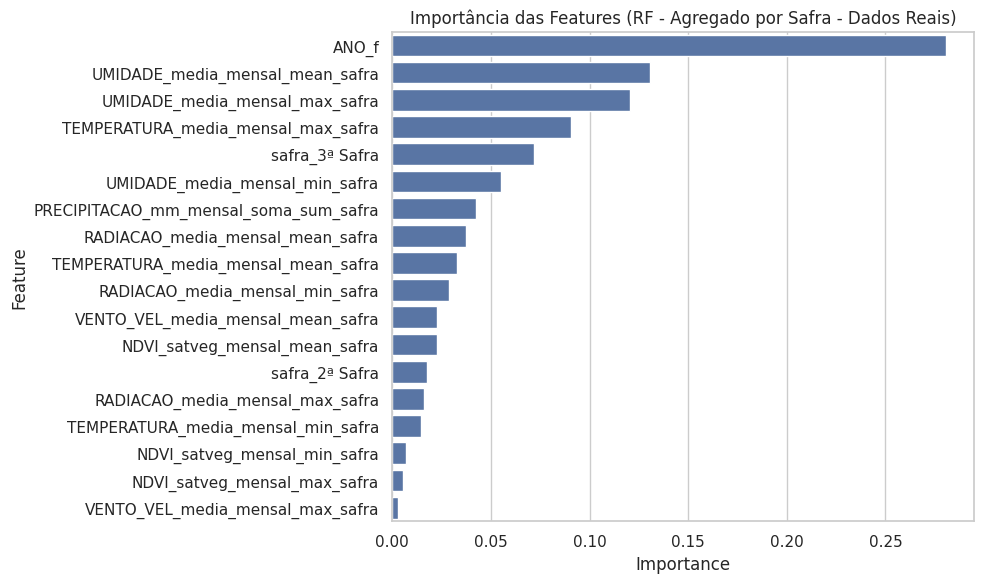

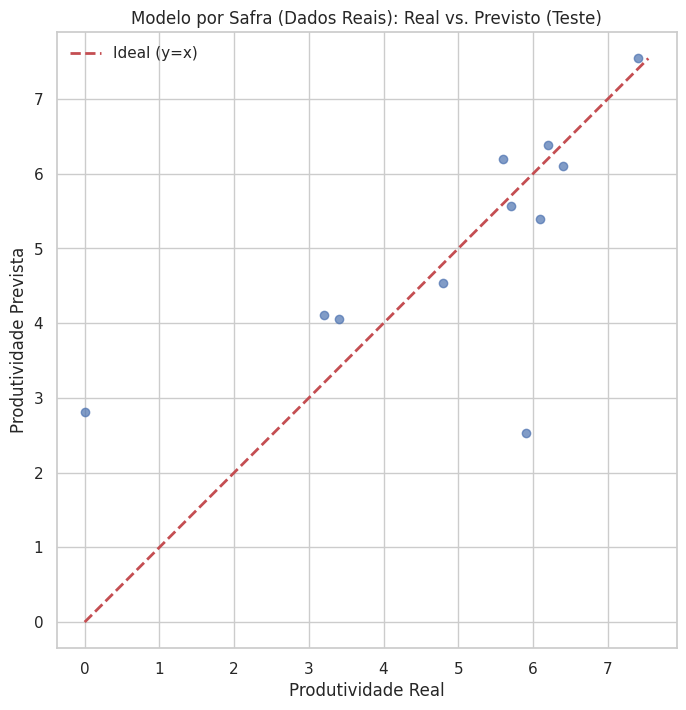

In [84]:
# Treinamento e Avaliação do RandomForestRegressor
print("\n--- Treinando e Avaliando RandomForestRegressor (por Safra - Apenas Dados Reais) ---")
model_rf_safra = None

if X_train is not None and y_train is not None and X_test is not None and y_test is not None:
    try:
        print("  Treinando RandomForestRegressor...")
        model_rf_safra = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=100, max_depth=10, min_samples_leaf=2)
        model_rf_safra.fit(X_train, y_train)
        y_pred = model_rf_safra.predict(X_test)

        # Avaliação
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        print("\n[OK] Métricas de Avaliação no Conjunto de Teste (por Safra):")
        print(f"     R-quadrado (R²): {r2:.4f}")
        print(f"     RMSE: {rmse:.4f}")
        print(f"     MAE: {mae:.4f}")

        # Importância das Features
        if hasattr(model_rf_safra, 'feature_importances_') and hasattr(X_train, 'columns'):
            print("\n     Importância das Features:")
            importances = model_rf_safra.feature_importances_
            feature_names = X_train.columns
            feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
            feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
            print(feature_importance_df)
            plt.figure(figsize=(10, max(6, len(feature_importance_df) * 0.3)))
            sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
            plt.title('Importância das Features (RF - Agregado por Safra - Dados Reais)')
            plt.tight_layout(); plt.show()

        # Gráfico Real vs Previsto
        plt.figure(figsize=(8, 8))
        plt.scatter(y_test, y_pred, alpha=0.7)
        min_val = min(y_test.min(), y_pred.min()); max_val = max(y_test.max(), y_pred.max())
        plt.plot([min_val, max_val], [min_val, max_val], '--r', linewidth=2, label='Ideal (y=x)')
        plt.xlabel('Produtividade Real'); plt.ylabel('Produtividade Prevista')
        plt.title('Modelo por Safra (Dados Reais): Real vs. Previsto (Teste)')
        plt.legend(); plt.grid(True); plt.axis('equal'); plt.show()

    except Exception as e_train_eval: print(f"[ERRO] Falha ao treinar ou avaliar: {e_train_eval}")
else: print("[ERRO] Dados de treino/teste não disponíveis.")

In [85]:
#  Salvar Modelo Final
print("\n--- Salvando Modelo Final (por Safra - Dados Reais - Opcional) ---")
if model_rf_safra is not None:
     model_folder = os.path.join('resultados', 'modelos')
     os.makedirs(model_folder, exist_ok=True)
     model_path_final_rf_safra = os.path.join(model_folder, 'modelo_final_rf_por_safra_real.joblib') # Nome ajustado
     try:
          joblib.dump(model_rf_safra, model_path_final_rf_safra)
          print(f"  Modelo final RandomForest (por safra) salvo em: {model_path_final_rf_safra}")
     except Exception as e_save: print(f"[ERRO] Falha ao salvar o modelo: {e_save}")
else: print("  Nenhum modelo treinado para salvar.")

print("\n--- Fim da Etapa 3 (Agregação por Safra - Apenas Dados Reais) ---")



--- Salvando Modelo Final (por Safra - Dados Reais - Opcional) ---
  Modelo final RandomForest (por safra) salvo em: resultados/modelos/modelo_final_rf_por_safra_real.joblib

--- Fim da Etapa 3 (Agregação por Safra - Apenas Dados Reais) ---


# 5º Modelo - Randon Forest (Otimização por safra) 💎💎

In [86]:
#  Importar Bibliotecas
import pandas as pd
import numpy as np
import os
import joblib # Para salvar o modelo treinado
# <<< ADICIONADO: GridSearchCV >>>
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import sys

print("--- Iniciando  Construção do Modelo (Otimização RF por Safra) ---")

--- Iniciando  Construção do Modelo (Otimização RF por Safra) ---


In [87]:
# Carregar Dados Processados da Etapa 1
processed_folder = 'dados_processados'
consolidated_monthly_path = os.path.join(processed_folder, 'base_consolidada_mensal.csv')
milho_path = os.path.join(processed_folder, 'milho.csv')


df_mensal = None
df_milho_proc = None
X = None
y = None
features_cols = []

try:
    df_mensal = pd.read_csv(consolidated_monthly_path)
    df_milho_proc = pd.read_csv(milho_path)
    print(f"[OK] Base consolidada mensal ({len(df_mensal)} linhas) e base de milho ({len(df_milho_proc)} linhas) carregadas.")

    # Preparação Inicial dos Dados (igual à versão anterior)
    if 'ANO' in df_mensal.columns: df_mensal['ANO'] = pd.to_numeric(df_mensal['ANO'], errors='coerce').astype('Int64')
    else: raise ValueError("Coluna 'ANO' não encontrada em df_mensal.")
    if 'MES' in df_mensal.columns: df_mensal['MES'] = pd.to_numeric(df_mensal['MES'], errors='coerce').astype('Int64')
    else: raise ValueError("Coluna 'MES' não encontrada em df_mensal.")
    df_mensal.dropna(subset=['ANO', 'MES'], inplace=True)
    for col in df_mensal.select_dtypes(include=np.number).columns:
        if col not in ['ANO', 'MES']: df_mensal[col] = pd.to_numeric(df_mensal[col], errors='coerce')

    if 'ANO' in df_milho_proc.columns: df_milho_proc['ANO'] = pd.to_numeric(df_milho_proc['ANO'], errors='coerce').astype('Int64')
    else: raise ValueError("Coluna 'ANO' não encontrada em df_milho_proc.")
    if 'Produtividade_Anual' in df_milho_proc.columns: df_milho_proc['Produtividade_Anual'] = pd.to_numeric(df_milho_proc['Produtividade_Anual'], errors='coerce')
    else: raise ValueError("Coluna 'Produtividade_Anual' não encontrada.")
    if 'safra' not in df_milho_proc.columns: raise ValueError("Coluna 'safra' não encontrada.")
    df_milho_proc.dropna(subset=['ANO', 'Produtividade_Anual', 'safra'], inplace=True)

    if df_mensal.empty or df_milho_proc.empty: raise ValueError("DataFrames vazios.")
    print(f"     Intervalo de Anos (Mensal): {df_mensal['ANO'].min()} - {df_mensal['ANO'].max()}")
    print(f"     Intervalo de Anos (Milho): {df_milho_proc['ANO'].min()} - {df_milho_proc['ANO'].max()}")
    print(f"     Safras encontradas: {df_milho_proc['safra'].unique().tolist()}")

except FileNotFoundError as e: print(f"[ERRO CRÍTICO] Arquivo não encontrado: {e}."); sys.exit()
except ValueError as ve: print(f"[ERRO CRÍTICO] Problema ao preparar dados: {ve}"); sys.exit()
except Exception as e: print(f"[ERRO CRÍTICO] Falha ao carregar/preparar dados: {e}"); sys.exit()

[OK] Base consolidada mensal (232 linhas) e base de milho (52 linhas) carregadas.
     Intervalo de Anos (Mensal): 2003 - 2025
     Intervalo de Anos (Milho): 2002 - 2024
     Safras encontradas: ['1ª Safra', '2ª Safra', '3ª Safra']


In [88]:
# Engenharia de Atributos por Safra (Refatorado)
print("\n--- Agregando Features por Safra (Refatorado) ---")
meses_safra1 = [(10, -1), (11, -1), (12, -1), (1, 0), (2, 0)]
meses_safra2 = [(2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (7, 0)]
meses_safra3 = [(5, 0), (6, 0), (7, 0), (8, 0), (9, 0)]
agg_config = {
    'mean': ['RADIACAO_media_mensal', 'TEMPERATURA_media_mensal', 'UMIDADE_media_mensal', 'VENTO_VEL_media_mensal', 'NDVI_satveg_mensal'],
    'min':  ['RADIACAO_media_mensal', 'TEMPERATURA_media_mensal', 'UMIDADE_media_mensal', 'NDVI_satveg_mensal'],
    'max':  ['RADIACAO_media_mensal', 'TEMPERATURA_media_mensal', 'UMIDADE_media_mensal', 'VENTO_VEL_media_mensal', 'NDVI_satveg_mensal'],
    'sum':  ['PRECIPITACAO_mm_mensal_soma']
}
lista_features_safra = []
for index, row in df_milho_proc.iterrows():
    ano_agricola = row['ANO']; tipo_safra = row['safra']; produtividade = row['Produtividade_Anual']
    meses_anos_target = []; meses_anos_base = None
    if '1ª' in tipo_safra: meses_anos_base = meses_safra1
    elif '2ª' in tipo_safra: meses_anos_base = meses_safra2
    elif '3ª' in tipo_safra: meses_anos_base = meses_safra3
    else: print(f"    [AVISO] Tipo de safra '{tipo_safra}' não reconhecido para Ano {ano_agricola}. Pulando."); continue
    for mes, deslocamento_ano in meses_anos_base: meses_anos_target.append((ano_agricola + deslocamento_ano, mes))
    df_mensal_safra = df_mensal[df_mensal.set_index(['ANO', 'MES']).index.isin(meses_anos_target)]
    if df_mensal_safra.empty: print(f"    [AVISO] Nenhum dado mensal para Ano {ano_agricola}, Safra '{tipo_safra}'. Pulando."); continue
    features_safra_dict = {'ANO': ano_agricola, 'safra': tipo_safra, 'Produtividade_Anual': produtividade}
    for agg_func, cols_to_agg in agg_config.items():
        cols_existentes = [col for col in cols_to_agg if col in df_mensal_safra.columns]
        if not cols_existentes: continue
        try:
            aggregated_data = df_mensal_safra[cols_existentes].agg(agg_func)
            for col_original, valor_agregado in aggregated_data.items(): features_safra_dict[f"{col_original}_{agg_func}_safra"] = valor_agregado
        except Exception as e_agg: print(f"    [ERRO] Falha ao agregar com '{agg_func}' para Ano {ano_agricola}, Safra '{tipo_safra}': {e_agg}")
    lista_features_safra.append(features_safra_dict)

if lista_features_safra:
    df_modelar_safra = pd.DataFrame(lista_features_safra)
    if 'ANO' in df_modelar_safra.columns and 'safra' in df_modelar_safra.columns:
         df_modelar_safra = df_modelar_safra.set_index(['ANO', 'safra']).sort_index()
         print("\n[OK] Base de dados por safra criada.")
         print(f"     Dimensões: {df_modelar_safra.shape}")
         print("  - [INFO] Nenhuma feature sintética adicionada.")

    else: print("[ERRO] Colunas ANO ou safra ausentes."); df_modelar_safra = None
else: print("[ERRO] Nenhuma feature agregada por safra."); df_modelar_safra = None


--- Agregando Features por Safra (Refatorado) ---
    [AVISO] Nenhum dado mensal para Ano 2002, Safra '1ª Safra'. Pulando.
    [AVISO] Nenhum dado mensal para Ano 2002, Safra '2ª Safra'. Pulando.
    [AVISO] Nenhum dado mensal para Ano 2021, Safra '1ª Safra'. Pulando.
    [AVISO] Nenhum dado mensal para Ano 2021, Safra '2ª Safra'. Pulando.
    [AVISO] Nenhum dado mensal para Ano 2021, Safra '3ª Safra'. Pulando.
    [AVISO] Nenhum dado mensal para Ano 2022, Safra '1ª Safra'. Pulando.
    [AVISO] Nenhum dado mensal para Ano 2022, Safra '2ª Safra'. Pulando.
    [AVISO] Nenhum dado mensal para Ano 2022, Safra '3ª Safra'. Pulando.

[OK] Base de dados por safra criada.
     Dimensões: (44, 16)
  - [INFO] Nenhuma feature sintética adicionada.


In [89]:
#  Seleção de Atributos (Features) e Alvo (Target)
print("\n--- Selecionando Features e Target (por Safra) ---")
X = None; y = None; features_cols = []
if 'df_modelar_safra' in locals() and isinstance(df_modelar_safra, pd.DataFrame) and 'Produtividade_Anual' in df_modelar_safra.columns:
    target = 'Produtividade_Anual'
    y = df_modelar_safra[target]
    features_cols_init = [col for col in df_modelar_safra.columns if col != target]
    X = df_modelar_safra[features_cols_init].copy()
    X['ANO_f'] = X.index.get_level_values('ANO').astype(int)
    X['safra_f'] = X.index.get_level_values('safra')
    X = pd.get_dummies(X, columns=['safra_f'], prefix='safra', drop_first=True)
    features_cols = X.columns.tolist()
    if X.isnull().any().any():
         print("  [AVISO] Preenchendo NaNs nas features com a média...");
         numeric_cols = X.select_dtypes(include=np.number).columns
         means = X[numeric_cols].mean(); means = means.fillna(0)
         X.fillna(means, inplace=True)
         if X.isnull().any().any(): print(f"  [ERRO] NaNs persistentes: {X.columns[X.isnull().any()].tolist()}."); X = None
    if X is not None: print(f"[OK] Target: '{target}' ({len(y)} amostras). Features: {len(features_cols)} ({X.shape[0]} amostras)."); # print("     Features:", features_cols) # Comentado
else: print("[ERRO] DataFrame por safra ou Target não disponíveis.")


--- Selecionando Features e Target (por Safra) ---
[OK] Target: 'Produtividade_Anual' (44 amostras). Features: 18 (44 amostras).


In [90]:
#  Divisão Treino/Teste (Simples Estratificada por Safra)
print("\n--- Dividindo Dados em Treino e Teste (Estratificado por Safra) ---")
X_train, X_test, y_train, y_test = None, None, None, None
if X is not None and y is not None and not X.empty and not y.empty:
    try:
        safra_original = df_modelar_safra.index.get_level_values('safra')
        test_size_ratio = 0.25 # 25% para teste
        # Garante que haja pelo menos 1 amostra em cada classe para estratificar
        min_samples_per_class = 2
        counts = safra_original.value_counts()
        if safra_original.nunique() > 1 and all(counts >= min_samples_per_class):
             # Tenta estratificar, mas se falhar (ex: test_size muito pequeno para classes raras), faz divisão simples
             try:
                  print(f"  Tentando estratificar divisão por safra (teste={test_size_ratio:.0%})...")
                  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size_ratio, random_state=42, stratify=safra_original)
                  print("  [OK] Divisão estratificada realizada.")
             except ValueError as e_stratify:
                  print(f"  [AVISO] Falha na estratificação ({e_stratify}). Usando divisão aleatória simples.")
                  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size_ratio, random_state=42)
        else:
            print(f"  [AVISO] Não é possível estratificar (nunique={safra_original.nunique()}, min_count={counts.min()}<{min_samples_per_class}). Usando divisão aleatória simples.")
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size_ratio, random_state=42)

        print(f"[OK] Dados divididos:")
        print(f"     Treino: {X_train.shape[0]} amostras")
        print(f"     Teste:  {X_test.shape[0]} amostras")
    except Exception as e: print(f"[ERRO] Falha ao dividir os dados: {e}")
else: print("[ERRO] Features (X) ou Target (y) não prontos para divisão.")


--- Dividindo Dados em Treino e Teste (Estratificado por Safra) ---
  Tentando estratificar divisão por safra (teste=25%)...
  [OK] Divisão estratificada realizada.
[OK] Dados divididos:
     Treino: 33 amostras
     Teste:  11 amostras


In [91]:
#  Otimização de Hiperparâmetros com GridSearchCV
print("\n--- Otimizando Hiperparâmetros do RandomForestRegressor com GridSearchCV ---")
best_model_rf = None # Inicializa o melhor modelo

if X_train is not None and y_train is not None:
    try:
        # Define a grade de parâmetros a serem testados
        # Reduzido o número de opções para acelerar com poucos dados
        param_grid_rf = {
            'n_estimators': [50, 100, 150],       # Número de árvores
            'max_depth': [5, 10, None],          # Profundidade máxima (None = sem limite)
            'min_samples_split': [2, 5],         # Mínimo de amostras para dividir um nó
            'min_samples_leaf': [1, 3],           # Mínimo de amostras em um nó folha
            'max_features': ['sqrt', 'log2']     # Número de features a considerar (alternativas a 'auto')
        }

        # Cria a instância base do RandomForest
        base_rf = RandomForestRegressor(random_state=42, n_jobs=-1)

        # Configura o GridSearchCV
        # cv=3: Usa validação cruzada com 3 folds (mais adequado para poucos dados)
        cv_folds = min(3, len(X_train)) if len(X_train) > 1 else 2
        if cv_folds < 2:
             print("[AVISO] Poucas amostras de treino para validação cruzada. Treinando modelo com parâmetros padrão.")
             best_model_rf = base_rf.fit(X_train, y_train) # Treina com params padrão
        else:
             print(f"  Iniciando busca com {cv_folds}-Fold CV (pode levar um tempo)...")
             # Usar 'r2' como scoring é mais intuitivo que neg_mean_squared_error
             grid_search_rf = GridSearchCV(estimator=base_rf, param_grid=param_grid_rf,
                                          cv=cv_folds, scoring='r2', n_jobs=-1, verbose=1)
             grid_search_rf.fit(X_train, y_train)

             # Obtém o melhor modelo encontrado
             best_model_rf = grid_search_rf.best_estimator_
             print("\n[OK] Otimização concluída!")
             print(f"     Melhores Hiperparâmetros encontrados: {grid_search_rf.best_params_}")
             print(f"     Melhor Score (R²) na validação cruzada: {grid_search_rf.best_score_:.4f}")

    except Exception as e_grid:
        print(f"[ERRO] Falha durante o GridSearchCV: {e_grid}")
        print("       Tentando treinar modelo com parâmetros padrão...")
        try:
             best_model_rf = RandomForestRegressor(random_state=42, n_jobs=-1).fit(X_train, y_train)
             print("       [OK] Modelo treinado com parâmetros padrão.")
        except Exception as e_fallback:
             print(f"       [ERRO] Falha ao treinar modelo padrão: {e_fallback}")
else:
    print("[ERRO] Dados de treino não disponíveis para otimização.")


--- Otimizando Hiperparâmetros do RandomForestRegressor com GridSearchCV ---
  Iniciando busca com 3-Fold CV (pode levar um tempo)...
Fitting 3 folds for each of 72 candidates, totalling 216 fits

[OK] Otimização concluída!
     Melhores Hiperparâmetros encontrados: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
     Melhor Score (R²) na validação cruzada: 0.6012



--- Avaliando o Melhor Modelo RandomForest no Conjunto de Teste ---

[OK] Métricas de Avaliação no Conjunto de Teste (Modelo Otimizado):
     R-quadrado (R²): 0.5202
     RMSE: 1.3673
     MAE: 1.0749

     Importância das Features (Modelo Otimizado):
                                  Feature  Importance
2         UMIDADE_media_mensal_mean_safra    0.148550
11         UMIDADE_media_mensal_max_safra    0.106602
15                                  ANO_f    0.104105
17                         safra_3ª Safra    0.095558
10     TEMPERATURA_media_mensal_max_safra    0.090289
4           NDVI_satveg_mensal_mean_safra    0.060644
7          UMIDADE_media_mensal_min_safra    0.053033
1     TEMPERATURA_media_mensal_mean_safra    0.052897
9         RADIACAO_media_mensal_max_safra    0.041760
0        RADIACAO_media_mensal_mean_safra    0.040894
5         RADIACAO_media_mensal_min_safra    0.039583
12       VENTO_VEL_media_mensal_max_safra    0.038892
14  PRECIPITACAO_mm_mensal_soma_sum_safra    

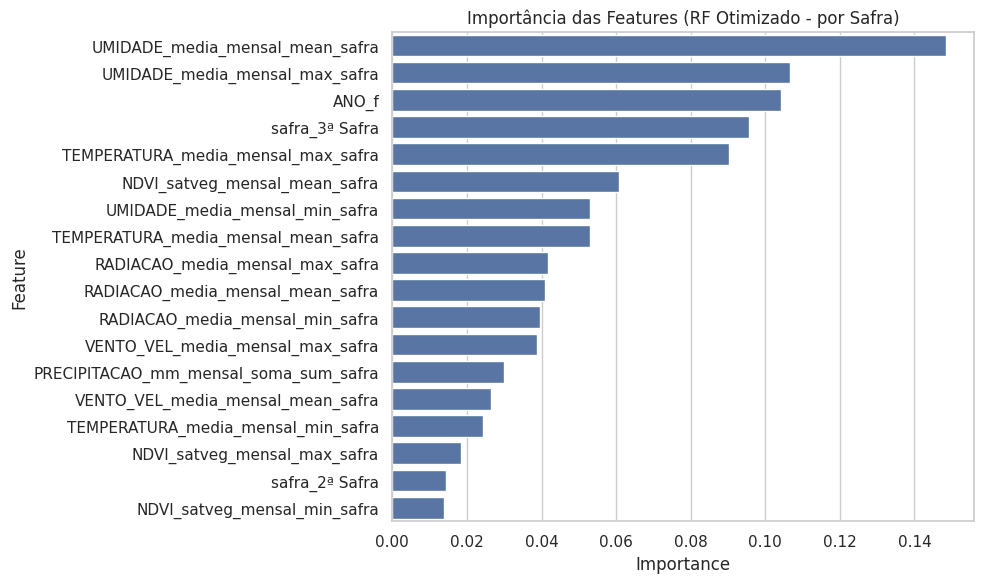

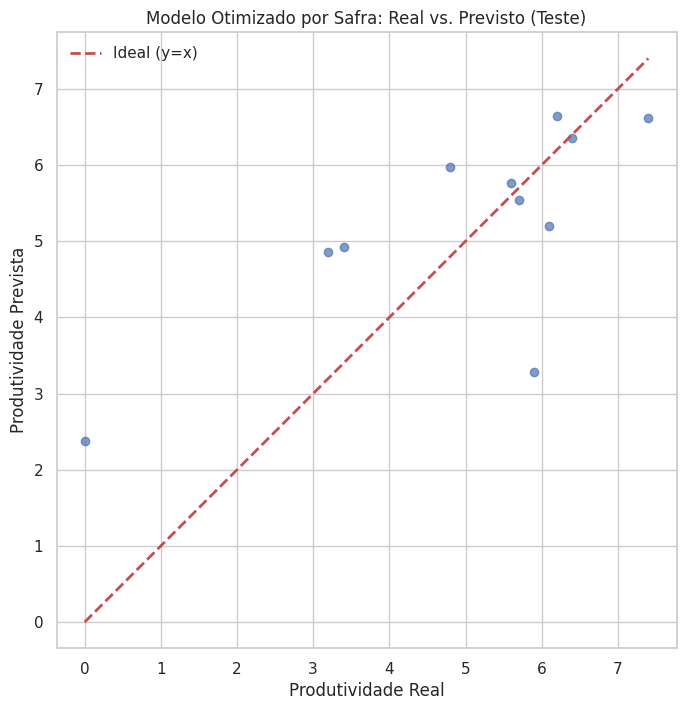

In [92]:
#  Avaliação do Melhor Modelo no Conjunto de Teste
print("\n--- Avaliando o Melhor Modelo RandomForest no Conjunto de Teste ---")

if best_model_rf is not None and X_test is not None and y_test is not None:
    try:
        y_pred = best_model_rf.predict(X_test)

        # Avaliação
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        print("\n[OK] Métricas de Avaliação no Conjunto de Teste (Modelo Otimizado):")
        print(f"     R-quadrado (R²): {r2:.4f}")
        print(f"     RMSE: {rmse:.4f}")
        print(f"     MAE: {mae:.4f}")

        # Importância das Features
        if hasattr(best_model_rf, 'feature_importances_') and hasattr(X_train, 'columns'):
            print("\n     Importância das Features (Modelo Otimizado):")
            importances = best_model_rf.feature_importances_
            feature_names = X_train.columns
            feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
            feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
            print(feature_importance_df)
            plt.figure(figsize=(10, max(6, len(feature_importance_df) * 0.3)))
            sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
            plt.title('Importância das Features (RF Otimizado - por Safra)')
            plt.tight_layout(); plt.show()

        # Gráfico Real vs Previsto
        plt.figure(figsize=(8, 8))
        plt.scatter(y_test, y_pred, alpha=0.7)
        min_val = min(y_test.min(), y_pred.min()); max_val = max(y_test.max(), y_pred.max())
        plt.plot([min_val, max_val], [min_val, max_val], '--r', linewidth=2, label='Ideal (y=x)')
        plt.xlabel('Produtividade Real'); plt.ylabel('Produtividade Prevista')
        plt.title('Modelo Otimizado por Safra: Real vs. Previsto (Teste)')
        plt.legend(); plt.grid(True); plt.axis('equal'); plt.show()

    except Exception as e_eval: print(f"[ERRO] Falha ao avaliar o modelo otimizado: {e_eval}")
else: print("[ERRO] Melhor modelo ou dados de teste não disponíveis para avaliação.")

In [93]:
# Salvar Modelo Final Otimizado (Opcional)
print("\n--- Salvando Modelo Final Otimizado (por Safra - Opcional) ---")
if best_model_rf is not None:
     model_folder = os.path.join('resultados', 'modelos')
     os.makedirs(model_folder, exist_ok=True)
     model_path_final_rf_safra_opt = os.path.join(model_folder, 'modelo_final_rf_por_safra_otimizado.joblib')
     try:
          joblib.dump(best_model_rf, model_path_final_rf_safra_opt)
          print(f"  Melhor modelo RandomForest (por safra) salvo em: {model_path_final_rf_safra_opt}")
     except Exception as e_save: print(f"[ERRO] Falha ao salvar o modelo: {e_save}")
else: print("  Nenhum modelo otimizado treinado para salvar.")

print("\n--- Fim da (Otimização RF por Safra) ---")




--- Salvando Modelo Final Otimizado (por Safra - Opcional) ---
  Melhor modelo RandomForest (por safra) salvo em: resultados/modelos/modelo_final_rf_por_safra_otimizado.joblib

--- Fim da (Otimização RF por Safra) ---


# Streamlit - Visualizações e métricas de desempenho 📊 📈





In [95]:
!pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.8 MB/s eta 0:00:00


In [96]:
!streamlit run app_produtividade.py

Usage: streamlit run [OPTIONS] TARGET [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app_produtividade.py


In [106]:
#  Importações e Configurações Iniciais ---
print("Executando Importações e Configurações")
import streamlit as st
import pandas as pd
import numpy as np
import os
import joblib # Para carregar o modelo salvo
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor # Apenas para type hint
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# Configuração da Página Streamlit (deve ser a primeira chamada st)
st.set_page_config(layout="wide", page_title="Dashboard Produtividade Milho")

# Configurações Gerais de Plotagem
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    try: plt.style.use('seaborn-whitegrid')
    except OSError: print("Nenhum estilo seaborn encontrado.")
sns.set(style="whitegrid")

print("--- Fim Importações e Configurações ---")

2025-04-27 03:55:01.387 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


Executando Importações e Configurações
--- Fim Importações e Configurações ---


In [107]:
# Definição de Caminhos e Constantes ---
print("Executando Definição de Caminhos")
processed_folder = 'dados_processados'
results_folder = 'resultados'
model_folder = os.path.join(results_folder, 'modelos')
consolidated_monthly_path = os.path.join(processed_folder, 'base_consolidada_mensal.csv')
milho_path = os.path.join(processed_folder, 'milho.csv')
# Ajuste o nome do modelo se salvou com outro nome na Etapa 3
model_path = os.path.join(model_folder, 'modelo_final_rf_por_safra_otimizado.joblib')
print("--- Fim Definição de Caminhos ---")

Executando Definição de Caminhos
--- Fim Definição de Caminhos ---


In [108]:
#  Definição das Funções Auxiliares (com Cache)

print("Executando Definição das Funções Auxiliares")

@st.cache_data # Cache para dados carregados
def carregar_dados_base(monthly_path, milho_path_func):
    """Carrega e faz uma preparação mínima nos DataFrames base."""
    df_mensal = None; df_milho_proc = None; erro_carga = False
    if not os.path.exists(monthly_path): st.error(f"Erro: Arquivo não encontrado: {monthly_path}"); erro_carga = True
    if not os.path.exists(milho_path_func): st.error(f"Erro: Arquivo não encontrado: {milho_path_func}"); erro_carga = True
    if erro_carga: return None, None
    try:
        df_mensal = pd.read_csv(monthly_path)
        df_milho_proc = pd.read_csv(milho_path_func)
        # Preparação mínima
        if 'ANO' in df_mensal.columns: df_mensal['ANO'] = pd.to_numeric(df_mensal['ANO'], errors='coerce').astype('Int64')
        else: raise ValueError("Coluna 'ANO' ausente em df_mensal.")
        if 'MES' in df_mensal.columns: df_mensal['MES'] = pd.to_numeric(df_mensal['MES'], errors='coerce').astype('Int64')
        else: raise ValueError("Coluna 'MES' ausente em df_mensal.")
        df_mensal.dropna(subset=['ANO', 'MES'], inplace=True)
        if 'DATA_MES' not in df_mensal.columns:
             df_mensal['ANO_str'] = df_mensal['ANO'].astype(str)
             df_mensal['MES_str'] = df_mensal['MES'].astype(str).str.zfill(2)
             df_mensal['DATA_MES'] = pd.to_datetime(df_mensal['ANO_str'] + '-' + df_mensal['MES_str'] + '-01', errors='coerce')
             df_mensal.drop(columns=['ANO_str', 'MES_str'], inplace=True)
        if 'ANO' in df_milho_proc.columns: df_milho_proc['ANO'] = pd.to_numeric(df_milho_proc['ANO'], errors='coerce').astype('Int64')
        else: raise ValueError("Coluna 'ANO' ausente em df_milho_proc.")
        if 'Produtividade_Anual' in df_milho_proc.columns: df_milho_proc['Produtividade_Anual'] = pd.to_numeric(df_milho_proc['Produtividade_Anual'], errors='coerce')
        else: raise ValueError("Coluna 'Produtividade_Anual' ausente em df_milho_proc.")
        if 'safra' not in df_milho_proc.columns: raise ValueError("Coluna 'safra' ausente em df_milho_proc.")
        df_milho_proc.dropna(subset=['ANO', 'Produtividade_Anual', 'safra'], inplace=True)
        return df_mensal, df_milho_proc
    except Exception as e: st.error(f"Erro ao carregar/preparar dados base: {e}"); return None, None

@st.cache_data
def agregar_features_por_safra(_df_mensal, _df_milho_proc):
    """Agrega features climáticas/NDVI por safra."""

    if _df_mensal is None or _df_milho_proc is None: return None
    meses_safra1 = [(10, -1), (11, -1), (12, -1), (1, 0), (2, 0)]; meses_safra2 = [(2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (7, 0)]; meses_safra3 = [(5, 0), (6, 0), (7, 0), (8, 0), (9, 0)]
    agg_config = {
        'mean': ['RADIACAO_media_mensal', 'TEMPERATURA_media_mensal', 'UMIDADE_media_mensal', 'VENTO_VEL_media_mensal', 'NDVI_satveg_mensal'],
        'min':  ['RADIACAO_media_mensal', 'TEMPERATURA_media_mensal', 'UMIDADE_media_mensal', 'NDVI_satveg_mensal'],
        'max':  ['RADIACAO_media_mensal', 'TEMPERATURA_media_mensal', 'UMIDADE_media_mensal', 'VENTO_VEL_media_mensal', 'NDVI_satveg_mensal'],
        'sum':  ['PRECIPITACAO_mm_mensal_soma']
    }
    lista_features_safra = []
    for index, row in _df_milho_proc.iterrows():
        ano_agricola = row['ANO']; tipo_safra = row['safra']; produtividade = row['Produtividade_Anual']
        meses_anos_target = []; meses_anos_base = None
        if '1ª' in tipo_safra: meses_anos_base = meses_safra1
        elif '2ª' in tipo_safra: meses_anos_base = meses_safra2
        elif '3ª' in tipo_safra: meses_anos_base = meses_safra3
        else: continue
        for mes, deslocamento_ano in meses_anos_base: meses_anos_target.append((ano_agricola + deslocamento_ano, mes))
        df_mensal_safra = _df_mensal[_df_mensal.set_index(['ANO', 'MES']).index.isin(meses_anos_target)]
        if df_mensal_safra.empty: continue
        features_safra_dict = {'ANO': ano_agricola, 'safra': tipo_safra, 'Produtividade_Anual': produtividade}
        for agg_func, cols_to_agg in agg_config.items():
            cols_existentes = [col for col in cols_to_agg if col in df_mensal_safra.columns]
            if not cols_existentes: continue
            try:
                aggregated_data = df_mensal_safra[cols_existentes].agg(agg_func)
                for col_original, valor_agregado in aggregated_data.items(): features_safra_dict[f"{col_original}_{agg_func}_safra"] = valor_agregado
            except Exception as e_agg: print(f"Erro agregando {agg_func} para {ano_agricola}/{tipo_safra}: {e_agg}")
        lista_features_safra.append(features_safra_dict)
    if lista_features_safra:
        df_modelar_safra = pd.DataFrame(lista_features_safra)
        if 'ANO' in df_modelar_safra.columns and 'safra' in df_modelar_safra.columns:
            df_modelar_safra = df_modelar_safra.set_index(['ANO', 'safra']).sort_index()
            return df_modelar_safra
    return None

@st.cache_data
def preparar_X_y(_df_modelar_safra):
    """Prepara X e y a partir do DataFrame agregado por safra."""
    if _df_modelar_safra is None or 'Produtividade_Anual' not in _df_modelar_safra.columns: return None, None, None
    target = 'Produtividade_Anual'; y = _df_modelar_safra[target]
    features_cols_init = [col for col in _df_modelar_safra.columns if col != target]
    X = _df_modelar_safra[features_cols_init].copy()
    X['ANO_f'] = X.index.get_level_values('ANO').astype(int)
    X['safra_f'] = X.index.get_level_values('safra')
    X = pd.get_dummies(X, columns=['safra_f'], prefix='safra', drop_first=True)
    features_cols = X.columns.tolist()
    if X.isnull().any().any():
         st.warning("Preenchendo NaNs nas features com a média...")
         numeric_cols = X.select_dtypes(include=np.number).columns
         means = X[numeric_cols].mean(); means = means.fillna(0)
         X.fillna(means, inplace=True)
         if X.isnull().any().any(): st.error(f"NaNs persistentes: {X.columns[X.isnull().any()].tolist()}."); return None, None, None
    return X, y, features_cols

@st.cache_resource # Cache para o modelo carregado
def carregar_modelo(model_path_func):
    """Carrega o modelo .joblib salvo."""
    if not os.path.exists(model_path_func):
        st.error(f"Erro: Arquivo do modelo não encontrado em '{model_path_func}'.")
        return None
    try:
        model = joblib.load(model_path_func)
        st.success(f"Modelo carregado com sucesso de: {os.path.basename(model_path_func)}")
        return model
    except Exception as e: st.error(f"Erro ao carregar o modelo: {e}"); return None

print("--- Fim Definição das Funções Auxiliares---")

2025-04-27 03:57:01.058 No runtime found, using MemoryCacheStorageManager
2025-04-27 03:57:01.072 No runtime found, using MemoryCacheStorageManager
2025-04-27 03:57:01.077 No runtime found, using MemoryCacheStorageManager


Executando Definição das Funções Auxiliares
--- Fim Definição das Funções Auxiliares---


In [109]:
#  Execução Principal e Geração de Dados

print("Executando  Execução Principal e Geração de Dados")
df_mensal, df_milho_proc = carregar_dados_base(consolidated_monthly_path, milho_path)
df_modelar_safra = agregar_features_por_safra(df_mensal, df_milho_proc)
X, y, features_cols = preparar_X_y(df_modelar_safra)
best_model_rf = carregar_modelo(model_path)
print("--- Fim Execução Principal e Geração de Dados ---")

2025-04-27 03:57:47.407 No runtime found, using MemoryCacheStorageManager
2025-04-27 03:57:47.409 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 03:57:47.410 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 03:57:47.412 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 03:57:47.431 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 03:57:47.432 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 03:57:47.434 No runtime found, using MemoryCacheStorageManager
2025-04-27 03:57:47.435 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 03:57:47.437 Thread 'MainThread': missing ScriptRunContext! This warning can be ignor

Executando  Execução Principal e Geração de Dados


2025-04-27 03:57:47.860 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 03:57:47.862 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 03:57:47.864 No runtime found, using MemoryCacheStorageManager
2025-04-27 03:57:47.865 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 03:57:47.867 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 03:57:47.868 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 03:57:47.877 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 03:57:47.878 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 03:57:47.880 Thread 'MainThread':

--- Fim Execução Principal e Geração de Dados ---


In [111]:
#  Layout da Interface (Título e Abas)
print("Executando Layout da Interface")
st.title("🌽 Dashboard de Produtividade de Milho (Sorriso-MT)")
st.markdown("Análise Exploratória dos Dados e Avaliação do Modelo Preditivo (RandomForest por Safra).")

# Cria as abas principais
tab1, tab2 = st.tabs(["📊 Análise Exploratória", "🤖 Avaliação do Modelo"])
print("--- Fim Layout da Interface ---")

2025-04-27 03:59:29.522 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 03:59:29.523 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 03:59:29.525 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 03:59:29.527 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 03:59:29.529 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 03:59:29.531 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 03:59:29.533 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


Executando Layout da Interface
--- Fim Layout da Interface ---


In [110]:
# Conteúdo da Aba "Análise Exploratória"
print("Executando Conteúdo Aba EDA")
with tab1:
    st.header("Análise Exploratória dos Dados")

    # Verifica se os dados base foram carregados
    if df_mensal is not None and df_milho_proc is not None:
        st.markdown("Visualização das tendências e padrões nos dados originais processados.")

        # Cria sub-abas dentro da Análise Exploratória
        sub_tab_clima, sub_tab_ndvi, sub_tab_prod = st.tabs([
            "Clima", "NDVI (SatVeg)", "Produtividade"
        ])

        # Conteúdo da sub-aba Clima
        with sub_tab_clima:
            st.subheader("Séries Temporais Climáticas (Médias/Somas Mensais)")
            if 'DATA_MES' in df_mensal.columns:
                fig_clima, axes_clima = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
                plot_vars_clima = {
                    'TEMPERATURA_media_mensal': ('Temperatura (°C)', 'red', axes_clima[0]),
                    'RADIACAO_media_mensal': ('Radiação (W/m² ?)', 'orange', axes_clima[1]),
                    'PRECIPITACAO_mm_mensal_soma': ('Precipitação (mm/mês)', 'blue', axes_clima[2]),
                    'UMIDADE_media_mensal': ('Umidade Relativa (%)', 'green', axes_clima[3])
                }
                plot_count_clima = 0
                for col, (label, color, ax) in plot_vars_clima.items():
                    if col in df_mensal.columns and not df_mensal[col].isnull().all():
                        ax.plot(df_mensal['DATA_MES'], df_mensal[col], label=label.split('(')[0].strip(), color=color, alpha=0.8)
                        ax.set_ylabel(label); ax.grid(True, alpha=0.5); ax.legend(loc='upper left')
                        plot_count_clima += 1
                if plot_count_clima > 0:
                    axes_clima[-1].set_xlabel('Data'); plt.suptitle("Evolução Mensal das Variáveis Climáticas", y=1.02); plt.tight_layout(rect=[0, 0.03, 1, 0.98])
                    st.pyplot(fig_clima)
                else: st.warning("Não foi possível gerar gráficos climáticos.")
            else: st.warning("Coluna 'DATA_MES' não encontrada.")

        # Conteúdo da sub-aba NDVI
        with sub_tab_ndvi:
            st.subheader("NDVI SatVeg (Médio Mensal)")
            if 'DATA_MES' in df_mensal.columns and 'NDVI_satveg_mensal' in df_mensal.columns:
                fig_ndvi_ts, ax_ndvi_ts = plt.subplots(figsize=(12, 4))
                ax_ndvi_ts.plot(df_mensal['DATA_MES'], df_mensal['NDVI_satveg_mensal'], marker='.', linestyle='-', label='NDVI SatVeg Médio Mensal')
                ax_ndvi_ts.set_title('Série Temporal NDVI Médio Mensal (SatVeg)'); ax_ndvi_ts.set_xlabel('Data'); ax_ndvi_ts.set_ylabel('NDVI Médio Mensal')
                ax_ndvi_ts.grid(True, alpha=0.5); ax_ndvi_ts.legend(); st.pyplot(fig_ndvi_ts)

                if 'MES' in df_mensal.columns:
                     df_perfil_st = df_mensal.dropna(subset=['MES', 'NDVI_satveg_mensal'])
                     if not df_perfil_st.empty:
                          perfil_ndvi = df_perfil_st.groupby('MES').agg(NDVI_medio=('NDVI_satveg_mensal', 'mean'), NDVI_std=('NDVI_satveg_mensal', 'std'))
                          if not perfil_ndvi.empty:
                               fig_ndvi_saz, ax_ndvi_saz = plt.subplots(figsize=(10, 5))
                               ax_ndvi_saz.errorbar(perfil_ndvi.index, perfil_ndvi['NDVI_medio'], yerr=perfil_ndvi['NDVI_std'], label='NDVI SatVeg Médio ± Desv Padrão', fmt='-o', capsize=5)
                               ax_ndvi_saz.set_title('Perfil Sazonal Médio do NDVI SatVeg'); ax_ndvi_saz.set_xlabel('Mês do Ano'); ax_ndvi_saz.set_ylabel('Valor Médio NDVI')
                               ax_ndvi_saz.set_xticks(range(1, 13)); ax_ndvi_saz.legend(); ax_ndvi_saz.grid(True); st.pyplot(fig_ndvi_saz)
                          else: st.warning("Não foi possível calcular perfil sazonal NDVI.")
                     else: st.warning("Não há dados válidos para perfil sazonal NDVI.")
                else: st.warning("Coluna 'MES' não encontrada.")
            else: st.warning("Colunas 'DATA_MES' ou 'NDVI_satveg_mensal' não encontradas.")

        # Conteúdo da sub-aba Produtividade
        with sub_tab_prod:
            st.subheader("Produtividade de Milho (CONAB - MT)")
            colunas_num_prod = ['area_plantada_mil_ha', 'producao_mil_t', 'Produtividade_Anual']
            colunas_num_prod_ok = [c for c in colunas_num_prod if c in df_milho_proc.columns]
            if 'ANO' in df_milho_proc.columns and 'safra' in df_milho_proc.columns and colunas_num_prod_ok:
                 st.write("Evolução por Safra:")
                 for coluna in colunas_num_prod_ok:
                      fig_prod_ts, ax_prod_ts = plt.subplots(figsize=(12, 4))
                      sns.lineplot(data=df_milho_proc, x='ANO', y=coluna, hue='safra', marker='o', errorbar=None, ax=ax_prod_ts)
                      ax_prod_ts.set_title(f'Evolução - {coluna} por Safra'); ax_prod_ts.set_xlabel('Ano'); ax_prod_ts.set_ylabel(coluna.replace('_', ' ').title())
                      ax_prod_ts.legend(title='Safra'); ax_prod_ts.grid(True); st.pyplot(fig_prod_ts)

                 st.write("Distribuição da Produtividade por Ano e Safra:")
                 df_milho_proc['ANO'] = pd.to_numeric(df_milho_proc['ANO'], errors='coerce')
                 df_milho_proc_plot = df_milho_proc.dropna(subset=['ANO', 'Produtividade_Anual', 'safra'])
                 if not df_milho_proc_plot.empty:
                      fig_prod_box, ax_prod_box = plt.subplots(figsize=(14, 7))
                      sns.boxplot(x='ANO', y='Produtividade_Anual', hue='safra', data=df_milho_proc_plot, ax=ax_prod_box, dodge=True, linewidth=1.5, showfliers=False)
                      sns.stripplot(x='ANO', y='Produtividade_Anual', hue='safra', data=df_milho_proc_plot, size=8, edgecolor='gray', linewidth=0.5, jitter=True, dodge=True, alpha=0.7, legend=True, ax=ax_prod_box)
                      ax_prod_box.set_title('Distribuição da Produtividade Anual por Ano e Safra')
                      ax_prod_box.set_xlabel('Ano'); ax_prod_box.set_ylabel('Produtividade (t/ha)')
                      ax_prod_box.tick_params(axis='x', rotation=45); ax_prod_box.grid(True, axis='y')
                      handles, labels = ax_prod_box.get_legend_handles_labels() # Pega legenda do stripplot
                      # Mostra apenas uma legenda
                      unique_labels = {}
                      for h, l in zip(handles, labels): unique_labels[l] = h
                      ax_prod_box.legend(unique_labels.values(), unique_labels.keys(), title='Safra', bbox_to_anchor=(1.02, 1), loc='upper left')
                      plt.tight_layout(rect=[0, 0, 0.9, 1]); st.pyplot(fig_prod_box)
                 else: st.warning("Não há dados válidos para gerar boxplot de produtividade.")
            else: st.warning("Colunas necessárias para gráficos de produtividade não encontradas.")
    else:
        st.error("Falha ao carregar os dados necessários para a Análise Exploratória.")
print("--- Fim Conteúdo Aba EDA ---")

2025-04-27 03:59:18.945 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 03:59:18.947 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 03:59:18.948 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 03:59:18.949 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 03:59:18.950 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 03:59:18.952 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 03:59:18.953 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 03:59:18.954 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

Executando Conteúdo Aba EDA


<ipython-input-110-0ce28b0b5395>:19: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig_clima, axes_clima = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
2025-04-27 03:59:19.493 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 03:59:21.208 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 03:59:21.209 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 03:59:21.210 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 03:59:21.211 Thread 'MainThread': missing ScriptRunContext!

--- Fim Conteúdo Aba EDA ---


In [112]:
# Conteúdo da Aba "Avaliação do Modelo"
print("Executando Conteúdo Aba Avaliação Modelo")
with tab2:
    st.header("Avaliação do Modelo Otimizado (RandomForest por Safra)")

    # Verifica se tudo carregou e foi preparado para o modelo
    if X is not None and y is not None and best_model_rf is not None:
        # Recriar a divisão Treino/Teste
        X_train, X_test, y_train, y_test = None, None, None, None
        try:
            safra_original = df_modelar_safra.loc[X.index].index.get_level_values('safra')
            test_size_ratio = 0.25; min_samples_per_class = 2
            counts = safra_original.value_counts(); y = y.loc[X.index]
            if safra_original.nunique() > 1 and all(counts >= min_samples_per_class):
                 try: X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size_ratio, random_state=42, stratify=safra_original)
                 except ValueError: st.warning("Falha na estratificação. Usando divisão simples."); X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size_ratio, random_state=42)
            else: st.warning("Não estratificando. Usando divisão simples."); X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size_ratio, random_state=42)
            st.write(f"Dados divididos para avaliação: {len(X_train)} treino, {len(X_test)} teste.")
        except Exception as e_split: st.error(f"Erro ao recriar divisão treino/teste: {e_split}")

        # Avaliar no conjunto de teste
        if X_test is not None and y_test is not None:
            try:
                X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
                y_pred = best_model_rf.predict(X_test)
                r2 = r2_score(y_test, y_pred); rmse = np.sqrt(mean_squared_error(y_test, y_pred)); mae = mean_absolute_error(y_test, y_pred)

                st.subheader("Métricas de Desempenho (Conjunto de Teste)")
                col1, col2, col3 = st.columns(3)
                col1.metric("R²", f"{r2:.4f}"); col2.metric("RMSE (t/ha)", f"{rmse:.4f}"); col3.metric("MAE (t/ha)", f"{mae:.4f}")
                st.caption(f"R²: Proporção da variância explicada. RMSE/MAE: Erro médio.")

                st.subheader("Gráficos de Avaliação do Modelo")
                col_g1, col_g2 = st.columns(2)
                with col_g1:
                    fig1, ax1 = plt.subplots(figsize=(6, 6))
                    ax1.scatter(y_test, y_pred, alpha=0.7, edgecolors='k', s=50)
                    min_val = min(y_test.min(), y_pred.min()) - 0.5; max_val = max(y_test.max(), y_pred.max()) + 0.5
                    ax1.plot([min_val, max_val], [min_val, max_val], '--r', linewidth=2, label='Ideal')
                    ax1.set_xlabel('Produtividade Real (t/ha)'); ax1.set_ylabel('Produtividade Prevista (t/ha)')
                    ax1.set_title('Real vs. Previsto (Teste)'); ax1.legend(); ax1.grid(True); ax1.axis('equal'); ax1.set_xlim(min_val, max_val); ax1.set_ylim(min_val, max_val)
                    st.pyplot(fig1)
                with col_g2:
                    if hasattr(best_model_rf, 'feature_importances_') and hasattr(X_train, 'columns'):
                        importances = best_model_rf.feature_importances_; feature_names = X_train.columns
                        feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)
                        fig2, ax2 = plt.subplots(figsize=(6, 7))
                        sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), ax=ax2, palette='viridis')
                        ax2.set_title('Importância das Features'); plt.tight_layout(); st.pyplot(fig2)
                    else: st.warning("Não foi possível extrair importância das features.")

                if st.checkbox("Mostrar Tabela de Comparação Detalhada"):
                    st.subheader("Comparação Detalhada (Conjunto de Teste)")
                    df_resultados = pd.DataFrame({'Real': y_test, 'Previsto': y_pred}, index=y_test.index)
                    df_resultados['Erro'] = df_resultados['Real'] - df_resultados['Previsto']
                    df_resultados['Erro (%)'] = (df_resultados['Erro'] / df_resultados['Real']) * 100
                    st.dataframe(df_resultados.style.format({'Real': '{:.2f}', 'Previsto': '{:.2f}', 'Erro': '{:.2f}', 'Erro (%)': '{:.1f}%'}).background_gradient(cmap='RdYlGn_r', subset=['Erro'], axis=0, low=0.4, high=0.4))
            except Exception as e_eval: st.error(f"Erro ao avaliar modelo: {e_eval}")
        else: st.error("Não foi possível recriar dados de teste.")
    else: st.error("Não foi possível carregar dados ou modelo para avaliação.")
print("--- Fim Conteúdo Aba Avaliação Modelo ---")

2025-04-27 04:00:15.458 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 04:00:15.459 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 04:00:15.466 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 04:00:15.467 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 04:00:15.469 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 04:00:15.470 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 04:00:15.523 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 04:00:15.524 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

Executando Conteúdo Aba Avaliação Modelo


2025-04-27 04:00:15.909 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 04:00:15.911 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
<ipython-input-112-248b07c808aa>:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), ax=ax2, palette='viridis')
2025-04-27 04:00:16.281 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 04:00:16.624 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 04:00:16.626 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 04:00:16.627 Thread 'MainThread'

--- Fim Conteúdo Aba Avaliação Modelo ---


In [113]:
#  Conteúdo da Sidebar
print("Executando Conteúdo da Sidebar")
st.sidebar.header("Sobre")
st.sidebar.info("Dashboard de previsão de produtividade de milho (Sorriso-MT) usando RandomForest, dados climáticos e NDVI SatVeg por safra.")
st.sidebar.header("Arquivos Necessários")
st.sidebar.markdown(f"- `{os.path.basename(consolidated_monthly_path)}`")
st.sidebar.markdown(f"- `{os.path.basename(milho_path)}`")
st.sidebar.markdown(f"- `{os.path.basename(model_path)}`")
print("--- Fim Conteúdo da Sidebar ---")

print("\n--- Fim da Execução do Script Streamlit ---")



2025-04-27 04:00:47.527 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 04:00:47.530 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 04:00:47.532 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 04:00:47.535 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 04:00:47.538 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 04:00:47.541 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 04:00:47.544 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-27 04:00:47.547 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

Executando Conteúdo da Sidebar
--- Fim Conteúdo da Sidebar ---

--- Fim da Execução do Script Streamlit ---
